<a href="https://colab.research.google.com/github/Knerdy-got-moves/Many-body-dynamics-in-Floquet-driven-systems/blob/main/Autocorrelation/Autocorrelation%2C_HSF_and_edge_modes_in_open_Ising_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kicked interaction-longitudinal and static transverse field Ising chain under open boundary conditions

**MODEL:**

Consider a one-dimensional longitudinal and transverse field  Ising chain as a Floquet-driven system of length $L$ with open boundary conditions that uses Pauli operators $\sigma_i^{x,y,z}$ and is subject to a weak static transverse perturbation, with both couplings following the same symmetric square-wave drive of period $T$:
$$
H(t)=H_0(t)+H_1, \quad
H_0(t)=-J(t)\sum_{i=1}^{L-1}\sigma_i^z\sigma_{i+1}^z\;-\;h(t)\sum_{i=1}^{L}\sigma_i^z, \quad
H_1=-g\sum_{i=1}^{L}\sigma_i^x,\;\;|g|\ll \{|J_0|,|h_0|\}.
$$

\begin{equation}
J(t)=\begin{cases} +J_0,& 0\le t\le T/2,\\ -J_0,& T/2<t\le T,\end{cases}
\qquad
h(t)=\begin{cases} +h_0,& 0\le t\le T/2,\\ -h_0,& T/2<t\le T.\end{cases}
\end{equation}  

The Floquet Hamiltonian, $H_F$ is defined in terms of the Floquet unitary (time evolution operator for the Hamiltonian, $H(t)$ over one complete period) as: $$U(T,0)=e^{-\,\frac{i}{\hbar}H_F T}$$
The Floquet Hamiltonian is like the effective Hamiltonian. Our first-order (in $g$) Floquet Hamiltonian which is calculated from Floquet perturbation theory is given by:
$$(H_F^{(1)})_{nm}
=-\langle n|g\sum_{i=1}^{L}\sigma_i^x|m\rangle\,\left(\delta_{P_{nm},0}+(1-\delta_{P_{nm},0})
\operatorname{sinc}\!\Big(\frac{P_{nm}T}{4\hbar}\Big)e^{-\,\tfrac{i}{\hbar}P_{nm}\tfrac{T}{4}}\right)$$

where, the first-order Floquet Hamiltonian is in the eigenbasis of $\mathcal{O}=J_0\sum_{i=1}^{L-1}\sigma_i^z\sigma_{i+1}^z
+h_0\sum_{i=1}^{L}\sigma_i^z,$ where, $\mathcal{O}|m\rangle=P_m|m\rangle$ and $P_{nm}=P_n-P_m.$ At $T=2 \pi/J_0$, the effective first-order Floquet Hamiltonian becomes:
$$
H^{(1)}_{F} =-g\sum_{i=2}^{L-1}\pi_{i-1}\sigma_i^x\pi_{i+1}
, \qquad \pi_i = \frac{\mathbb{I} - \sigma_i^z}{2}.
$$
This shows we have a prethermal edge memory, as we don't have any terms in the first-order Floquet Hamiltonian corresponding to the edge flips.

**METHODOLOGY:**

We write a Python code to plot the infinite temperature autocorrelation function (in other words we start with random initial states, $| \psi_0 \rangle$ ) with respect to time, $$C_j(nT) = \langle \psi_0 | [\sigma^z_j(nT) ][\sigma^z_j(0) ] | \psi_0 \rangle $$ using exact diagonalization for $j\in\{1,2,3\cdots L\}$.

We then perform the fragmentation analysis on the Floquet Hamiltonian which we got using Floquet perturbation theory. We do this numerically, creating graphs and exploring the connected components. If we order the basis by grouping the connected components from the largest component to the smallest, we get a block diagonal Hamiltonian in this basis, starting with the largest block to smallest block.


We then explore the memory retention seen in the autocorrelation at the edges, 0 and L sites at particular driving time periods. We create a contour plot for the magnetization to see the constant magnetisation at the edges with respect to time/floquet steps.  

We then turned towards exploring symmetry protected topological phases (SPT), however there is no symmetry global or local that protects the  edge modes. The global symmetries are inversion symmetry:
the reflection $I$ is defined by:

$$
I\,\sigma_i^{x,y,z}\,I^{-1} = \sigma_{L+1-i}^{x,y,z}.
$$
Then each term in $H_{F}$ maps to the corresponding term on the reflected site, so
$$
I\,H_{F}\,I^{-1} = H_{F},
$$
and the Chiral symmetry:
define,
$$
\Gamma = \prod_{j=1}^L \sigma_j^z.
$$
we observe:
1. $\Gamma$ commutes with any function of $\sigma_i^z$, hence with every projector $\pi_i$.
2. On site $i$, $\sigma_i^z \sigma_i^x \sigma_i^z = -\sigma_i^x$, and $\sigma_j^z$ for $j \neq i$ commutes with $\sigma_i^x$. Hence $
   \Gamma \sigma_i^x \Gamma^{-1} = -\sigma_i^x.
   $

Therefore, each term flips sign:
$$
\Gamma (\pi_{i-1} \sigma_i^x \pi_{i+1}) \Gamma^{-1}
= \pi_{i-1} (\Gamma \sigma_i^x \Gamma^{-1}) \pi_{i+1}
= -\pi_{i-1} \sigma_i^x \pi_{i+1}.
$$
Summing over $i$,
$$
\Gamma H^{(1)}_{F} \Gamma^{-1} = -H^{(1)}_{F}
\quad \Leftrightarrow \quad
\{\Gamma, H^{(1)}_{F}\} = 0.
$$



If you look for a genuine on-site symmetry $G = \bigotimes_i g_i$ with $[G, H^{(1)}_{F}] = 0$, the constraint structure almost kills everything; each term contains projectors $\pi_{i \pm 1}$ (functions of $\sigma_{i\pm 1}^z$) and $\sigma_i^x$. To commute with all $\pi$'s, $g_i$ must commute with $\sigma_i^z$ implies,$ g_i$ must be diagonal in the $\sigma^z$ basis. But then to commute with $\sigma_i^x$, a diagonal $g_i$ must be proportional to identity. So there is no nontrivial on-site commuting symmetry group $G$ to protect a 1D bosonic SPT phase in the usual sense.  

If the edge was symmetry protected, we can not kill the edges with a small perturbation that preserves these symmetries. Here we can, take $ V \equiv \varepsilon (\sigma_1^x \pi_2 + \pi_{L-1} \sigma_L^x), \quad 0 < |\varepsilon| \ll |g|.  $

We plot the autocorrelation at the edges for different system sizes, L and their decay Floquet step, N (autocorrelation dies to zero at this step number) to find if there is any system size dependence on the edge memory conservation. We concluded there is  no relation.


**SECTIONS:**

This colab file is divided into four parts

1.   We use the QuSpin library for writing the Hamiltonian in the site fock state basis. For observing the first instance of violation of Eigenstate thermalization hypothesis (ETH), sample values of potentials are $J_0=10$, $h_0=20$,  $g=1$ and the driving time period is $T=2\pi/(J_0)$ for a given site in the bulk ([L/2]). We plot the Autocorrelation with different values of potential for $g=1$ at $T=2\pi/(J_0)$ and a bulk site; with different values of time periods at the edges and bulk with $J_0=10$, $h_0=2J_0=20$,  $g=1$; at different sites with $J_0=10$, $h_0=2J_0=20$,  $g=1$ and at $T=\pi/(J_0)$ and $T=2\pi/(J_0)$. We also see the edge memory preservation for different systems sizes, L.

2.  The violation of Eigenstate thermalisation hypothesis is further classified as Hilbert space fragmentation by finding the connected components of the states.

3.   We explore additional memory retension at the edges at $T=2 \pi/(J_0)$ driving, and we establish that by plotting magnetisation with time.








## Installing QuSpin

In [ ]:
pip install quspin

# Autocorrelation and time period dependent memory preservation

Through finite saturation value of infinite temperature autocorrelation, we show that the system doesn't thermalise at "long" times~500 Floquet steps at driving $J_0\ge 4$ at certain driving frequencies.

Other publised references:

Somsubhra Ghosh, Indranil Paul, and K. Sengupta, "Prethermal Fragmentation in a Periodically Driven Fermionic Chain," Phys. Rev. Lett. 130, 120401 (2023). doi: [10.1103/PhysRevLett.130.120401](https://doi.org/10.1103/PhysRevLett.130.120401).

## Hamiltonian

Using QuSpin library we construct the Ising model Hamiltonian.

In [ ]:
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
import matplotlib.pyplot as plt

# ============================================
# HAMILTONIAN CONSTRUCTION
# ============================================

class FloquetIsingChain:
    def __init__(self, L=8, J_0=4.0, h_0=8.0, g=1.0, TP=2*np.pi/4.0, hbar=1.0):
        """
        Initialize the Floquet-driven Ising chain.

        Parameters:
        -----------
        L : int
            Chain length
        J_0 : float
            Ising coupling strength
        h_0 : float
            Longitudinal field strength
        g : float
            Transverse field strength (perturbation)
        hbar : float
            Reduced Planck constant (set to 1)
        """
        self.L = L
        self.J_0 = J_0
        self.h_0 = h_0
        self.g = g
        self.hbar = hbar
        self.T = TP  # Period

        # Create spin basis (S=1/2)
        self.basis = spin_basis_1d(L=self.L, pauli=True)

        print(f"System Parameters:")
        print(f"  Chain length L = {self.L}")
        print(f"  J_0 = {self.J_0}")
        print(f"  h_0 = {self.h_0}")
        print(f"  g = {self.g}")
        print(f"  Period T = {self.T:.6f}")
        print(f"  Hilbert space dimension = {self.basis.Ns}")

    def build_hamiltonians(self):
        """
        Build H+ and H- for the two halves of the driving cycle.

        H+ (0 ≤ t ≤ T/2):
            H+ = -J_0 Σ σ_i^z σ_{i+1}^z - h_0 Σ σ_i^z - g Σ σ_i^x

        H- (T/2 < t ≤ T):
            H- = +J_0 Σ σ_i^z σ_{i+1}^z + h_0 Σ σ_i^z - g Σ σ_i^x
        """
        # Define operator lists
        # ZZ interactions (nearest-neighbor, open BC)
        J_zz_plus = [[-self.J_0, i, i+1] for i in range(self.L-1)]
        J_zz_minus = [[+self.J_0, i, i+1] for i in range(self.L-1)]

        # Z field (longitudinal)
        h_z_plus = [[-self.h_0, i] for i in range(self.L)]
        h_z_minus = [[+self.h_0, i] for i in range(self.L)]

        # X field (transverse perturbation)
        g_x = [[-self.g, i] for i in range(self.L)]

        # Static operator lists
        static_plus = [
            ["zz", J_zz_plus],   # σ^z_i σ^z_{i+1}
            ["z", h_z_plus],      # σ^z_i
            ["x", g_x]            # σ^x_i
        ]

        static_minus = [
            ["zz", J_zz_minus],
            ["z", h_z_minus],
            ["x", g_x]
        ]

        # Build Hamiltonians (no time dependence, so dynamic=None)
        self.H_plus = hamiltonian(static_plus, [], basis=self.basis,
                                   dtype=np.float64, check_herm=True)
        self.H_minus = hamiltonian(static_minus, [], basis=self.basis,
                                    dtype=np.float64, check_herm=True)

        print("\nHamiltonians constructed successfully!")
        print(f"  H+ shape: {self.H_plus.toarray().shape}")
        print(f"  H- shape: {self.H_minus.toarray().shape}")

        return self.H_plus, self.H_minus
# ============================================
# PART 1: MAIN EXECUTION
# ============================================
# Create an instance of the Floquet Ising Chain
L = 8  # System size
ising = FloquetIsingChain(L=L, J_0=4.0, h_0=8.0, g=1.0, TP=2*np.pi/4.0, hbar=1.0)

# Build the Hamiltonians H+ and H-
H_plus, H_minus = ising.build_hamiltonians()

# Access Hamiltonians
print("\nAccessing Hamiltonians:")
print(f"H+ type: {type(ising.H_plus)}")
print(f"H- type: {type(ising.H_minus)}")

# Convert to numpy arrays if needed
H_plus_array = ising.H_plus.toarray()
H_minus_array = ising.H_minus.toarray()

print(f"\nH+ as numpy array shape: {H_plus_array.shape}")
print(f"H- as numpy array shape: {H_minus_array.shape}")

System Parameters:
  Chain length L = 8
  J_0 = 4.0
  h_0 = 8.0
  g = 1.0
  Period T = 1.570796
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)

Accessing Hamiltonians:
H+ type: <class 'quspin.operators.hamiltonian_core.hamiltonian'>
H- type: <class 'quspin.operators.hamiltonian_core.hamiltonian'>

H+ as numpy array shape: (256, 256)
H- as numpy array shape: (256, 256)


## Time evolution operators over a period, T
The exact time evolution  operator can be written as $U^{s}(T, 0) = e^{-iH_{-}T/2\hbar}e^{-iH_{+}T/2\hbar}$ where $H_{+}$ is the Hamiltonian for the first half of the cycle and $H_{-}$ is the Hamiltonian for the $T/2<t\le T$.

The time period at which we see a violation of ETH is given by where $n\in \mathrm{Z}$:
$$T=\frac{n\pi}{J_0},$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
from scipy.linalg import expm

def build_floquet_operator(ising_chain):
    """
    Build the Floquet evolution operator for one period.
    U(T) = exp(-i H_- T/(2ℏ)) exp(-i H_+ T/(2ℏ))

    Returns:
    --------
    U_floquet : ndarray
        Unitary evolution operator for one period
    """
    T = ising_chain.T
    hbar = ising_chain.hbar

    # Get Hamiltonian matrices
    H_plus_matrix = ising_chain.H_plus.toarray()
    H_minus_matrix = ising_chain.H_minus.toarray()

    # Build evolution operators for each half-period
    U_plus = expm(-1j * H_plus_matrix * T / (2 * hbar))
    U_minus = expm(-1j * H_minus_matrix * T / (2 * hbar))

    # Full period evolution: U(T) = U_minus * U_plus
    U_floquet = U_minus @ U_plus

    print("Floquet operator constructed:")
    print(f"  Shape: {U_floquet.shape}")
    print(f"  Unitarity check: ||U†U - I|| = {np.linalg.norm(U_floquet.conj().T @ U_floquet - np.eye(len(U_floquet))):.2e}")

    return U_floquet
# ============================================
# PART 2: MAIN EXECUTION
# ============================================

# ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed
L = 8                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = 2*np.pi/J_0
n_steps = 40         # Number of Floquet steps
    # =========================================

ising = FloquetIsingChain(L, J_0, h_0, g, TP, hbar=1.0)
ising.build_hamiltonians()

U_floquet = build_floquet_operator(ising)

System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.628319
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Floquet operator constructed:
  Shape: (256, 256)
  Unitarity check: ||U†U - I|| = 9.94e-13


## Spin operators ($i^{th}$ site)

Here, $1\le i \le L$ and the spin operator in it's Fock basis.


In [ ]:
def build_sigma_z_i(ising_chain, site_i=L-3):
    """
    Build the σ^z operator for the ith site (site i).

    Returns:
    --------
    sigma_z_i : ndarray
        Pauli-z operator acting on site i (0-indexed)
    """
    L = ising_chain.L
    basis = ising_chain.basis

    # Site L is indexed as L-1 in 0-based indexing so i th site is indexed as i-1
    site_i = site_i

    # Define operator list: σ^z on the last site
    static_list = [["z", [[1.0, site_i]]]]

    # Build the operator
    sigma_z_op = hamiltonian(static_list, [], basis=basis, dtype=np.float64)
    sigma_z_i = sigma_z_op.toarray()

    print(f"\nσ^z_L operator constructed:")
    print(f"  Acting on site {site_i}")
    print(f"  Shape: {sigma_z_i.shape}")
    print(f"  Hermiticity check: ||H - H†|| = {np.linalg.norm(sigma_z_i - sigma_z_i.conj().T):.2e}")

    return sigma_z_i
# ============================================
# PART 3: MAIN EXECUTION
# ============================================


sigma_z_i = build_sigma_z_i(ising, site_i=L//2)

Hermiticity check passed!
Symmetry checks passed!

σ^z_L operator constructed:
  Acting on site 4
  Shape: (256, 256)
  Hermiticity check: ||H - H†|| = 0.00e+00


## Generating initial random states
We take many random states and sum over their autocorrelations at each step. We also ensure that it is in Fock basis and has norm =1

In [ ]:
def generate_random_states(dim, num_states=20, seed=42):
    """
    Generate random normalized quantum states.

    Parameters:
    -----------
    dim : int
        Hilbert space dimension
    num_states : int
        Number of random states to generate
    seed : int
        Random seed for reproducibility

    Returns:
    --------
    states : list of ndarrays
        List of normalized quantum state vectors
    """
    np.random.seed(seed)
    states = []

    for i in range(num_states):
        # Random complex vector
        real_part = np.random.randn(dim)
        imag_part = np.random.randn(dim)
        psi = real_part + 1j * imag_part

        # Normalize
        psi = psi / np.linalg.norm(psi)
        states.append(psi)

    print(f"\nGenerated {num_states} random initial states:")
    print(f"  Hilbert space dimension: {dim}")
    print(f"  Sample norm check: {np.linalg.norm(states[0]):.6f}")

    return states
# ============================================
# PART 4: MAIN EXECUTION
# ============================================


# Generate random states
dim = ising.basis.Ns
random_states = generate_random_states(dim, num_states=2)


Generated 2 random initial states:
  Hilbert space dimension: 256
  Sample norm check: 1.000000


In [ ]:
import numpy as np
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian

def quspin_sigma_z_bit_convention_check(L=8, site=0, pauli=True):
    """
    Sanity-check QuSpin's convention for mapping bit 0/1 in a state_string to σ^z eigenvalues.

    Parameters
    ----------
    L : int
        Number of spins.
    site : int
        Lattice site index at which to measure σ^z_site.
    pauli : bool
        If True, QuSpin uses Pauli matrices (σ^z eigenvalues ±1). This matches your code.

    What it does
    ------------
    Builds σ^z_site as a QuSpin operator, prepares the computational basis state
    |000...0>, and prints <σ^z_site> on that state.
    """
    basis = spin_basis_1d(L=L, pauli=pauli)

    # Build σ^z at the chosen site
    Sz_site = hamiltonian([["z", [[1.0, site]]]], [], basis=basis,
                          dtype=np.float64, check_herm=False)

    # Prepare |000...0> in the QuSpin state_string format
    state_string = "0" * L
    idx = basis.index(state_string)   # uses QuSpin's internal convention

    psi = np.zeros(basis.Ns, dtype=np.float64)
    psi[idx] = 1.0

    # Expectation value <psi|σ^z_site|psi>
    exp_val = Sz_site.expt_value(psi)

    print(f"L = {L}, site = {site}")
    print(f"state_string = |{state_string}>  (index in basis = {idx})")
    print(f"<σ^z_{site}> on |{state_string}> = {exp_val}")

    return exp_val

if __name__ == "__main__":
    # Check a few sites
    quspin_sigma_z_bit_convention_check(L=8, site=0)
    quspin_sigma_z_bit_convention_check(L=8, site=7)


Symmetry checks passed!
L = 8, site = 0
state_string = |00000000>  (index in basis = 255)
<σ^z_0> on |00000000> = -1.0
Symmetry checks passed!
L = 8, site = 7
state_string = |00000000>  (index in basis = 255)
<σ^z_7> on |00000000> = -1.0


## Computing the infinite temperature autocorrelation function

$$C_i(nT) = \langle \psi_0 | [\sigma^z_i(nT) ][\sigma^z_i(0) ] | \psi_0 \rangle $$

In [ ]:
def compute_autocorrelation(psi0, U_floquet, sigma_z_i, n_periods=500):
    """
    Compute autocorrelation using Heisenberg picture (operator evolution).

    C(nT) = ⟨ψ₀|σᶻₗ(nT) σᶻₗ(0)|ψ₀⟩

    Algorithm:
    1. φ = σᶻₗ(0)|ψ₀⟩  [apply operator at t=0, STAYS CONSTANT]
    2. σᶻₗ(t) starts as σᶻₗ(0)
    3. For each period n:
       - σᶻₗ(nT) = U σᶻₗ((n-1)T) U†  [evolve OPERATOR]
       - C(nT) = ⟨ψ₀|σᶻₗ(nT)|φ⟩

    Parameters:
    -----------
    psi0 : ndarray
        Initial state (REMAINS CONSTANT)
    U_floquet : ndarray
        One-period evolution operator
    sigma_z_L : ndarray
        σᶻₗ operator matrix
    n_periods : int
        Number of periods to evolve

    Returns:
    --------
    times : ndarray
        Time points (in units of periods)
    C_t : ndarray
        Autocorrelation function
    """
    U_dag = U_floquet.conj().T

    # Apply σᶻₗ at t=0 to initial state (this stays constant!)
    phi = sigma_z_i @ psi0

    # Initialize
    times = np.arange(n_periods + 1)
    C_t = np.zeros(n_periods + 1, dtype=complex)

    # Operator at time t (starts at t=0)
    sigma_z_t = sigma_z_i.copy()

    # Compute autocorrelation
    for n in range(n_periods + 1):
        if n == 0:
            # C(0) = ⟨ψ₀|σᶻₗ(0)|φ⟩ = ⟨ψ₀|σᶻₗ σᶻₗ|ψ₀⟩ = 1
            C_t[n] = np.vdot(psi0, sigma_z_t @ phi)
        else:
            # Evolve operator: σᶻₗ(nT) = U σᶻₗ((n-1)T) U†
            sigma_z_t = U_dag @ sigma_z_t @ U_floquet

            # C(nT) = ⟨ψ₀|σᶻₗ(nT)|φ⟩
            C_t[n] = np.vdot(psi0, sigma_z_t @ phi)

    return times, C_t


# ============================================
# PART 5: MAIN EXECUTION
# ============================================


# ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed
L = 8                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = np.pi/J_0     # Time period np.pi/J_0 or 2*np.pi/J_0
site_i=L//2          # Bulk site which give non zero autocorrelation at TP = np.pi/J_0
n_steps = 500        #Number of steps
    # =========================================

ising = FloquetIsingChain(L, J_0, h_0, g, TP, hbar=1.0)
ising.build_hamiltonians()

U_floquet_Auto1 = build_floquet_operator(ising)
sigma_z_i = build_sigma_z_i(ising, site_i)
# Testing random states
print("Testing Heisenberg picture algorithm...")
times, C_test = compute_autocorrelation(random_states[0], U_floquet_Auto1, sigma_z_i, n_steps)
print(f"  C(0) = {C_test[0]:.6f}")
print(f"  C(10T) = {C_test[10]:.6f}")
print(f"  C(500T) = {C_test[-1]:.6f}")

System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Floquet operator constructed:
  Shape: (256, 256)
  Unitarity check: ||U†U - I|| = 5.03e-13
Hermiticity check passed!
Symmetry checks passed!

σ^z_L operator constructed:
  Acting on site 4
  Shape: (256, 256)
  Hermiticity check: ||H - H†|| = 0.00e+00
Testing Heisenberg picture algorithm...
  C(0) = 1.000000+0.000000j
  C(10T) = 0.686327-0.019205j
  C(500T) = 0.669073+0.023221j


## Infinite temperature overlap between initial and final state with time

We check for the overlap between random states (infinite temperature). It saturates to 0.

System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Floquet operator constructed:
  Shape: (256, 256)
  Unitarity check: ||U†U - I|| = 5.03e-13


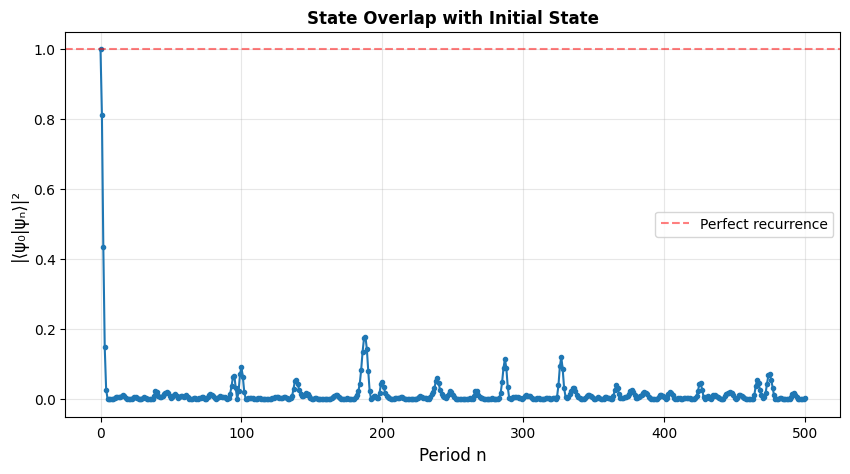

Overlap diagnostics:
  |⟨ψ₀|ψ₀⟩|² = 1.000000 (should be 1)
  |⟨ψ₀|ψ₁₀⟩|² = 0.003711
  |⟨ψ₀|ψ₅₀⟩|² = 0.003350


In [ ]:
def diagnose_evolution(psi0, U_floquet, n_test=50):
    """
    Check if the evolution operator is actually changing states.
    Compute overlap ⟨ψ₀|ψ_n⟩ to see if state returns to itself.
    """
    psi_n = psi0.copy()
    overlaps = []

    for n in range(n_test + 1):
        overlap = np.abs(np.vdot(psi0, psi_n))**2  # |⟨ψ₀|ψ_n⟩|²
        overlaps.append(overlap)
        psi_n = U_floquet @ psi_n

    plt.figure(figsize=(10, 5))
    plt.plot(range(n_test + 1), overlaps, 'o-', markersize=3)
    plt.xlabel('Period n', fontsize=12)
    plt.ylabel('|⟨ψ₀|ψₙ⟩|²', fontsize=12)
    plt.title('State Overlap with Initial State', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Perfect recurrence')
    plt.legend()
    plt.show()

    print(f"Overlap diagnostics:")
    print(f"  |⟨ψ₀|ψ₀⟩|² = {overlaps[0]:.6f} (should be 1)")
    print(f"  |⟨ψ₀|ψ₁₀⟩|² = {overlaps[10]:.6f}")
    print(f"  |⟨ψ₀|ψ₅₀⟩|² = {overlaps[-1]:.6f}")

    return overlaps
# ============================================
# PART 6: MAIN EXECUTION
# ============================================

# ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed
L = 8                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = np.pi/J_0     # Time period np.pi/J_0 or 2*np.pi/J_0
n_steps = 500        #Number of steps
    # =========================================

ising = FloquetIsingChain(L, J_0, h_0, g, TP, hbar=1.0)
ising.build_hamiltonians()
U_floquet_overlap = build_floquet_operator(ising)

#  Testing random states
overlaps = diagnose_evolution(random_states[0], U_floquet_overlap, n_steps)


## Analysing the eigenvalue spectrum

System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Floquet operator constructed:
  Shape: (256, 256)
  Unitarity check: ||U†U - I|| = 5.03e-13


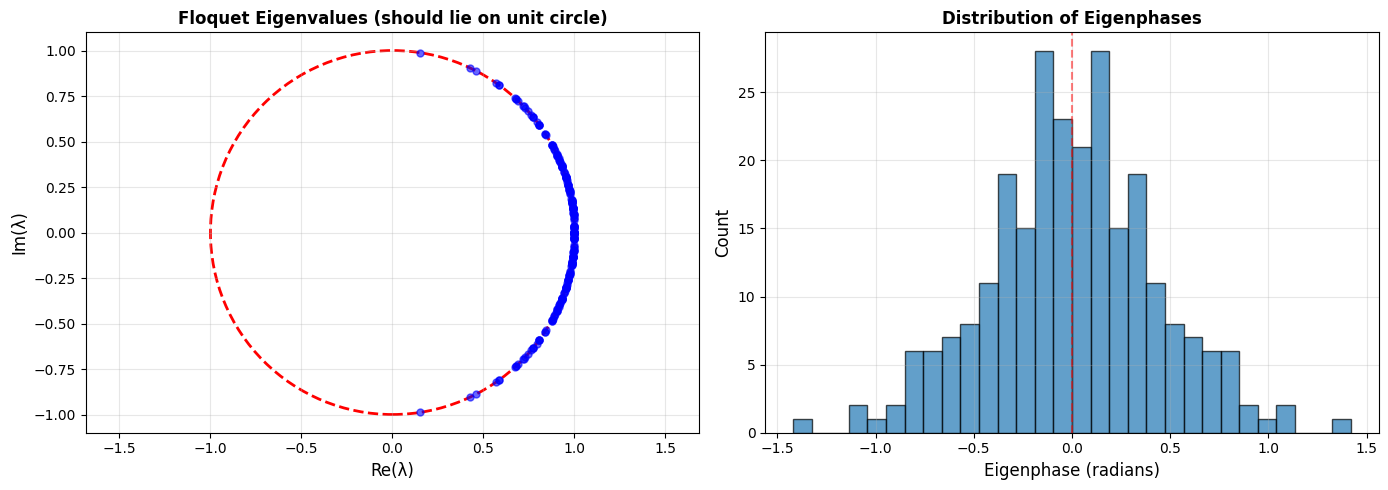


Floquet spectrum diagnostics:
  Number of eigenvalues: 256
  |λ| range: [1.000000, 1.000000] (should be ≈1)
  Max deviation from unit circle: 1.87e-14
  Are eigenphases clustered near 0? 48 / 256


In [ ]:
def analyze_floquet_spectrum(U_floquet):
    """
    Analyzing the eigenvalue spectrum of the Floquet operator.
    Eigenvalues should lie on the unit circle: |λ| = 1
    """
    eigenvalues = np.linalg.eigvals(U_floquet)
    eigenphases = np.angle(eigenvalues)  # Extract phases

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot eigenvalues on complex plane
    axes[0].plot(np.real(eigenvalues), np.imag(eigenvalues), 'bo', markersize=5, alpha=0.6)
    circle = plt.Circle((0, 0), 1, fill=False, color='r', linestyle='--', linewidth=2)
    axes[0].add_patch(circle)
    axes[0].set_xlabel('Re(λ)', fontsize=12)
    axes[0].set_ylabel('Im(λ)', fontsize=12)
    axes[0].set_title('Floquet Eigenvalues (should lie on unit circle)', fontweight='bold')
    axes[0].axis('equal')
    axes[0].grid(True, alpha=0.3)

    # Histogram of eigenphases
    axes[1].hist(eigenphases, bins=30, alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Eigenphase (radians)', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Distribution of Eigenphases', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Check unitarity
    mags = np.abs(eigenvalues)
    print(f"\nFloquet spectrum diagnostics:")
    print(f"  Number of eigenvalues: {len(eigenvalues)}")
    print(f"  |λ| range: [{np.min(mags):.6f}, {np.max(mags):.6f}] (should be ≈1)")
    print(f"  Max deviation from unit circle: {np.max(np.abs(mags - 1)):.2e}")
    print(f"  Are eigenphases clustered near 0? {np.sum(np.abs(eigenphases) < 0.1)} / {len(eigenphases)}")

    return eigenvalues, eigenphases
# ============================================
# PART 7: MAIN EXECUTION
# ============================================

# ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed
L = 8                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = np.pi/J_0     # Time period np.pi/J_0 or 2*np.pi/J_0
n_steps = 500        #Number of steps
    # =========================================

ising = FloquetIsingChain(L, J_0, h_0, g, TP, hbar=1.0)
ising.build_hamiltonians()
U_floquet_eigenspectrum = build_floquet_operator(ising)
eigenvalues, eigenphases = analyze_floquet_spectrum(U_floquet_eigenspectrum)

## Ensemble average autocorrelation plot for given time period and site i




### Results code

In [ ]:
def compute_ensemble_average(random_states, U_floquet, sigma_z_i, n_periods=500):
    """
    Average autocorrelation over an ensemble of random initial states.

    Returns:
    --------
    times : ndarray
        Time points (in units of periods)
    C_avg : ndarray
        Ensemble-averaged autocorrelation
    C_all : ndarray
        Individual autocorrelations (for analysis)
    """
    num_states = len(random_states)
    times = np.arange(n_periods + 1)

    # Store all autocorrelations
    C_all = np.zeros((num_states, n_periods + 1), dtype=complex)

    print(f"\nComputing autocorrelation for {num_states} states...")
    for i, psi0 in enumerate(random_states):
        times, C_t = compute_autocorrelation(psi0, U_floquet, sigma_z_i, n_periods)
        C_all[i, :] = C_t

        if (i + 1) % 5 == 0:
            print(f"  Completed {i+1}/{num_states} states")

    # Ensemble average
    C_avg = np.mean(C_all, axis=0)

    print(f"\nEnsemble statistics:")
    print(f"  Average C(0) = {C_avg[0]:.6f}")
    print(f"  Average C(500T) = {C_avg[-1]:.6f}")
    print(f"  Imaginary part at t=0: {np.imag(C_avg[0]):.2e}")

    return times, C_avg
# ============================================
# PART 8: MAIN EXECUTION
# ============================================

# ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed
L = 8                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = np.pi/J_0     # Time period np.pi/J_0 or 2*np.pi/J_0
site_i=L//2          # Bulk site which give non zero autocorrelation at TP = np.pi/J_0
n_steps = 500        #Number of steps
num_states = 2       # Number of states in the ensemble. The autocorrelation at site j is average autocorrelation over all the states

    # =========================================

ising = FloquetIsingChain(L, J_0, h_0, g, TP, hbar=1.0)
ising.build_hamiltonians()
U_floquet_ensembleavg = build_floquet_operator(ising)
sigma_z_i = build_sigma_z_i(ising, site_i)
# Compute ensemble average
dim = ising.basis.Ns
random_states = generate_random_states(dim, num_states)
times, C_avg = compute_ensemble_average(random_states, U_floquet_ensembleavg, sigma_z_i, n_periods=500)

System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Floquet operator constructed:
  Shape: (256, 256)
  Unitarity check: ||U†U - I|| = 5.03e-13
Hermiticity check passed!
Symmetry checks passed!

σ^z_L operator constructed:
  Acting on site 4
  Shape: (256, 256)
  Hermiticity check: ||H - H†|| = 0.00e+00

Generated 2 random initial states:
  Hilbert space dimension: 256
  Sample norm check: 1.000000

Computing autocorrelation for 2 states...

Ensemble statistics:
  Average C(0) = 1.000000+0.000000j
  Average C(500T) = 0.665113+0.021568j
  Imaginary part at t=0: 0.00e+00


### Plotting code

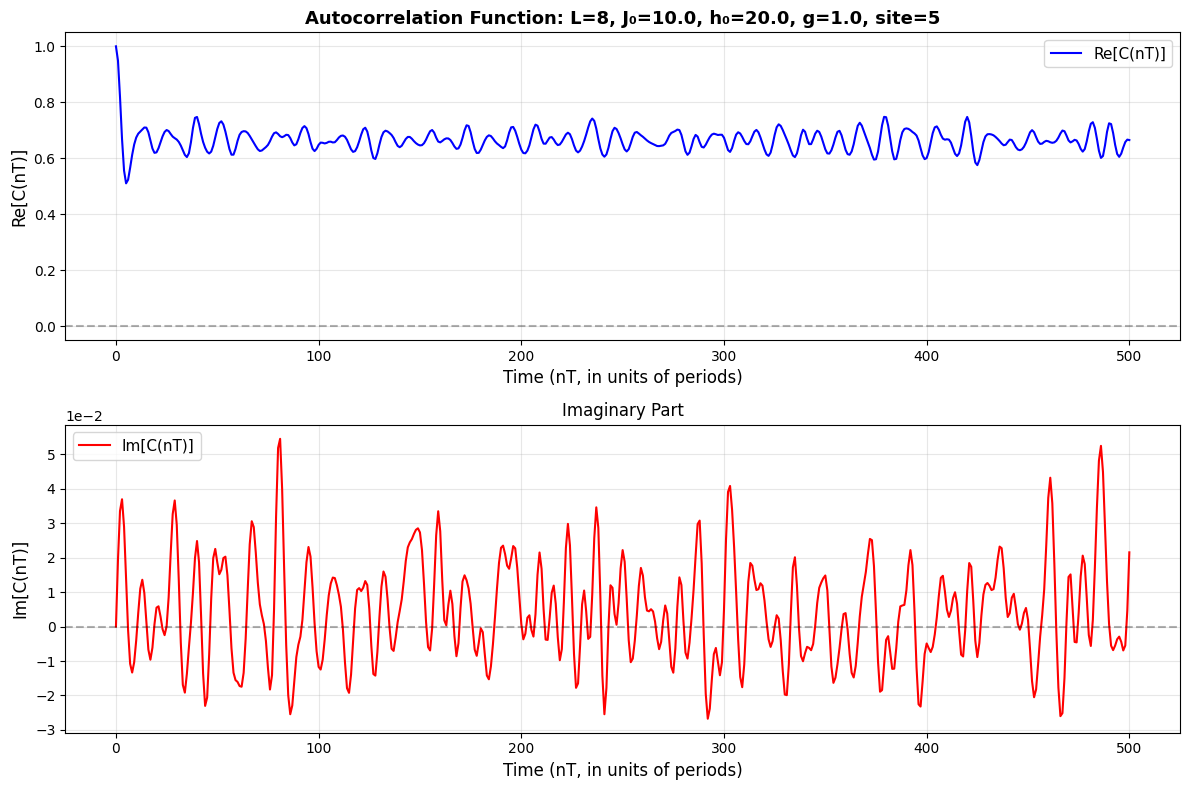

In [ ]:
def plot_autocorrelation(times, C_avg, ising_chain):
    """
    Plot ensemble-averaged autocorrelation function.
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Real part
    axes[0].plot(times, np.real(C_avg), 'b-', linewidth=1.5, label='Re[C(nT)]')
    axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[0].set_xlabel('Time (nT, in units of periods)', fontsize=12)
    axes[0].set_ylabel('Re[C(nT)]', fontsize=12)
    axes[0].set_title(f'Autocorrelation Function: L={ising_chain.L}, J₀={ising_chain.J_0}, h₀={ising_chain.h_0}, g={ising_chain.g}, site={L-3}',
                      fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Imaginary part
    axes[1].plot(times, np.imag(C_avg), 'r-', linewidth=1.5, label='Im[C(nT)]')
    axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1].set_xlabel('Time (nT, in units of periods)', fontsize=12)
    axes[1].set_ylabel('Im[C(nT)]', fontsize=12)
    axes[1].set_title('Imaginary Part', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].ticklabel_format(axis='y', style='scientific', scilimits=(-2, 2))

    plt.tight_layout()
    plt.show()

plot_autocorrelation(times, C_avg, ising)

## $C_i(t) $ w.r.t different potentials

### Results code

In [ ]:
# ============================================
# COMPUTATION FUNCTION
# ============================================

def run_autocorr_coupling_comparison(
    L=8,
    site_i=3,
    g=1.0,
    J_0_values=[4, 20, 40, 60],
    h_0_relation='2*J_0',
    NTP=2,
    n_steps=500,
    num_states=2
):
    """
    Compute autocorrelation for different coupling strengths.
    Period T = π/J_0 varies with J_0.

    Parameters:
    -----------
    L : int
        System size
    site_i : int
        Site index for measurement
    g : float
        Transverse field strength
    J_0_values : list
        List of J_0 values to scan
    h_0_relation : str or list
        If string: '2*J_0' means h_0 = 2*J_0 for all cases
        If list: custom h_0 values for each J_0
    NTP: float
         Time period factor N in TP= N*np.pi/J_0, where N can be any number
    n_periods : int
        Number of periods to evolve
    num_states : int
        Number of random initial states for ensemble

    Returns:
    --------
    results_dict : dict
        Dictionary with J_0 values as keys, each containing:
        {'times': array, 'C_avg': array, 'J_0': float, 'h_0': float, 'T': float}
    base_params : dict
        System parameters
    """

    # Determine h_0 values
    if isinstance(h_0_relation, str):
        if h_0_relation == '2*J_0':
            h_0_values = [2 * J_0 for J_0 in J_0_values]
        elif h_0_relation == 'J_0':
            h_0_values = [J_0 for J_0 in J_0_values]
        else:
            raise ValueError(f"Unknown relation: {h_0_relation}")
    else:
        h_0_values = h_0_relation
        if len(h_0_values) != len(J_0_values):
            raise ValueError("h_0_values must have same length as J_0_values")

    print("="*70)
    print("AUTOCORRELATION VS COUPLING STRENGTH COMPUTATION")
    print("="*70)
    print(f"System Parameters:")
    print(f"  L = {L}, site i = {site_i}, g = {g}")
    print(f"  Period: T = π/J_0 (varies with J_0)")
    print(f"  J_0 values: {J_0_values}")
    print(f"  h_0 relation: {h_0_relation}")
    print("="*70)

    # Storage
    results_dict = {}

    # Compute for each coupling strength
    for idx, (J_0, h_0) in enumerate(zip(J_0_values, h_0_values)):
        TP = NTP*np.pi / J_0  # Period depends on J_0

        print(f"\n{'─'*70}")
        print(f"[{idx+1}/{len(J_0_values)}] Computing J_0 = {J_0}, h_0 = {h_0}")
        print(f"                Period T = π/{J_0:.1f} = {TP:.6f}")
        print(f"{'─'*70}")

        # Initialize system
        ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
        ising.build_hamiltonians()

        # Build operators
        U_floquet = build_floquet_operator(ising)
        sigma_z_i = build_sigma_z_i(ising, site_i=site_i)

        # Generate random states
        random_states = generate_random_states(ising.basis.Ns, num_states=num_states, seed=42)

        # Compute ensemble average
        times, C_avg = compute_ensemble_average(random_states, U_floquet, sigma_z_i, n_steps)

        # Store results
        results_dict[J_0] = {
            'times': times,
            'C_avg': C_avg,
            'J_0': J_0,
            'h_0': h_0,
            'T': TP,
            'ratio': h_0/J_0
        }

        print(f"  ✓ Complete: C(0) = {np.real(C_avg[0]):.6f}, "
              f"C(final) = {np.real(C_avg[-1]):.6f}")

    # Store base parameters
    base_params = {
        'L': L,
        'site_i': site_i,
        'g': g,
        'num_states': num_states,
        'h_0_relation': h_0_relation
    }

    return results_dict, base_params
# ============================================
# PART 9: MAIN EXECUTION
# ============================================

# ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed
L = 8                # Chain length
J_0_list = [1, 5, 10, 40]
h_0_list = [1, 10, 20, 40]  # Note the J_0=40 case is different!
g = 1.0              # Transverse field strength
NTP = 2    # Time period factor N in TP= N*np.pi/J_0, where N can be any number
site_i=L//2          # Bulk site which give non zero autocorrelation at TP = np.pi/J_0
n_steps = 500        #Number of steps
num_states = 1       # Number of states in the ensemble. The autocorrelation at site j is average autocorrelation over all the states

    # =========================================


sigma_z_i = build_sigma_z_i(ising, site_i)
# Compute ensemble average
dim = ising.basis.Ns
random_states = generate_random_states(dim, num_states)


resultspotential, paramspotential = run_autocorr_coupling_comparison(
    L=L,
    site_i=site_i,
    g=g,
    J_0_values=J_0_list,
    h_0_relation=h_0_list,
    NTP=NTP,
    n_steps=n_steps,
    num_states=num_states
)


Hermiticity check passed!
Symmetry checks passed!

σ^z_L operator constructed:
  Acting on site 4
  Shape: (256, 256)
  Hermiticity check: ||H - H†|| = 0.00e+00

Generated 1 random initial states:
  Hilbert space dimension: 256
  Sample norm check: 1.000000
AUTOCORRELATION VS COUPLING STRENGTH COMPUTATION
System Parameters:
  L = 8, site i = 4, g = 1.0
  Period: T = π/J_0 (varies with J_0)
  J_0 values: [1, 5, 10, 40]
  h_0 relation: [1, 10, 20, 40]

──────────────────────────────────────────────────────────────────────
[1/4] Computing J_0 = 1, h_0 = 1
                Period T = π/1.0 = 6.283185
──────────────────────────────────────────────────────────────────────
System Parameters:
  Chain length L = 8
  J_0 = 1
  h_0 = 1
  g = 1.0
  Period T = 6.283185
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Floquet operator

### Plots code for presentation


CREATING PUBLICATION-QUALITY PLOT


/tmp/ipython-input-3767137794.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Saved publication-quality figures:
  - floquet_autocorr_coupling.pdf
  - floquet_autocorr_coupling.png


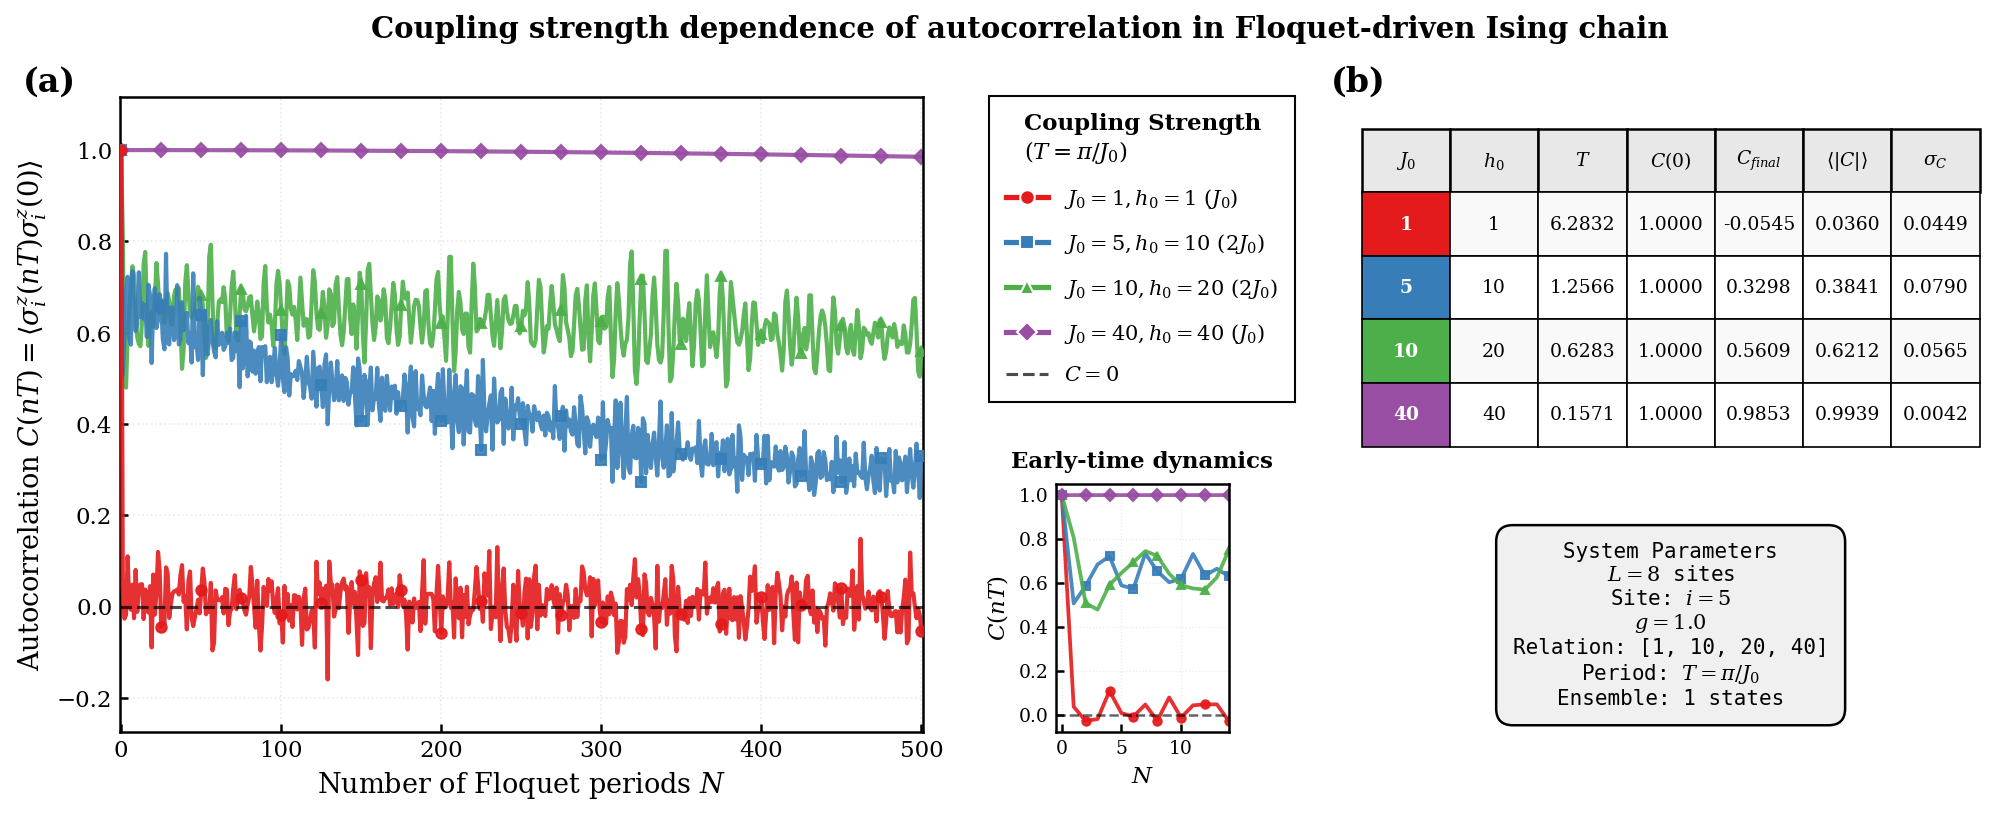


COUPLING STRENGTH DEPENDENCE STATISTICS

--------------------------------------------------------------------------------
J_0 = 1, h_0 = 1, T = 6.283185
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = -0.054531
  Range: [-0.159569, 1.000000]
  Steady-state (n>100):
    Mean |C| = 0.035952
    Std(C) = 0.044871

--------------------------------------------------------------------------------
J_0 = 5, h_0 = 10, T = 1.256637
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.329834
  Range: [0.237760, 1.000000]
  Steady-state (n>100):
    Mean |C| = 0.384125
    Std(C) = 0.079023

--------------------------------------------------------------------------------
J_0 = 10, h_0 = 20, T = 0.628319
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.560939
  Range: [0.479631, 1.000000]
  Steady-state (n>100)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import patches
import matplotlib.gridspec as gridspec




# ============================================
# PLOTTING FUNCTION
# ============================================

def plot_autocorr_coupling_comparison(results_dict, base_params):
    """
    Create publication-quality comparison plots for different coupling strengths.
    Format matches the period and site comparison plots.

    Parameters:
    -----------
    results_dict : dict
        Dictionary with J_0 values as keys
    base_params : dict
        Base system parameters
    """

    J_0_values = sorted(results_dict.keys())

    # Publication-quality settings
    plt.rcParams.update({
        'font.size': 11,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 1.2,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'legend.frameon': True,
        'legend.framealpha': 0.95,
        'legend.fancybox': False,
        'legend.edgecolor': 'black',
        'legend.borderpad': 0.5,
        'legend.columnspacing': 1.0,
    })

    # Professional color palette
    colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#A65628']
    markers = ['o', 's', '^', 'D', 'v', 'P']
    linestyles = ['-', '-', '-', '-', '-', '-']

    # Create figure with custom layout
    fig = plt.figure(figsize=(16, 5.5), dpi=150)

    # Create nested GridSpec
    gs_main = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.3, 0.28, 1], wspace=0.25)

    # Main plot
    ax1 = plt.subplot(gs_main[0])

    # Middle panel subdivided
    gs_middle = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[1],
                                                  height_ratios=[0.55, 0.45], hspace=0.3)
    ax_legend = plt.subplot(gs_middle[0])
    ax_legend.axis('off')

    ax_early = plt.subplot(gs_middle[1])

    # Statistics panel
    ax2 = plt.subplot(gs_main[2])

    # ============================================
    # PANEL A: Autocorrelation vs Periods
    # ============================================

    max_periods = max([len(results_dict[J_0]['C_avg']) for J_0 in J_0_values])

    for idx, J_0 in enumerate(J_0_values):
        data = results_dict[J_0]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        h_0 = data['h_0']
        ratio = data['ratio']

        # Create label
        if ratio == 2.0:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $(2J_0)$'
        elif ratio == 1.0:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $(J_0)$'
        else:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $({ratio:.1f}J_0)$'

        ax1.plot(periods, C_avg,
                marker=markers[idx],
                color=colors[idx],
                linewidth=2.0,
                markersize=5,
                markevery=max(1, len(periods)//20),
                label=label,
                alpha=0.9,
                linestyle=linestyles[idx],
                zorder=5-idx)

    # Add zero line
    ax1.axhline(0, color='black', linestyle='--',
               linewidth=1.5, alpha=0.7, zorder=10)

    # Formatting
    ax1.set_xlabel("Number of Floquet periods $N$", fontsize=13, fontweight='normal')
    ax1.set_ylabel(r"Autocorrelation $C(nT) = \langle \sigma^z_i(nT) \sigma^z_i(0) \rangle$",
                   fontsize=13, fontweight='normal')
    ax1.set_xlim(-1, max_periods)

    # Set y-limits
    all_data = np.concatenate([np.real(results_dict[J_0]['C_avg']) for J_0 in J_0_values])
    y_min, y_max = np.min(all_data), np.max(all_data)
    y_range = y_max - y_min
    ax1.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

    # Grid
    ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.8, zorder=0)

    # Panel label
    ax1.text(-0.12, 1.05, '(a)', transform=ax1.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # ============================================
    # LEGEND PANEL
    # ============================================

    from matplotlib.lines import Line2D
    legend_elements = []
    legend_labels = []

    for idx, J_0 in enumerate(J_0_values):
        data = results_dict[J_0]
        h_0 = data['h_0']
        ratio = data['ratio']

        if ratio == 2.0:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $(2J_0)$'
        elif ratio == 1.0:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $(J_0)$'
        else:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $({ratio:.1f}J_0)$'

        legend_elements.append(Line2D([0], [0], color=colors[idx],
                                     linewidth=2.5, marker=markers[idx],
                                     markersize=7, markeredgecolor='white', markeredgewidth=1))
        legend_labels.append(label)

    # Add zero line
    legend_elements.append(Line2D([0], [0], color='black', linewidth=1.5,
                                  linestyle='--', alpha=0.7))
    legend_labels.append('$C=0$')

    # Place legend
    legend = ax_legend.legend(legend_elements, legend_labels,
                             loc='center',
                             fontsize=10,
                             frameon=True,
                             framealpha=0.98,
                             edgecolor='black',
                             fancybox=False,
                             title='Coupling Strength\n$(T=\\pi/J_0)$',
                             title_fontsize=11,
                             labelspacing=1.0,
                             borderpad=0.8)
    legend.get_title().set_weight('bold')

    # ============================================
    # EARLY DYNAMICS PANEL
    # ============================================

    for idx, J_0 in enumerate(J_0_values):
        data = results_dict[J_0]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        ax_early.plot(periods[:15], C_avg[:15],
                     marker=markers[idx], color=colors[idx],
                     linewidth=1.8, markersize=4,
                     markevery=2, alpha=0.9)

    ax_early.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax_early.set_xlabel("$N$", fontsize=11, fontweight='normal')
    ax_early.set_ylabel("$C(nT)$", fontsize=11, fontweight='normal')
    ax_early.set_title("Early-time dynamics", fontsize=11, fontweight='bold', pad=8)
    ax_early.tick_params(labelsize=9, direction='in')
    ax_early.grid(True, alpha=0.25, linestyle=':', linewidth=0.6)
    ax_early.set_xlim(-0.5, 14)

    for spine in ax_early.spines.values():
        spine.set_linewidth(1.2)

    # ============================================
    # PANEL B: Statistics Table
    # ============================================

    ax2.axis('off')

    # Create table
    table_data = []
    headers = ['$J_0$', '$h_0$', '$T$', '$C(0)$', '$C_{final}$',
               '$\\langle|C|\\rangle$', '$\\sigma_C$']

    n_start = 100

    for idx, J_0 in enumerate(J_0_values):
        data = results_dict[J_0]
        h_0 = data['h_0']
        T = data['T']
        C_avg = np.real(data['C_avg'])
        C_initial = C_avg[0]
        C_final = C_avg[-1]

        # Statistics
        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            mean_abs = np.mean(np.abs(C_steady))
            std_C = np.std(C_steady)
        else:
            mean_abs = np.mean(np.abs(C_avg))
            std_C = np.std(C_avg)

        table_data.append([
            f'{J_0:.0f}',
            f'{h_0:.0f}',
            f'{T:.4f}',
            f'{C_initial:.4f}',
            f'{C_final:.4f}',
            f'{mean_abs:.4f}',
            f'{std_C:.4f}'
        ])

    # Create table
    table = ax2.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='upper center',
                     bbox=[0.0, 0.45, 1.0, 0.50])

    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.0)

    # Header styling
    for i in range(len(headers)):
        cell = table[(0, i)]
        cell.set_facecolor('#E8E8E8')
        cell.set_text_props(weight='bold', fontsize=9)
        cell.set_edgecolor('black')
        cell.set_linewidth(1.2)

    # Data cells styling
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            cell = table[(i, j)]
            cell.set_facecolor('white' if i % 2 == 0 else '#F9F9F9')
            cell.set_edgecolor('black')
            cell.set_linewidth(0.8)
            # Color code by J_0
            if j == 0:  # J_0 column
                cell.set_facecolor(colors[i-1])
                cell.set_text_props(color='white', weight='bold')

    # System parameters box
    param_text = "System Parameters\n"
    param_text += f"$L = {base_params['L']}$ sites\n"
    param_text += f"Site: $i = {base_params['site_i']+1}$\n"
    param_text += f"$g = {base_params['g']:.1f}$\n"
    param_text += f"Relation: {base_params['h_0_relation']}\n"
    param_text += f"Period: $T = \\pi/J_0$\n"
    param_text += f"Ensemble: {base_params['num_states']} states"

    ax2.text(0.5, 0.30, param_text, transform=ax2.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F0F0F0',
                     edgecolor='black', linewidth=1.2),
            family='monospace')

    # Panel label
    ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # Overall title
    fig.suptitle("Coupling strength dependence of autocorrelation in Floquet-driven Ising chain",
                fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save
    plt.savefig('floquet_autocorr_coupling.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('floquet_autocorr_coupling.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved publication-quality figures:")
    print("  - floquet_autocorr_coupling.pdf")
    print("  - floquet_autocorr_coupling.png")

    plt.show()

    # Detailed statistics
    print("\n" + "="*80)
    print("COUPLING STRENGTH DEPENDENCE STATISTICS")
    print("="*80)

    for J_0 in J_0_values:
        data = results_dict[J_0]
        h_0 = data['h_0']
        T = data['T']
        C_avg = np.real(data['C_avg'])

        print(f"\n{'-'*80}")
        print(f"J_0 = {J_0}, h_0 = {h_0}, T = {T:.6f}")
        print(f"{'-'*80}")
        print(f"  C(0) = {C_avg[0]:.6f}")
        print(f"  C(final) = {C_avg[-1]:.6f}")
        print(f"  Range: [{np.min(C_avg):.6f}, {np.max(C_avg):.6f}]")

        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            print(f"  Steady-state (n>{n_start}):")
            print(f"    Mean |C| = {np.mean(np.abs(C_steady)):.6f}")
            print(f"    Std(C) = {np.std(C_steady):.6f}")

    print("\n" + "="*80)
    print("COMPARATIVE ANALYSIS")
    print("="*80)
    print(f"{'J_0':<10} {'h_0':<10} {'Period T':<15} {'Mean |C|':<15} {'Std(C)':<15}")
    print("-"*65)

    for J_0 in J_0_values:
        data = results_dict[J_0]
        h_0 = data['h_0']
        T = data['T']
        C_avg = np.real(data['C_avg'])

        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            mean_abs = np.mean(np.abs(C_steady))
            std_C = np.std(C_steady)
        else:
            mean_abs = np.mean(np.abs(C_avg))
            std_C = np.std(C_avg)

        print(f"{J_0:<10.0f} {h_0:<10.0f} {T:<15.6f} {mean_abs:<15.6f} {std_C:<15.6f}")

    print("="*80)

    plt.rcParams.update(plt.rcParamsDefault)



# Create publication plot
print("\n" + "="*80)
print("CREATING PUBLICATION-QUALITY PLOT")
print("="*80)
plot_autocorr_coupling_comparison(resultspotential, paramspotential)

### Plots code for publication

Figure saved to: autocorr_coupling_comparison.pdf


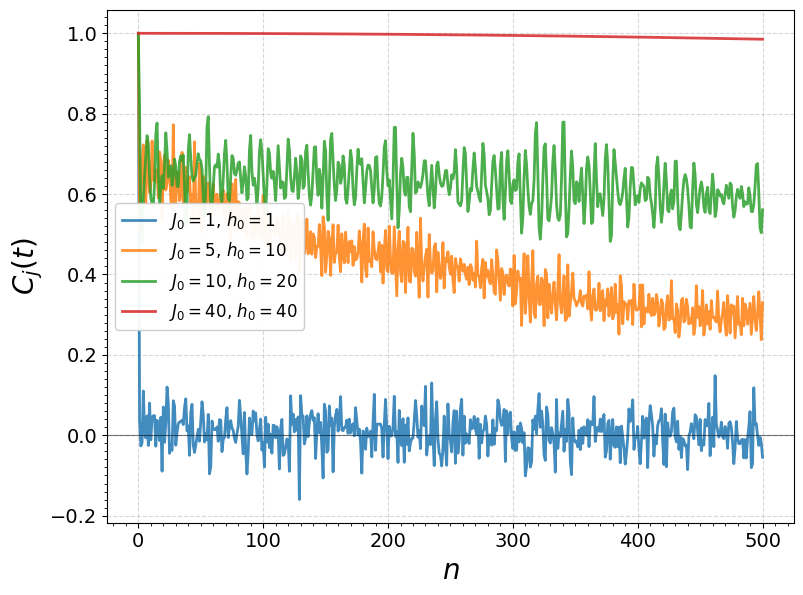

In [ ]:
from matplotlib.ticker import StrMethodFormatter
from matplotlib import style
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.ticker as tck
from matplotlib import rc, rcParams
import matplotlib as mpl
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import pickle
import matplotlib
import glob
import matplotlib.pyplot as plt
import glob



def plot_autocorr_coupling_pub(results, params, save_path=None):
    """
    Create publication-quality plot for autocorrelation vs coupling strength.

    Parameters:
    -----------
    results : dict
        Results dictionary containing times, C_avg, J_0, h_0, T, ratio for each J_0
    params : dict
        Parameter dictionary containing L, site_i, g, num_states, h_0_relation
    save_path : str, optional
        Path to save the figure
    """

    # ========== EASILY MODIFIABLE PARAMETERS ==========
    # Axis labels
    xlabel_text = r'$n$'
    ylabel_text = r'$C_j(t)$'

    # Figure size: optimized for 2 side-by-side on A4 paper
    fig_width = 8.0   # inches
    fig_height = 6.0  # inches

    # Legend position: 'best', 'upper right', 'lower left', etc.
    legend_loc = 'best'
    legend_fontsize = 12

    # Colors for different J_0 values
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    # Line properties
    linewidth = 2.0
    alpha = 0.85

    # Grid properties
    show_grid = True
    grid_alpha = 0.5
    grid_linestyle = '--'

    # Show zero line
    show_zero_line = True
    # ==================================================

    # Create figure
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # J_0 values in order
    J_0_values = sorted(results.keys())

    # Plot each J_0 value
    for idx, J_0 in enumerate(J_0_values):
        times = results[J_0]['times']
        C_avg = np.real(results[J_0]['C_avg'])
        h_0 = results[J_0]['h_0']
        periods = np.arange(len(C_avg))

        # Plot period number vs autocorrelation
        ax.plot(periods, C_avg,
                label=f'$J_0 = {J_0}$, $h_0 = {h_0}$',
                color=colors[idx % len(colors)],
                linewidth=linewidth,
                alpha=alpha)

    # Set labels
    ax.set_xlabel(xlabel_text, fontsize=20)
    ax.set_ylabel(ylabel_text, fontsize=20)

    # Legend
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, framealpha=0.95)

    # Grid
    if show_grid:
        ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    # Zero line
    if show_zero_line:
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)

    # Set minor locators
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.yaxis.set_minor_locator(AutoMinorLocator(10))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

    return fig, ax


# Generate plot
fig_coupling, ax_coupling = plot_autocorr_coupling_pub(
    resultspotential,
    paramspotential,
    save_path='autocorr_coupling_comparison.pdf'
)

## $C_i(t)$ w.r.t different time periods

### Results code

In [ ]:
def run_autocorr_period_comparison(L=8, J_0=10.0, h_0=20.0, g=1.0, site_i=3,
                                    period_factors=[0.25, 0.5, 1, 2, 3, 4],
                                    n_periods=500, num_states=20):
    """
    Run autocorrelation analysis for multiple periods and create publication plot.

    Parameters:
    -----------
    L : int
        Chain length
    J_0, h_0, g : float
        Hamiltonian parameters
    site_i : int
        Site index for measurement
    period_factors : list
        List of n values where T = n*π/J_0
    n_periods : int
        Number of periods to evolve
    num_states : int
        Number of random initial states for ensemble
    """

    results_dict = {}

    print("="*70)
    print("AUTOCORRELATION PERIOD COMPARISON")
    print("="*70)
    print(f"Computing for {len(period_factors)} different periods...")
    print("="*70)

    for n in period_factors:
        TP = n * np.pi / J_0

        print(f"\n{'─'*70}")
        print(f"Computing T = {n}π/J₀ = {TP:.6f}")
        print(f"{'─'*70}")

        # Initialize system
        ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
        ising.build_hamiltonians()

        # Build operators
        U_floquet = build_floquet_operator(ising)
        sigma_z_i = build_sigma_z_i(ising, site_i=site_i)

        # Generate random states
        random_states = generate_random_states(ising.basis.Ns, num_states=num_states, seed=42)

        # Compute ensemble average
        times, C_avg = compute_ensemble_average(random_states, U_floquet, sigma_z_i, n_periods)

        # Store results
        results_dict[n] = {
            'times': times,
            'C_avg': C_avg,
            'T': TP
        }

        print(f"  ✓ Complete: C(0) = {np.real(C_avg[0]):.6f}, "
              f"C(final) = {np.real(C_avg[-1]):.6f}")

    # Store base parameters
    base_params = {
        'L': L,
        'J_0': J_0,
        'h_0': h_0,
        'g': g,
        'site_i': site_i,
        'num_states': num_states
    }

    # Create publication plot
    print("\n" + "="*70)
    print("CREATING PUBLICATION-QUALITY FIGURE")
    print("="*70)


    return results_dict, base_params

# ============================================
# PART 10: MAIN EXECUTION
# ============================================

# ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed
L = 8                # Chain length
J_0 = 8.0           # Ising coupling strength
h_0 = 32.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
period_factors=[0.25, 0.5, 1, 2, 3, 4]    # Time period factor N in TP= N*np.pi/J_0, where N can be any number
site_i=L//2          # Bulk site which give non zero autocorrelation at TP = np.pi/J_0
n_steps = 500        #Number of steps
num_states = 1       # Number of states in the ensemble. The autocorrelation at site j is average autocorrelation over all the states

    # =========================================

#For a bulk site
resultsbulkTP, paramsbulkTP = run_autocorr_period_comparison(
    L=L,
    J_0=J_0,
    h_0=h_0,
    g=g,
    site_i=site_i,
    period_factors=period_factors,
    n_periods=n_steps,
    num_states=num_states
)

#For an edge site
site_i2=L-1

resultsedgeTP, paramsedgeTP = run_autocorr_period_comparison(
    L=L,
    J_0=J_0,
    h_0=h_0,
    g=g,
    site_i=site_i2,
    period_factors=period_factors,
    n_periods=n_steps,
    num_states=num_states
)

AUTOCORRELATION PERIOD COMPARISON
Computing for 6 different periods...

──────────────────────────────────────────────────────────────────────
Computing T = 0.25π/J₀ = 0.098175
──────────────────────────────────────────────────────────────────────
System Parameters:
  Chain length L = 8
  J_0 = 8.0
  h_0 = 32.0
  g = 1.0
  Period T = 0.098175
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Floquet operator constructed:
  Shape: (256, 256)
  Unitarity check: ||U†U - I|| = 8.04e-14
Hermiticity check passed!
Symmetry checks passed!

σ^z_L operator constructed:
  Acting on site 4
  Shape: (256, 256)
  Hermiticity check: ||H - H†|| = 0.00e+00

Generated 1 random initial states:
  Hilbert space dimension: 256
  Sample norm check: 1.000000

Computing autocorrelation for 1 states...

Ensemble statistics:
  Average C(0) = 1.000

### Plots code for presentations

FLOQUET AUTOCORRELATION: PERIOD COMPARISON

CREATING BULK SITE FIGURES


/tmp/ipython-input-3541373505.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Saved publication-quality figures:
  - floquet_autocorr_periods_site4.pdf
  - floquet_autocorr_periods_site4.png


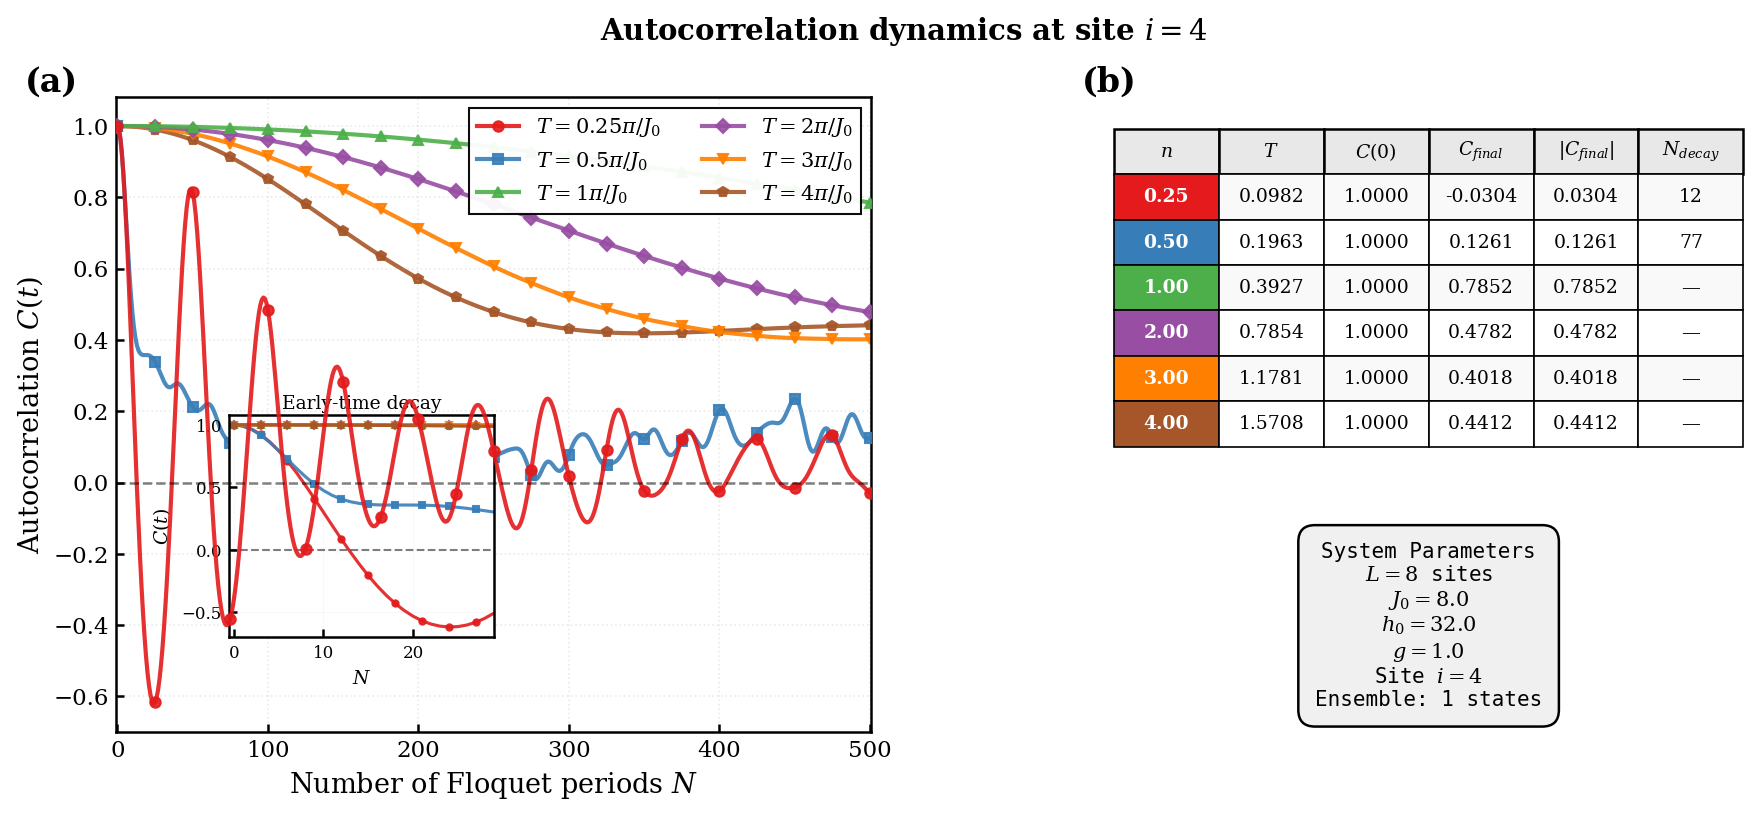


DETAILED STATISTICS

--------------------------------------------------------------------------------
Period factor n = 0.25: T = 0.25π/J₀ = 0.098175
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = -0.030429
  |C(final)| = 0.030429
  Mean |C| = 0.164607
  Decay benchmarks:
    |C| < 0.1: N =  12 periods (t =  12.00)
    |C| < 0.05: N =  13 periods (t =  13.00)

--------------------------------------------------------------------------------
Period factor n = 0.5: T = 0.5π/J₀ = 0.196350
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.126112
  |C(final)| = 0.126112
  Mean |C| = 0.129905
  Decay benchmarks:
    |C| < 0.1: N =  77 periods (t =  77.00)
    |C| < 0.05: N =  83 periods (t =  83.00)

--------------------------------------------------------------------------------
Period factor n = 1: T = 1π/J₀ = 0.392699
--------------------------------------------

/tmp/ipython-input-3541373505.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Saved publication-quality figures:
  - floquet_autocorr_periods_site7.pdf
  - floquet_autocorr_periods_site7.png


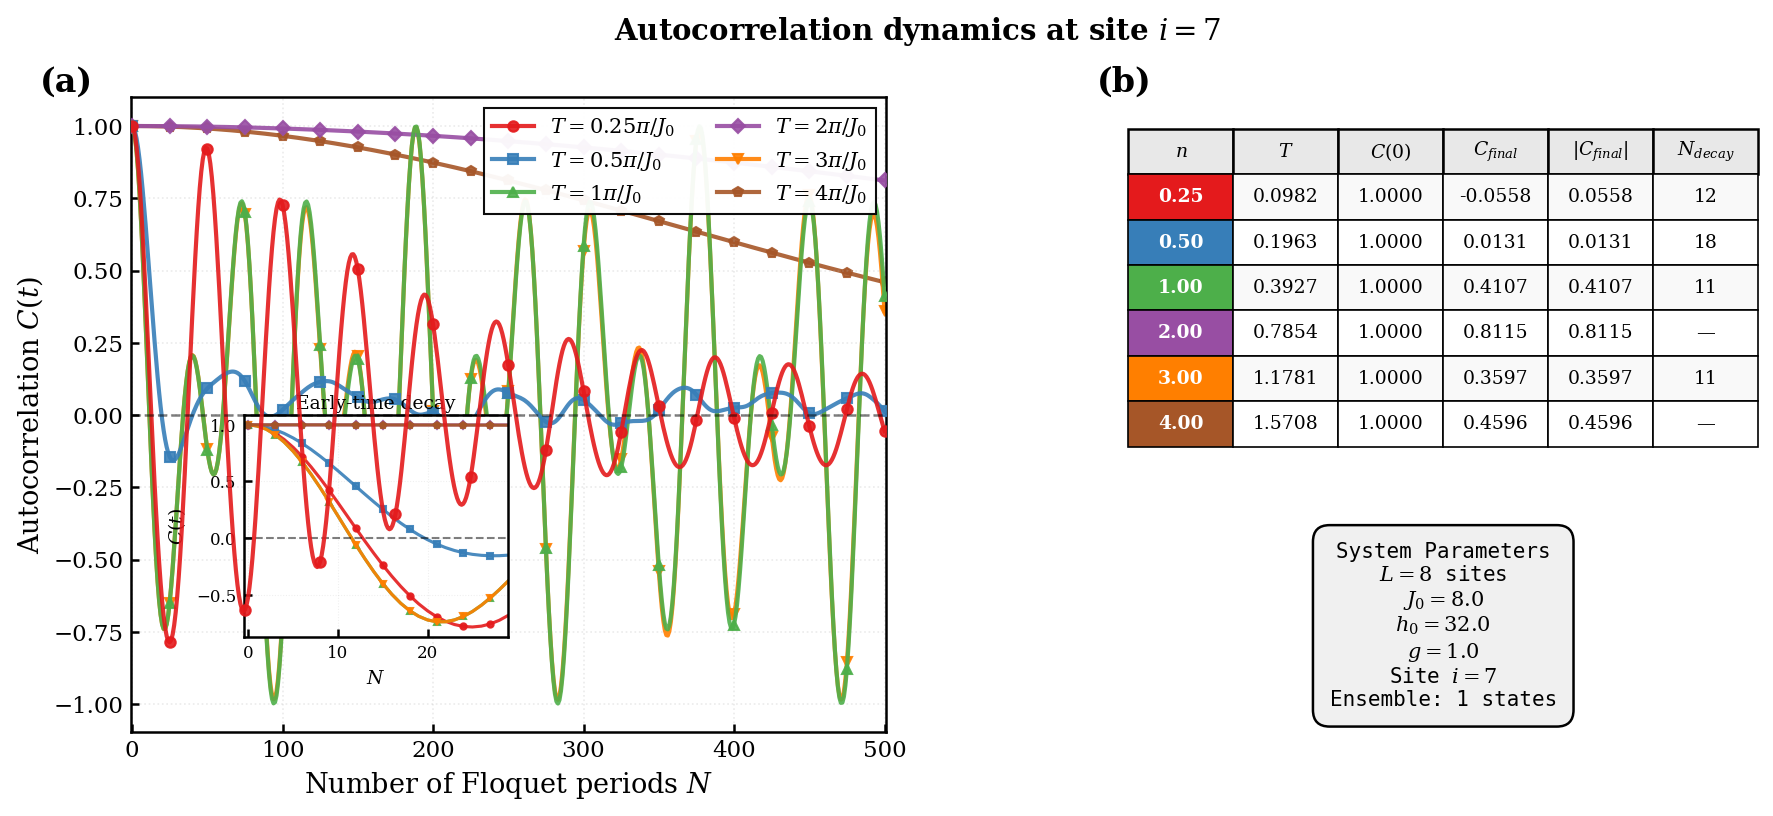


DETAILED STATISTICS

--------------------------------------------------------------------------------
Period factor n = 0.25: T = 0.25π/J₀ = 0.098175
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = -0.055810
  |C(final)| = 0.055810
  Mean |C| = 0.253453
  Decay benchmarks:
    |C| < 0.1: N =  12 periods (t =  12.00)
    |C| < 0.05: N =  13 periods (t =  13.00)

--------------------------------------------------------------------------------
Period factor n = 0.5: T = 0.5π/J₀ = 0.196350
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.013050
  |C(final)| = 0.013050
  Mean |C| = 0.073847
  Decay benchmarks:
    |C| < 0.1: N =  18 periods (t =  18.00)
    |C| < 0.05: N =  19 periods (t =  19.00)

--------------------------------------------------------------------------------
Period factor n = 1: T = 1π/J₀ = 0.392699
--------------------------------------------

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import patches
import matplotlib.gridspec as gridspec

def plot_autocorr_period_comparison(results_dict, base_params):
    """
    Create publication-quality comparison plots for autocorrelation at different periods.
    """
    period_factors = sorted(results_dict.keys())
    site_i = base_params['site_i']

    # Publication-quality settings
    plt.rcParams.update({
        'font.size': 11,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 1.2,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'legend.frameon': True,
        'legend.framealpha': 0.95,
        'legend.fancybox': False,
        'legend.edgecolor': 'black',
    })

    # Professional color palette
    colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#A65628']
    markers = ['o', 's', '^', 'D', 'v', 'p']
    linestyles = ['-', '-', '-', '-', '-', '-']

    # Create figure
    fig = plt.figure(figsize=(14, 5.5), dpi=150)
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.35)

    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1])

    # ============================================
    # PANEL A: Autocorrelation vs Number of Periods
    # ============================================

    # Get max periods
    max_periods = max([len(results_dict[n]['C_avg']) for n in period_factors])

    # Plot data for each period
    for i, n in enumerate(period_factors):
        data = results_dict[n]
        times = data['times']
        C_avg = np.real(data['C_avg'])
        T = data['T']
        periods = np.arange(len(C_avg))

        # Main plot
        label = f'$T = {n}\\pi/J_0$'
        ax1.plot(periods, C_avg,
                marker=markers[i],
                color=colors[i],
                linewidth=2.0,
                markersize=5,
                markevery=max(1, len(periods)//20),
                label=label,
                alpha=0.9,
                linestyle=linestyles[i],
                zorder=6-i)

    # Add reference line at C=0
    ax1.axhline(0, color='black', linestyle='--',
               linewidth=1.2, alpha=0.5, zorder=10)

    # Formatting
    ax1.set_xlabel("Number of Floquet periods $N$", fontsize=13, fontweight='normal')
    ax1.set_ylabel("Autocorrelation $C(t)$", fontsize=13, fontweight='normal')
    ax1.set_xlim(-1, max_periods)

    # Grid
    ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.8, zorder=0)

    # Legend
    legend = ax1.legend(loc='upper right', fontsize=10, ncol=2,
                       framealpha=0.95, edgecolor='black', fancybox=False)
    legend.set_zorder(20)

    # Panel label
    ax1.text(-0.12, 1.05, '(a)', transform=ax1.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # Add inset for early-time behavior
    axins = ax1.inset_axes([0.15, 0.15, 0.35, 0.35])
    for i, n in enumerate(period_factors):
        data = results_dict[n]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        axins.plot(periods[:30], C_avg[:30],
                  marker=markers[i], color=colors[i],
                  linewidth=1.5, markersize=3,
                  markevery=3, alpha=0.9)

    axins.axhline(0, color='black', linestyle='--', linewidth=1.0, alpha=0.5)
    axins.set_xlabel("$N$", fontsize=9)
    axins.set_ylabel("$C(t)$", fontsize=9)
    axins.set_title("Early-time decay", fontsize=9, pad=3)
    axins.tick_params(labelsize=8)
    axins.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)
    axins.set_xlim(-0.5, 29)

    # ============================================
    # PANEL B: Statistics Table and Info
    # ============================================

    ax2.axis('off')

    # Create professional table
    table_data = []
    headers = ['$n$', '$T$', '$C(0)$', '$C_{final}$',
               '$|C_{final}|$', '$N_{decay}$']

    for n in period_factors:
        data = results_dict[n]
        T = data['T']
        C_avg = np.real(data['C_avg'])
        C_0 = C_avg[0]
        C_final = C_avg[-1]

        # Find when |C| < 0.1 (significant decay)
        idx_decay = np.where(np.abs(C_avg) < 0.1)[0]
        N_decay = idx_decay[0] if len(idx_decay) > 0 else -1

        table_data.append([
            f'{n:.2f}',
            f'{T:.4f}',
            f'{C_0:.4f}',
            f'{C_final:.4f}',
            f'{np.abs(C_final):.4f}',
            f'{N_decay}' if N_decay >= 0 else '—'
        ])

    # Create table
    table = ax2.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='upper center',
                     bbox=[0.0, 0.45, 1.0, 0.50])

    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.0)

    # Header styling
    for i in range(len(headers)):
        cell = table[(0, i)]
        cell.set_facecolor('#E8E8E8')
        cell.set_text_props(weight='bold', fontsize=9)
        cell.set_edgecolor('black')
        cell.set_linewidth(1.2)

    # Data cells styling
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            cell = table[(i, j)]
            cell.set_facecolor('white' if i % 2 == 0 else '#F9F9F9')
            cell.set_edgecolor('black')
            cell.set_linewidth(0.8)
            # Color code by period
            if j == 0:  # n column
                cell.set_facecolor(colors[i-1])
                cell.set_text_props(color='white', weight='bold')

    # Add system parameters box
    param_text = "System Parameters\n"
    param_text += f"$L = {base_params['L']}$ sites\n"
    param_text += f"$J_0 = {base_params['J_0']:.1f}$\n"
    param_text += f"$h_0 = {base_params['h_0']:.1f}$\n"
    param_text += f"$g = {base_params['g']:.1f}$\n"
    param_text += f"Site $i = {base_params['site_i']}$\n"
    param_text += f"Ensemble: {base_params['num_states']} states"

    ax2.text(0.5, 0.30, param_text, transform=ax2.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F0F0F0',
                     edgecolor='black', linewidth=1.2),
            family='monospace')

    # Panel label
    ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # Overall title
    fig.suptitle(f"Autocorrelation dynamics at site $i = {site_i}$",
                fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save figures
    plt.savefig(f'floquet_autocorr_periods_site{site_i}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'floquet_autocorr_periods_site{site_i}.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved publication-quality figures:")
    print(f"  - floquet_autocorr_periods_site{site_i}.pdf")
    print(f"  - floquet_autocorr_periods_site{site_i}.png")

    plt.show()

    # ============================================
    # Detailed Statistics
    # ============================================

    print("\n" + "="*80)
    print("DETAILED STATISTICS")
    print("="*80)

    for n in period_factors:
        data = results_dict[n]
        times = data['times']
        C_avg = np.real(data['C_avg'])
        T = data['T']

        print(f"\n{'-'*80}")
        print(f"Period factor n = {n}: T = {n}π/J₀ = {T:.6f}")
        print(f"{'-'*80}")
        print(f"  C(0) = {C_avg[0]:.6f}")
        print(f"  C(final) = {C_avg[-1]:.6f}")
        print(f"  |C(final)| = {np.abs(C_avg[-1]):.6f}")
        print(f"  Mean |C| = {np.mean(np.abs(C_avg)):.6f}")

        # Decay analysis
        idx_01 = np.where(np.abs(C_avg) < 0.1)[0]
        idx_005 = np.where(np.abs(C_avg) < 0.05)[0]

        print(f"  Decay benchmarks:")
        if len(idx_01) > 0:
            print(f"    |C| < 0.1: N = {idx_01[0]:3d} periods (t = {times[idx_01[0]]:6.2f})")
        if len(idx_005) > 0:
            print(f"    |C| < 0.05: N = {idx_005[0]:3d} periods (t = {times[idx_005[0]]:6.2f})")

    print("\n" + "="*80)

    # Reset matplotlib parameters
    plt.rcParams.update(plt.rcParamsDefault)


# ============================================
# MAIN EXECUTION
# ============================================

print("="*80)
print("FLOQUET AUTOCORRELATION: PERIOD COMPARISON")
print("="*80)


print("\n" + "="*80)
print("CREATING BULK SITE FIGURES")
print("="*80)

# Plot for bulk site
plot_autocorr_period_comparison(resultsbulkTP, paramsbulkTP)  # Two-panel


print("\n" + "="*80)
print("CREATING EDGE SITE FIGURES")
print("="*80)

# Plot for edge site
plot_autocorr_period_comparison(resultsedgeTP, paramsedgeTP)  # Two-panel

print("\n" + "="*80)
print("ALL FIGURES GENERATED SUCCESSFULLY")
print("="*80)

### Plots for publication

Figure saved to: autocorr_bulk_site3.pdf


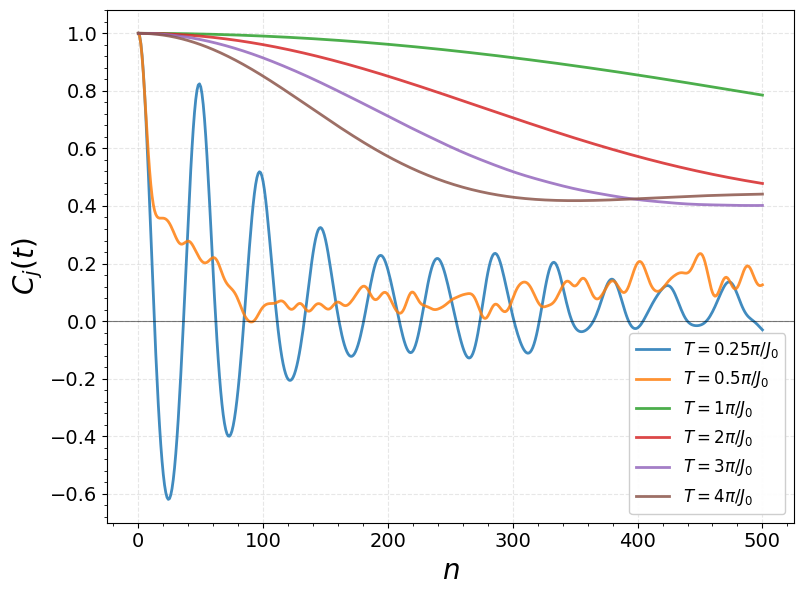

Figure saved to: autocorr_edge_site7.pdf


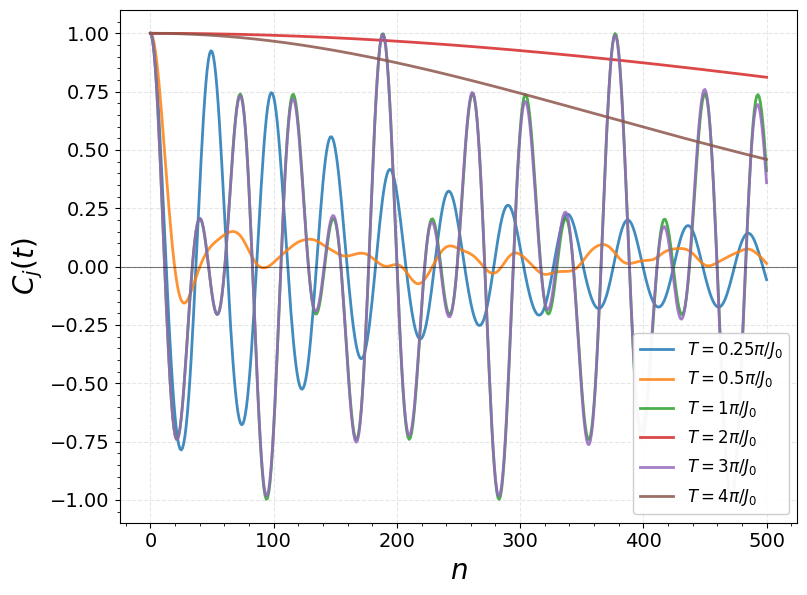

In [ ]:
from matplotlib.ticker import StrMethodFormatter
from matplotlib import style
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.ticker as tck
from matplotlib import rc, rcParams
import matplotlib as mpl
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import pickle
import matplotlib
import glob
import matplotlib.pyplot as plt
import glob
def plot_autocorr_single(results, params, save_path=None):
    """
    Create publication-quality plot for autocorrelation at a single site.

    Parameters:
    -----------
    results : dict
        Results dictionary containing times, C_avg, and T for each period factor
    params : dict
        Parameter dictionary containing L, J_0, h_0, g, site_i, num_states
    save_path : str, optional
        Path to save the figure
    """

    # ========== EASILY MODIFIABLE PARAMETERS ==========
    # Axis labels
    xlabel_text = r'$n$'
    ylabel_text = r'$C_j(t)$'

    # Figure size: optimized for 2 side-by-side on A4 paper
    fig_width = 8.0   # inches
    fig_height = 6.0  # inches

    # Legend position: 'best', 'upper right', 'lower left', etc.
    legend_loc = 'best'
    legend_fontsize = 12

    # Colors for different periods
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    # Line properties
    linewidth = 2.0
    alpha = 0.85

    # Grid properties
    show_grid = True
    grid_alpha = 0.3
    grid_linestyle = '--'

    # Show zero line
    show_zero_line = True
    # ==================================================

    # Create figure
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Period factors in order
    period_factors = sorted(results.keys())

    # Plot each period
    for idx, n in enumerate(period_factors):
        times = results[n]['times']
        C_avg = np.real(results[n]['C_avg'])
        periods = np.arange(len(C_avg))

        # Plot with time normalized by period
        ax.plot(periods, C_avg,
                label=f'$T = {n}\\pi/J_0$',
                color=colors[idx],
                linewidth=linewidth,
                alpha=alpha)

    # Set labels
    ax.set_xlabel(xlabel_text, fontsize=20)
    ax.set_ylabel(ylabel_text, fontsize=20)

    # Legend
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, framealpha=0.95)

    # Grid
    if show_grid:
        ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    # Zero line
    if show_zero_line:
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)

    # Set minor locators
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

    return fig, ax


# Generate bulk site plot
fig_bulk, ax_bulk = plot_autocorr_single(
    resultsbulkTP,
    paramsbulkTP,
    save_path='autocorr_bulk_site3.pdf'
)

# Generate edge site plot
fig_edge, ax_edge = plot_autocorr_single(
    resultsedgeTP,
    paramsedgeTP,
    save_path='autocorr_edge_site7.pdf'
)

## $C_i(t)$ w.r.t different sites i

### Results code

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import patches
import matplotlib.gridspec as gridspec

# ============================================
# COMPUTATION FUNCTION
# ============================================

def run_autocorr_site_comparison(
    L=8,
    J_0=10.0,
    h_0=20.0,
    g=1.0,
    period_factor=1.0,
    edge_sites=None,
    bulk_sites=None,
    n_periods=1000,
    num_states=20
):
    """
    Compute autocorrelation for different sites (edge vs bulk).

    Parameters:
    -----------
    L : int
        Chain length
    J_0, h_0, g : float
        Hamiltonian parameters
    period_factor : float
        Period factor n where T = n*π/J_0
    edge_sites : list of int or None
        Edge site indices (0-indexed). If None, uses [0, L-1]
    bulk_sites : list of int or None
        Bulk site indices (0-indexed). If None, auto-selects center sites
    n_periods : int
        Number of periods to evolve
    num_states : int
        Number of random initial states for ensemble

    Returns:
    --------
    results_dict : dict
        Dictionary with site indices as keys, each containing:
        {'times': array, 'C_avg': array, 'site_type': str, 'site_label': str}
    base_params : dict
        System parameters
    """

    # Auto-select sites if not provided
    if edge_sites is None:
        edge_sites = [0, L-1]

    if bulk_sites is None:
        if L >= 6:
            bulk_sites = [L//2 - 1, L//2]
        elif L >= 4:
            bulk_sites = [1, L-2]
        else:
            raise ValueError(f"Chain too short (L={L}) for bulk site analysis")

    # Combine all sites
    all_sites = edge_sites + bulk_sites

    # Validate inputs
    if not all(0 <= site < L for site in all_sites):
        raise ValueError(f"All site indices must be in range [0, {L-1}]")

    # Calculate period
    TP = period_factor * np.pi / J_0

    print("="*70)
    print("SITE-DEPENDENT AUTOCORRELATION COMPUTATION")
    print("="*70)
    print(f"System Parameters:")
    print(f"  L = {L}, J₀ = {J_0}, h₀ = {h_0}, g = {g}")
    print(f"  Period: T = {period_factor}π/J₀ = {TP:.6f}")
    print(f"  Sites: Edge {edge_sites}, Bulk {bulk_sites}")
    print("="*70)

    # Initialize system
    print(f"\nInitializing Floquet system...")
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()

    print(f"Building Floquet evolution operator...")
    U_floquet = build_floquet_operator(ising)

    print(f"Generating {num_states} random initial states...")
    random_states = generate_random_states(ising.basis.Ns, num_states=num_states, seed=42)

    # Storage
    results_dict = {}

    # Compute for each site
    for idx, site_i in enumerate(all_sites):
        is_edge = site_i in edge_sites
        site_type = 'edge' if is_edge else 'bulk'

        if is_edge:
            position = 'left' if site_i == edge_sites[0] else 'right'
        else:
            bulk_idx = bulk_sites.index(site_i)
            position = 'center-L' if bulk_idx == 0 else 'center-R'

        site_label = f'{site_type.capitalize()} ({position})'

        print(f"\n{'─'*70}")
        print(f"[{idx+1}/{len(all_sites)}] Computing site i = {site_i} ({site_label})")
        print(f"{'─'*70}")

        # Build operator
        sigma_z_i = build_sigma_z_i(ising, site_i=site_i)

        # Compute ensemble average
        times, C_avg = compute_ensemble_average(random_states, U_floquet, sigma_z_i, n_periods)

        # Store results
        results_dict[site_i] = {
            'times': times,
            'C_avg': C_avg,
            'site_type': site_type,
            'site_label': site_label,
            'position': position
        }

        print(f"  ✓ Complete: C(0) = {np.real(C_avg[0]):.6f}, "
              f"C(final) = {np.real(C_avg[-1]):.6f}")

    # Store base parameters
    base_params = {
        'L': L,
        'J_0': J_0,
        'h_0': h_0,
        'g': g,
        'period_factor': period_factor,
        'TP': TP,
        'num_states': num_states,
        'edge_sites': edge_sites,
        'bulk_sites': bulk_sites
    }

    return results_dict, base_params


# ============================================
# PART 10: MAIN EXECUTION
# ============================================

# ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed
L = 8                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
period_factor = 1    # Time period factor N, in TP= N*np.pi/J_0, where N can be any number
site_i=L//2          # Bulk site which give non zero autocorrelation at TP = np.pi/J_0
n_steps = 500       #Number of steps
num_states = 1       # Number of states in the ensemble. The autocorrelation at site j is average autocorrelation over all the states

    # =========================================
# Run for T = π/J_0
print("\n" + "="*80)
print("COMPUTING FOR T = π/J₀")
print("="*80)
resultssites1, paramssites1 = run_autocorr_site_comparison(
    L=L, J_0=J_0, h_0=h_0, g=g,
    period_factor=period_factor,
    n_periods=n_steps,
    num_states=num_states
)


# Run for T = 2π/J_0
period_factor2 = 2
print("\n" + "="*80)
print("COMPUTING FOR T = 2π/J₀")
print("="*80)
resultssites2, paramssites2 = run_autocorr_site_comparison(
    L=L, J_0=J_0, h_0=h_0, g=g,
    period_factor=period_factor2,
    n_periods=n_steps,
    num_states=num_states
)


COMPUTING FOR T = π/J₀
SITE-DEPENDENT AUTOCORRELATION COMPUTATION
System Parameters:
  L = 8, J₀ = 10.0, h₀ = 20.0, g = 1.0
  Period: T = 1π/J₀ = 0.314159
  Sites: Edge [0, 7], Bulk [3, 4]

Initializing Floquet system...
System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Building Floquet evolution operator...
Floquet operator constructed:
  Shape: (256, 256)
  Unitarity check: ||U†U - I|| = 5.03e-13
Generating 1 random initial states...

Generated 1 random initial states:
  Hilbert space dimension: 256
  Sample norm check: 1.000000

──────────────────────────────────────────────────────────────────────
[1/4] Computing site i = 0 (Edge (left))
──────────────────────────────────────────────────────────────────────
Hermiticity 

### Plots code for presentation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import patches
import matplotlib.gridspec as gridspec

# ============================================
# PLOTTING FUNCTIONS
# ============================================

def plot_autocorr_site_comparison(results_dict, base_params):
    """
    Create publication-quality comparison plots for autocorrelation across sites.
    Format matches the period comparison plots.

    Parameters:
    -----------
    results_dict : dict
        Dictionary with site indices as keys, each containing:
        {'times': array, 'C_avg': array, 'site_type': str, 'site_label': str}
    base_params : dict
        Base system parameters
    """

    # Sort sites: edges first, then bulk
    edge_sites = base_params['edge_sites']
    bulk_sites = base_params['bulk_sites']
    all_sites = edge_sites + bulk_sites

    # Publication-quality settings
    plt.rcParams.update({
        'font.size': 11,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 1.2,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'legend.frameon': True,
        'legend.framealpha': 0.95,
        'legend.fancybox': False,
        'legend.edgecolor': 'black',
        'legend.borderpad': 0.5,
        'legend.columnspacing': 1.0,
    })

    # Color scheme: distinct for edge vs bulk
    edge_colors = ['#E41A1C', '#377EB8']  # Red, Blue
    bulk_colors = ['#4DAF4A', '#984EA3']  # Green, Purple
    all_colors = edge_colors + bulk_colors

    markers = ['o', 's', '^', 'D']
    linestyles = ['-', '-', '--', '--']  # Solid for edges, dashed for bulk

    # Create figure with custom layout
    fig = plt.figure(figsize=(16, 5.5), dpi=150)

    # Create nested GridSpec
    gs_main = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.3, 0.28, 1], wspace=0.25)

    # Main plot
    ax1 = plt.subplot(gs_main[0])

    # Middle panel subdivided
    gs_middle = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[1],
                                                  height_ratios=[0.55, 0.45], hspace=0.3)
    ax_legend = plt.subplot(gs_middle[0])
    ax_legend.axis('off')

    ax_early = plt.subplot(gs_middle[1])

    # Statistics panel
    ax2 = plt.subplot(gs_main[2])

    # ============================================
    # PANEL A: Autocorrelation vs Periods
    # ============================================

    max_periods = max([len(results_dict[site]['C_avg']) for site in all_sites])

    for idx, site_i in enumerate(all_sites):
        data = results_dict[site_i]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        site_label = data['site_label']

        # Main plot
        label = f'{data["site_type"].capitalize()} $i={site_i}$ ({data["position"]})'

        ax1.plot(periods, C_avg,
                marker=markers[idx],
                color=all_colors[idx],
                linewidth=2.0,
                markersize=5,
                markevery=max(1, len(periods)//20),
                label=label,
                alpha=0.9,
                linestyle=linestyles[idx],
                zorder=5-idx)

    # Add zero line
    ax1.axhline(0, color='black', linestyle='--',
               linewidth=1.5, alpha=0.7, zorder=10)

    # Formatting
    ax1.set_xlabel("Number of Floquet periods $N$", fontsize=13, fontweight='normal')
    ax1.set_ylabel(r"Autocorrelation $C(nT) = \langle \sigma^z_i(nT) \sigma^z_i(0) \rangle$",
                   fontsize=13, fontweight='normal')
    ax1.set_xlim(-1, max_periods)

    # Set y-limits based on data
    all_data = np.concatenate([np.real(results_dict[site]['C_avg']) for site in all_sites])
    y_min, y_max = np.min(all_data), np.max(all_data)
    y_range = y_max - y_min
    ax1.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

    # Grid
    ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.8, zorder=0)

    # Panel label
    ax1.text(-0.12, 1.05, '(a)', transform=ax1.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # ============================================
    # LEGEND PANEL
    # ============================================

    from matplotlib.lines import Line2D
    legend_elements = []
    legend_labels = []

    for idx, site_i in enumerate(all_sites):
        data = results_dict[site_i]
        label = f'{data["site_type"].capitalize()} $i={site_i}$ ({data["position"]})'

        legend_elements.append(Line2D([0], [0], color=all_colors[idx],
                                     linewidth=2.5, marker=markers[idx],
                                     linestyle=linestyles[idx],
                                     markersize=7, markeredgecolor='white', markeredgewidth=1))
        legend_labels.append(label)

    # Add zero line
    legend_elements.append(Line2D([0], [0], color='black', linewidth=1.5,
                                  linestyle='--', alpha=0.7))
    legend_labels.append('$C=0$')

    # Place legend
    legend = ax_legend.legend(legend_elements, legend_labels,
                             loc='center',
                             fontsize=11,
                             frameon=True,
                             framealpha=0.98,
                             edgecolor='black',
                             fancybox=False,
                             title='Measurement Sites',
                             title_fontsize=12,
                             labelspacing=1.0,
                             borderpad=0.8)
    legend.get_title().set_weight('bold')

    # ============================================
    # EARLY DYNAMICS PANEL
    # ============================================

    for idx, site_i in enumerate(all_sites):
        data = results_dict[site_i]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        ax_early.plot(periods[:15], C_avg[:15],
                     marker=markers[idx], color=all_colors[idx],
                     linewidth=1.8, markersize=4,
                     linestyle=linestyles[idx],
                     markevery=2, alpha=0.9)

    ax_early.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax_early.set_xlabel("$N$", fontsize=11, fontweight='normal')
    ax_early.set_ylabel("$C(nT)$", fontsize=11, fontweight='normal')
    ax_early.set_title("Early-time dynamics", fontsize=11, fontweight='bold', pad=8)
    ax_early.tick_params(labelsize=9, direction='in')
    ax_early.grid(True, alpha=0.25, linestyle=':', linewidth=0.6)
    ax_early.set_xlim(-0.5, 14)

    for spine in ax_early.spines.values():
        spine.set_linewidth(1.2)

    # ============================================
    # PANEL B: Statistics Table
    # ============================================

    ax2.axis('off')

    # Create table
    table_data = []
    headers = ['Site $i$', 'Type', '$C(0)$', '$C_{final}$',
               '$\\langle|C|\\rangle$', '$\\sigma_C$']

    n_start = 100

    for idx, site_i in enumerate(all_sites):
        data = results_dict[site_i]
        C_avg = np.real(data['C_avg'])
        C_initial = C_avg[0]
        C_final = C_avg[-1]

        # Statistics
        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            mean_abs = np.mean(np.abs(C_steady))
            std_C = np.std(C_steady)
        else:
            mean_abs = np.mean(np.abs(C_avg))
            std_C = np.std(C_avg)

        site_type = data['site_type'].capitalize()

        table_data.append([
            f'{site_i}',
            site_type,
            f'{C_initial:.4f}',
            f'{C_final:.4f}',
            f'{mean_abs:.4f}',
            f'{std_C:.4f}'
        ])

    # Create table
    table = ax2.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='upper center',
                     bbox=[0.0, 0.5, 1.0, 0.45])

    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.0)

    # Header styling
    for i in range(len(headers)):
        cell = table[(0, i)]
        cell.set_facecolor('#E8E8E8')
        cell.set_text_props(weight='bold', fontsize=10)
        cell.set_edgecolor('black')
        cell.set_linewidth(1.2)

    # Data cells styling
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            cell = table[(i, j)]
            cell.set_facecolor('white' if i % 2 == 0 else '#F9F9F9')
            cell.set_edgecolor('black')
            cell.set_linewidth(0.8)
            # Color code by site
            if j == 0:  # site column
                cell.set_facecolor(all_colors[i-1])
                cell.set_text_props(color='white', weight='bold')

    # System parameters box
    period_factor = base_params['period_factor']
    if period_factor == 1:
        period_str = r'$T = \pi/J_0$'
    elif period_factor == 0.5:
        period_str = r'$T = \pi/(2J_0)$'
    elif period_factor == 2:
        period_str = r'$T = 2\pi/J_0$'
    else:
        period_str = rf'$T = {period_factor}\pi/J_0$'

    param_text = "System Parameters\n"
    param_text += f"$L = {base_params['L']}$ sites\n"
    param_text += f"$J_0 = {base_params['J_0']:.1f}$\n"
    param_text += f"$h_0 = {base_params['h_0']:.1f}$\n"
    param_text += f"$g = {base_params['g']:.1f}$\n"
    param_text += f"{period_str}\n"
    param_text += f"Ensemble: {base_params['num_states']} states"

    ax2.text(0.5, 0.35, param_text, transform=ax2.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F0F0F0',
                     edgecolor='black', linewidth=1.2),
            family='monospace')

    # Panel label
    ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # Overall title
    fig.suptitle("Site-dependent autocorrelation dynamics in Floquet-driven Ising chain",
                fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save
    period_label = str(period_factor).replace('.', 'p')
    plt.savefig(f'floquet_autocorr_sites_T{period_label}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'floquet_autocorr_sites_T{period_label}.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved publication-quality figures:")
    print(f"  - floquet_autocorr_sites_T{period_label}.pdf")
    print(f"  - floquet_autocorr_sites_T{period_label}.png")

    plt.show()

    # Detailed statistics
    print("\n" + "="*80)
    print("SITE-DEPENDENT AUTOCORRELATION STATISTICS")
    print("="*80)

    for site_i in all_sites:
        data = results_dict[site_i]
        C_avg = np.real(data['C_avg'])

        print(f"\n{'-'*80}")
        print(f"Site i = {site_i} ({data['site_label']})")
        print(f"{'-'*80}")
        print(f"  C(0) = {C_avg[0]:.6f}")
        print(f"  C(final) = {C_avg[-1]:.6f}")
        print(f"  Range: [{np.min(C_avg):.6f}, {np.max(C_avg):.6f}]")

        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            print(f"  Steady-state (n>{n_start}):")
            print(f"    Mean |C| = {np.mean(np.abs(C_steady)):.6f}")
            print(f"    Std(C) = {np.std(C_steady):.6f}")

    plt.rcParams.update(plt.rcParamsDefault)


# ============================================
# EXAMPLE USAGE
# ============================================

# These would be computed from your simulation
# Example structure for demonstration:
"""
resultssites1 = {
    0: {'times': times, 'C_avg': C_avg_site0, 'site_type': 'edge',
        'site_label': 'Left edge', 'position': 'left'},
    7: {'times': times, 'C_avg': C_avg_site7, 'site_type': 'edge',
        'site_label': 'Right edge', 'position': 'right'},
    3: {'times': times, 'C_avg': C_avg_site3, 'site_type': 'bulk',
        'site_label': 'Bulk center-left', 'position': 'center-left'},
    4: {'times': times, 'C_avg': C_avg_site4, 'site_type': 'bulk',
        'site_label': 'Bulk center-right', 'position': 'center-right'}
}

paramssites1 = {
    'L': 8,
    'J_0': 10.0,
    'h_0': 20.0,
    'g': 1.0,
    'period_factor': 1.0,
    'num_states': 1,
    'edge_sites': [0, 7],
    'bulk_sites': [3, 4]
}
"""

print("\n" + "="*80)
print("SITE COMPARISON PLOTTING SCRIPT")
print("="*80)
print("\nThis script provides two plotting functions:")
print("  1. plot_autocorr_site_comparison() - Three-panel layout with statistics")
print("  2. plot_autocorr_sites_only() - Standalone autocorrelation plot")
print("\nUsage example:")
print("  plot_autocorr_site_comparison(resultssites1, paramssites1)")
print("  plot_autocorr_sites_only(resultssites1, paramssites1)")
print("="*80)

# Uncomment these lines when you have actual data:

print("\n" + "="*80)
print("CREATING PUBLICATION PLOT FOR T = π/J₀")
print("="*80)
plot_autocorr_site_comparison(resultssites1, paramssites1)  # Three-panel

print("\n" + "="*80)
print("CREATING PUBLICATION PLOT FOR T = 2π/J₀")
print("="*80)
plot_autocorr_site_comparison(resultssites2, paramssites2)  # Three-panel

### Plots for publication

In [ ]:
def plot_autocorr_sites(results, params, save_path=None):
    """
    Create publication-quality plot for autocorrelation at different sites.

    Parameters:
    -----------
    results : dict
        Results dictionary with site indices as keys, containing:
        times, C_avg, site_type, site_label, position
    params : dict
        Parameter dictionary containing L, J_0, h_0, g, period_factor, etc.
    save_path : str, optional
        Path to save the figure
    """

    # ========== EASILY MODIFIABLE PARAMETERS ==========
    # Axis labels
    xlabel_text = r'$n$'
    ylabel_text = r'$C_j(t)$'

    # Figure size: optimized for 2 side-by-side on A4 paper
    fig_width = 8.0   # inches
    fig_height = 6.0  # inches

    # Legend position: 'best', 'upper right', 'lower left', etc.
    legend_loc = 'best'
    legend_fontsize = 12

    # Colors for edge and bulk sites
    edge_colors = ['#d62728', '#e377c2']  # Red shades for edges
    bulk_colors = ['#1f77b4', '#17becf']  # Blue shades for bulk

    # Line properties
    linewidth_edge = 2.5
    linewidth_bulk = 2.0
    alpha = 0.85

    # Line styles
    linestyle_edge = '-'
    linestyle_bulk = '--'

    # Grid properties
    show_grid = True
    grid_alpha = 0.5
    grid_linestyle = '--'

    # Show zero line
    show_zero_line = True
    # ==================================================

    # Create figure
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Separate sites by type
    edge_sites = []
    bulk_sites = []

    for site_idx in sorted(results.keys()):
        if results[site_idx]['site_type'] == 'edge':
            edge_sites.append(site_idx)
        else:
            bulk_sites.append(site_idx)

    # Plot edge sites
    for idx, site_i in enumerate(edge_sites):
        times = results[site_i]['times']
        C_avg = np.real(results[site_i]['C_avg'])
        site_label = results[site_i]['site_label']
        periods = np.arange(len(C_avg))

        ax.plot(periods, C_avg,
                label=f'Site {site_i}: {site_label}',
                color=edge_colors[idx % len(edge_colors)],
                linewidth=linewidth_edge,
                linestyle=linestyle_edge,
                alpha=alpha)

    # Plot bulk sites
    for idx, site_i in enumerate(bulk_sites):
        times = results[site_i]['times']
        C_avg = np.real(results[site_i]['C_avg'])
        site_label = results[site_i]['site_label']
        periods = np.arange(len(C_avg))

        ax.plot(periods, C_avg,
                label=f'Site {site_i}: {site_label}',
                color=bulk_colors[idx % len(bulk_colors)],
                linewidth=linewidth_bulk,
                linestyle=linestyle_bulk,
                alpha=alpha)

    # Set labels
    ax.set_xlabel(xlabel_text, fontsize=20)
    ax.set_ylabel(ylabel_text, fontsize=20)

    # Legend
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, framealpha=0.95)

    # Grid
    if show_grid:
        ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    # Zero line
    if show_zero_line:
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)

    # Set minor locators
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.yaxis.set_minor_locator(AutoMinorLocator(10))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

    return fig, ax


# Generate plots for both period factors

# Plot for T = π/J_0
fig_sites1, ax_sites1 = plot_autocorr_sites(
    resultssites1,
    paramssites1,
    save_path='autocorr_sites_T1pi.pdf'
)

# Plot for T = 2π/J_0
fig_sites2, ax_sites2 = plot_autocorr_sites(
    resultssites2,
    paramssites2,
    save_path='autocorr_sites_T2pi.pdf'
)

# $C_L(t)$ with system size





## Parameters and setup schedule

In [ ]:
# ============================================
# STEP 1 : PARAMETERS AND STEP SCHEDULE
# ============================================

import numpy as np
from scipy.linalg import expm

# ========== PHYSICAL PARAMETERS ==========
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = 2 * np.pi / J_0 # Time period T = 2π/J₀
site_i = 0           # Edge site (i=0)

# ========== SIMULATION PARAMETERS ==========
epsilon = 1e-1       # Threshold for "reaching zero"
max_steps = int(1e8) # Maximum Floquet steps (increased to 10^8)
num_states = 1       # Single random state
seed = 42            # Random seed for reproducibility

# ========== SYSTEM SIZES ==========
L_values = [3, 5, 7]

# ========== ADAPTIVE STEP SCHEDULE (UPDATED) ==========
# Format: (start_step, end_step, step_size)
step_schedule = [
    (0, 100, 1),
    (100, 600, 100),
    (600, 10000, 1000),
    (10000, 50000, 5000),
    (50000, 1000000, 10000),      # 50k to 1M: step size 10,000
    (1000000, max_steps, 50000)   # 1M to 10^8: step size 50,000
]

print("=" * 60)
print("EDGE AUTOCORRELATION DECAY ANALYSIS (UPDATED)")
print("=" * 60)
print(f"\nPhysical Parameters:")
print(f"  J_0 = {J_0}")
print(f"  h_0 = {h_0}")
print(f"  g = {g}")
print(f"  T = 2π/J_0 = {TP:.6f}")
print(f"  Edge site i = {site_i}")

print(f"\nSimulation Parameters:")
print(f"  Threshold ε = {epsilon}")
print(f"  Max steps = {max_steps:,}")
print(f"  System sizes L = {L_values}")

print(f"\nAdaptive Step Schedule:")
for start, end, step in step_schedule:
    print(f"  Steps {start:>8,} → {end:>11,}: step size = {step:,}")

## Adaptive autocorrelation function

In [ ]:
# ============================================
# ADAPTIVE AUTOCORRELATION FUNCTION
# ============================================

def compute_autocorrelation_adaptive(psi0, U_floquet, sigma_z_i, step_schedule,
                                      epsilon=1e-2, max_steps=int(1e8), verbose=True):
    """
    Compute autocorrelation with adaptive step sizes until Re[C(nT)] < epsilon.

    Uses efficient matrix power for large step sizes:
    σᶻ((n+N)T) = (U†)^N σᶻ(nT) U^N

    Parameters:
    -----------
    psi0 : ndarray
        Initial random state
    U_floquet : ndarray
        One-period Floquet evolution operator
    sigma_z_i : ndarray
        σᶻ operator at edge site
    step_schedule : list of tuples
        [(start, end, step_size), ...] defining adaptive stepping
    epsilon : float
        Threshold for considering autocorrelation as zero
    max_steps : int
        Maximum number of Floquet steps
    verbose : bool
        Print progress updates

    Returns:
    --------
    decay_step : int or None
        First Floquet step where Re[C(nT)] < epsilon, or None if not reached
    steps_record : list
        List of Floquet steps where autocorrelation was computed
    C_record : list
        List of Re[C(nT)] values at those steps
    """

    # Precompute U^N and (U†)^N for each unique step size
    unique_step_sizes = list(set([s[2] for s in step_schedule]))
    U_powers = {}
    U_dag_powers = {}

    if verbose:
        print(f"    Precomputing U^N for step sizes: {unique_step_sizes}")
    for N in unique_step_sizes:
        U_powers[N] = np.linalg.matrix_power(U_floquet, N)
        U_dag_powers[N] = U_powers[N].conj().T

    # Initialize
    phi = sigma_z_i @ psi0  # σᶻ(0)|ψ₀⟩ - stays constant
    sigma_z_t = sigma_z_i.copy()  # Operator at current time

    current_step = 0
    decay_step = None
    steps_record = []
    C_record = []

    # Compute C(0)
    C_0 = np.vdot(psi0, sigma_z_t @ phi)
    steps_record.append(0)
    C_record.append(np.real(C_0))
    if verbose:
        print(f"    C(0) = {np.real(C_0):.6f}")

    # Check if already below threshold at t=0 (unlikely but possible)
    if np.real(C_0) < epsilon:
        if verbose:
            print(f"    Already below threshold at step 0!")
        return 0, steps_record, C_record

    # Iterate through step schedule
    for phase_idx, (start, end, step_size) in enumerate(step_schedule):
        if current_step >= max_steps:
            break
        if decay_step is not None:
            break

        # Skip if we're already past this phase
        if current_step >= end:
            continue

        if verbose:
            print(f"    Phase {phase_idx + 1}: steps {start:,} → {end:,}, step size = {step_size:,}")

        # Get precomputed matrices for this step size
        U_N = U_powers[step_size]
        U_N_dag = U_dag_powers[step_size]

        # Progress tracking for long phases
        last_progress_step = current_step

        # Evolve within this phase
        while current_step < end and current_step < max_steps:
            # Evolve operator by step_size periods
            # σᶻ((n+N)T) = U_N† σᶻ(nT) U_N
            sigma_z_t = U_N_dag @ sigma_z_t @ U_N
            current_step += step_size

            # Compute autocorrelation
            C_t = np.vdot(psi0, sigma_z_t @ phi)
            C_real = np.real(C_t)

            steps_record.append(current_step)
            C_record.append(C_real)

            # Check threshold
            if C_real < epsilon:
                decay_step = current_step
                if verbose:
                    print(f"    *** Decay reached at step {current_step:,}: Re[C] = {C_real:.6e} ***")
                break

            # Progress update every ~10% of phase or every 1M steps
            if verbose and (current_step - last_progress_step >= max(1000000, (end - start) // 10)):
                print(f"      Step {current_step:,}: Re[C] = {C_real:.6e}")
                last_progress_step = current_step

        # End of phase update
        if verbose and decay_step is None and len(C_record) > 0:
            print(f"      End of phase: Step {current_step:,}, Re[C] = {C_record[-1]:.6e}")

    if decay_step is None and verbose:
        print(f"    Did not reach threshold within {max_steps:,} steps")
        print(f"    Final Re[C] at step {current_step:,} = {C_record[-1]:.6e}")

    return decay_step, steps_record, C_record


# ============================================
# TEST: Verify function with a single L value
# ============================================

print("\n" + "=" * 60)
print("TESTING ADAPTIVE AUTOCORRELATION FUNCTION")
print("=" * 60)

# Test with L=6
L_test = 6
print(f"\nTest with L = {L_test}")

# Build system
ising_test = FloquetIsingChain(L=L_test, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
ising_test.build_hamiltonians()
U_floquet_test = build_floquet_operator(ising_test)
sigma_z_edge_test = build_sigma_z_i(ising_test, site_i=0)

# Generate random state
dim_test = ising_test.basis.Ns
np.random.seed(seed)
psi0_test = np.random.randn(dim_test) + 1j * np.random.randn(dim_test)
psi0_test = psi0_test / np.linalg.norm(psi0_test)
print(f"\nGenerated random initial state (dim = {dim_test})")

# Run adaptive autocorrelation
print("\nRunning adaptive autocorrelation...")
decay_step_test, steps_test, C_test = compute_autocorrelation_adaptive(
    psi0_test, U_floquet_test, sigma_z_edge_test,
    step_schedule, epsilon=epsilon, max_steps=max_steps
)

print(f"\nTest Results:")
print(f"  Decay step N = {decay_step_test}")
print(f"  Number of computed points = {len(steps_test)}")
if len(steps_test) > 0:
    print(f"  Final step reached: {steps_test[-1]:,}")
    print(f"  Final Re[C] value: {C_test[-1]:.6e}")

## Results code

In [ ]:
# ============================================
# STEP 3: MAIN LOOP OVER SYSTEM SIZES L=4 to 10
# ============================================

import time

print("\n" + "=" * 70)
print("COMPUTING EDGE AUTOCORRELATION DECAY FOR L = 4, 5, 6, 7, 8, 9, 10")
print("=" * 70)

# Storage for results
results = {
    'L': [],
    'decay_step': [],
    'final_C': [],
    'dim': [],
    'steps_record': [],
    'C_record': []
}

# Loop over system sizes
for L in L_values:
    print(f"\n{'='*70}")
    print(f"L = {L}")
    print(f"{'='*70}")

    start_time = time.time()

    # Build Floquet system
    print(f"\n  Building Floquet system...")
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()
    U_floquet = build_floquet_operator(ising)

    # Build σᶻ at edge site (i=0)
    sigma_z_edge = build_sigma_z_i(ising, site_i=0)

    # Generate random state (use same seed offset for reproducibility)
    dim = ising.basis.Ns
    np.random.seed(seed + L)  # Different seed for each L, but reproducible
    psi0 = np.random.randn(dim) + 1j * np.random.randn(dim)
    psi0 = psi0 / np.linalg.norm(psi0)
    print(f"\n  Generated random initial state (dim = {dim})")

    # Compute autocorrelation with adaptive stepping
    print(f"\n  Computing autocorrelation...")
    decay_step, steps_record, C_record = compute_autocorrelation_adaptive(
        psi0, U_floquet, sigma_z_edge,
        step_schedule, epsilon=epsilon, max_steps=max_steps
    )

    elapsed_time = time.time() - start_time

    # Store results
    results['L'].append(L)
    results['decay_step'].append(decay_step)
    results['final_C'].append(C_record[-1] if C_record else None)
    results['dim'].append(dim)
    results['steps_record'].append(steps_record)
    results['C_record'].append(C_record)

    # Summary for this L
    print(f"\n  Results for L = {L}:")
    print(f"    Hilbert space dimension: {dim}")
    print(f"    Decay step N: {decay_step if decay_step else 'Not reached'}")
    print(f"    Final Re[C]: {C_record[-1]:.6e}")
    print(f"    Computation time: {elapsed_time:.2f} s")

# ============================================
# SUMMARY TABLE
# ============================================

print("\n" + "=" * 70)
print("SUMMARY: EDGE AUTOCORRELATION DECAY")
print("=" * 70)
print(f"\nParameters: J_0={J_0}, h_0={h_0}, g={g}, T=2π/J_0={TP:.4f}")
print(f"Edge site: i = 0")
print(f"Threshold: ε = {epsilon}")
print(f"Max steps: {max_steps:,}")

print(f"\n{'L':<6} {'Dim':<10} {'Decay Step N':<20} {'Final Re[C]':<15}")
print("-" * 55)
for i, L in enumerate(results['L']):
    decay = results['decay_step'][i]
    decay_str = f"{decay:,}" if decay is not None else "Not reached"
    final_C = results['final_C'][i]
    print(f"{L:<6} {results['dim'][i]:<10} {decay_str:<20} {final_C:<15.6e}")

print("-" * 55)

## Plotting code

In [ ]:
# ============================================
# STEP 4: PLOT AUTOCORRELATION DECAY FOR ALL L
# ============================================

import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext

print("\n" + "=" * 70)
print("PLOTTING AUTOCORRELATION DECAY FOR ALL SYSTEM SIZES")
print("=" * 70)

# Create figure with two panels: linear-log and log-log
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color palette (colorblind-friendly)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(L_values)))

# ========== Panel 1: Semi-log plot (linear y, log x) ==========
ax1 = axes[0]

for i, L in enumerate(results['L']):
    steps = np.array(results['steps_record'][i])
    C_vals = np.array(results['C_record'][i])

    # Filter out step 0 for log scale (will cause issues)
    mask = steps > 0
    steps_plot = steps[mask]
    C_plot = C_vals[mask]

    # Plot
    ax1.plot(steps_plot, C_plot, '-', color=colors[i], linewidth=1.5,
             label=f'L={L}', alpha=0.8)

    # Mark decay point if exists
    decay_step = results['decay_step'][i]
    if decay_step is not None:
        # Find the C value at decay
        idx = np.where(steps == decay_step)[0]
        if len(idx) > 0:
            ax1.axvline(x=decay_step, color=colors[i], linestyle='--',
                       alpha=0.5, linewidth=1)

# Threshold line
ax1.axhline(y=epsilon, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ε={epsilon}')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

ax1.set_xscale('log')
ax1.set_xlabel('Floquet Step n', fontsize=14)
ax1.set_ylabel('Re[C(nT)]', fontsize=14)
ax1.set_title('Edge Autocorrelation Decay (Semi-log)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10, ncol=2)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim([1, max_steps])

# ========== Panel 2: Log-log plot of |C(nT)| ==========
ax2 = axes[1]

for i, L in enumerate(results['L']):
    steps = np.array(results['steps_record'][i])
    C_vals = np.array(results['C_record'][i])

    # Filter out step 0 and use absolute value for log scale
    mask = (steps > 0) & (np.abs(C_vals) > 1e-16)
    steps_plot = steps[mask]
    C_abs = np.abs(C_vals[mask])

    # Plot
    ax2.plot(steps_plot, C_abs, '-', color=colors[i], linewidth=1.5,
             label=f'L={L}', alpha=0.8)

# Threshold line
ax2.axhline(y=epsilon, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ε={epsilon}')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Floquet Step n', fontsize=14)
ax2.set_ylabel('|Re[C(nT)]|', fontsize=14)
ax2.set_title('Edge Autocorrelation Decay (Log-log)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10, ncol=2)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim([1, max_steps])

# Add parameter text box
param_text = f'$J_0$={J_0}, $h_0$={h_0}, $g$={g}\n$T=2\\pi/J_0$, Edge site $i$=0'
fig.text(0.5, 0.02, param_text, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('autocorrelation_decay_all_L.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'autocorrelation_decay_all_L.png'")

In [ ]:
# ============================================
# ADDITIONAL PLOT: EARLY-TIME BEHAVIOR (Steps 0-1000)
# ============================================

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# ========== Panel 1: Linear scale, early times ==========
ax1 = axes2[0]

for i, L in enumerate(results['L']):
    steps = np.array(results['steps_record'][i])
    C_vals = np.array(results['C_record'][i])

    # Only plot up to step 1000
    mask = steps <= 1000
    steps_plot = steps[mask]
    C_plot = C_vals[mask]

    ax1.plot(steps_plot, C_plot, 'o-', color=colors[i], linewidth=1.5,
             markersize=3, label=f'L={L}', alpha=0.8)

ax1.axhline(y=epsilon, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ε={epsilon}')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

ax1.set_xlabel('Floquet Step n', fontsize=14)
ax1.set_ylabel('Re[C(nT)]', fontsize=14)
ax1.set_title('Early-Time Decay (n ≤ 1000)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1000])

# ========== Panel 2: First 100 steps (step size 1) ==========
ax2 = axes2[1]

for i, L in enumerate(results['L']):
    steps = np.array(results['steps_record'][i])
    C_vals = np.array(results['C_record'][i])

    # Only plot up to step 100
    mask = steps <= 100
    steps_plot = steps[mask]
    C_plot = C_vals[mask]

    ax2.plot(steps_plot, C_plot, 'o-', color=colors[i], linewidth=1.5,
             markersize=4, label=f'L={L}', alpha=0.8)

ax2.axhline(y=epsilon, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ε={epsilon}')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('Floquet Step n', fontsize=14)
ax2.set_ylabel('Re[C(nT)]', fontsize=14)
ax2.set_title('Very Early-Time Decay (n ≤ 100)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 100])

# Add parameter text box
fig2.text(0.5, 0.02, param_text, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('autocorrelation_decay_early_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'autocorrelation_decay_early_time.png'")

In [ ]:
# ============================================
# STEP 4: PLOT DECAY STEP N vs SYSTEM SIZE L
# ============================================

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 70)
print("PLOTTING DECAY STEP N vs SYSTEM SIZE L")
print("=" * 70)

# Extract data for plotting
L_array = np.array(results['L'])
decay_steps = np.array(results['decay_step'])

# Check which L values have valid decay steps
valid_mask = decay_steps != None
L_valid = L_array[valid_mask]
N_valid = decay_steps[valid_mask].astype(float)

# Print the data
print("\nData for N vs L plot:")
print(f"{'L':<6} {'Decay Step N':<20} {'log10(N)':<15}")
print("-" * 45)
for i, L in enumerate(results['L']):
    N = results['decay_step'][i]
    if N is not None:
        print(f"{L:<6} {N:<20,} {np.log10(N):<15.4f}")
    else:
        print(f"{L:<6} {'Not reached':<20} {'N/A':<15}")

# Count valid vs invalid
num_valid = len(L_valid)
num_invalid = len(L_array) - num_valid
print(f"\nValid decay points: {num_valid}/{len(L_array)}")
if num_invalid > 0:
    invalid_L = L_array[~valid_mask]
    print(f"L values that did not decay: {invalid_L.tolist()}")

# ============================================
# CREATE PLOT
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ========== Panel 1: Linear scale ==========
ax1 = axes[0]

if num_valid > 0:
    ax1.plot(L_valid, N_valid, 'bo-', markersize=10, linewidth=2,
             markerfacecolor='blue', markeredgecolor='black', markeredgewidth=1.5,
             label='Decay step N')

    # Add data labels
    for i, (L, N) in enumerate(zip(L_valid, N_valid)):
        ax1.annotate(f'{int(N):,}', (L, N), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9)

# Mark L values that didn't decay
if num_invalid > 0:
    invalid_L = L_array[~valid_mask]
    # Plot at max_steps with different marker
    ax1.plot(invalid_L, [max_steps] * len(invalid_L), 'r^', markersize=12,
             markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5,
             label=f'Not decayed (>{max_steps:,} steps)')

ax1.set_xlabel('System Size L', fontsize=14)
ax1.set_ylabel('Decay Step N', fontsize=14)
ax1.set_title('Edge Autocorrelation Decay Step vs System Size',
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(L_values)

# ========== Panel 2: Semi-log scale (log N vs L) ==========
ax2 = axes[1]

if num_valid > 0:
    ax2.semilogy(L_valid, N_valid, 'bo-', markersize=10, linewidth=2,
                 markerfacecolor='blue', markeredgecolor='black', markeredgewidth=1.5,
                 label='Decay step N')

    # Attempt exponential fit: N = a * exp(b * L)
    if len(L_valid) >= 3:
        # Linear fit to log(N) vs L
        log_N = np.log(N_valid)
        coeffs = np.polyfit(L_valid, log_N, 1)
        b_fit = coeffs[0]
        a_fit = np.exp(coeffs[1])

        # Plot fit line
        L_fit = np.linspace(min(L_valid) - 0.5, max(L_valid) + 0.5, 100)
        N_fit = a_fit * np.exp(b_fit * L_fit)
        ax2.semilogy(L_fit, N_fit, 'r--', linewidth=2,
                     label=f'Fit: N = {a_fit:.2e} × exp({b_fit:.3f} L)')

        print(f"\nExponential fit: N = {a_fit:.4e} × exp({b_fit:.4f} × L)")
        print(f"  Doubling length scale: L* = ln(2)/{b_fit:.4f} = {np.log(2)/b_fit:.2f}")

# Mark L values that didn't decay
if num_invalid > 0:
    invalid_L = L_array[~valid_mask]
    ax2.semilogy(invalid_L, [max_steps] * len(invalid_L), 'r^', markersize=12,
                 markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5,
                 label=f'Not decayed (>{max_steps:,} steps)')

ax2.set_xlabel('System Size L', fontsize=14)
ax2.set_ylabel('Decay Step N (log scale)', fontsize=14)
ax2.set_title('Edge Autocorrelation Decay Step vs System Size (Semi-log)',
              fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xticks(L_values)

# Add parameter text box
param_text = (f'$J_0$={J_0}, $h_0$={h_0}, $g$={g}, $T=2\\pi/J_0$\n'
              f'Edge site $i$=0, Threshold $\\varepsilon$={epsilon}')
fig.text(0.5, 0.02, param_text, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig('decay_step_vs_L.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'decay_step_vs_L.png'")

# Hilbert space fragmentation

**First-order Floquet Hamiltonian:**

We calculated the Floquet Hamiltonian using Floquet perturbation theory (FPT) and the first-order matrix elements of the Floquet Hamiltonian in the eigenbasis of $\mathcal{O}=J_0\sum_{i=1}^{L-1}\sigma_i^z\sigma_{i+1}^z
+h_0\sum_{i=1}^{L}\sigma_i^z,$ where, $\mathcal{O}|m\rangle=P_m|m\rangle$ and $P_{nm}=P_n-P_m,$ are:
$$
(H_F^{(1)})_{nm}
=-\Big\langle n\big|g\sum_{i=1}^{L}\sigma_i^x\big|m\Big\rangle\,\left[
\delta_{P_{nm},0}+(1-\delta_{P_{nm},0})
\operatorname{sinc}\!\Big(\frac{P_{nm}T}{4\hbar}\Big)e^{-\,\tfrac{i}{\hbar}P_{nm}\tfrac{T}{4}}\right].
$$


**Selection rules:**

Driving the chain with different driving periods allow for selection rules as to which spins on the chain are allowed to flip, i.e., ($H_F^{(1)})_{nm} \neq 0$ in first order FPT at $h_0=2J_0$:

| $T$                   | $P = 0$         | $P = 2J_0$ (edge)     | $P = 4J_0$         | $P = 6J_0$ (edge)     | $P = 8J_0$         | Summary                      |
|------------------------|----------------|------------------------|--------------------|------------------------|--------------------|-------------------------------|
| $\frac{\pi}{2J_0}$    | on $(0)$       | on $(\frac{\pi}{4})$   | on $(\frac{\pi}{2})$ | on $(\frac{3\pi}{4})$ | off $(\pi)$        | only $|P| = 8J_0$ killed      |
| $\frac{\pi}{J_0}$     | on $(0)$       | on $(\frac{\pi}{2})$   | off $(\pi)$         | on $(\frac{3\pi}{2})$ | off $(2\pi)$       | kills $|P| = 4, 8$            |
| $\frac{2\pi}{J_0}$    | on $(0)$       | off $(\pi)$            | off $(2\pi)$        | off $(3\pi)$          | off $(4\pi)$       | all nonzero $P$ killed        |

**Footnotes:**  
“on/off” indicates whether $\operatorname{sinc}(PT/4)$ is nonzero/zero.  
Write $P=2kJ_0$ with an integer $k,$ (here $k\in\{0,1,2,3,4\}$ for OBC single flips).  
If $T=\frac{2\pi p}{J_0}$ with $p\in\mathbb{Z}^+$, then $(PT/4)=k\,p\,\pi$, so all channels with $k\neq0$ are at Sinc zeros and switch off.  
For OBC, $P=2J_0$ and $P=6J_0$ arise only from *edge* flips (one neighbor), whereas $P=0,4J_0,8J_0$ are from *middle* flips (two neighbors).
$$
\boxed{\;
(H_F^{(1)})_{nm}
=-\langle n|g\sum_{i=1}^{L}\sigma_i^x|m\rangle\,\delta_{P_{nm},0},
\;}
$$


## Building the $\mathcal{O}$ operator for periodic boundary conditions:

$$\mathcal{O}:=J_0\sum_{i=1}^{L-1}\sigma_i^z\sigma_{i+1}^z+2 J_0\sum_{i=1}^L\sigma_i^z$$

In [ ]:
# ============================================================
# PART 1: FRAGMENT ANALYSIS - OPERATOR O CONSTRUCTION (OBC)
# ============================================================

from quspin.operators import hamiltonian as quspin_hamiltonian
from collections import deque

def build_O_operator(L, J0):
    """
    Build the diagonal operator O = J0 * Σ σ^z_i σ^z_{i+1} + 2*J0 * Σ σ^z_i

    This is for OPEN boundary conditions (L-1 ZZ bonds, NO wrap-around).

    Parameters:
    -----------
    L : int
        Number of sites
    J0 : float
        Coupling constant

    Returns:
    --------
    O_diag : ndarray, shape (2**L,)
        Diagonal elements O_n = <n|O|n> indexed by state integer
    """
    # Build basis
    basis = spin_basis_1d(L, pauli=1)

    # ZZ interaction (open BC: L-1 bonds, NO wrap-around)
    # Bonds: 0-1, 1-2, ..., (L-2)-(L-1)
    zz_list = [[J0, i, i + 1] for i in range(L - 1)]

    # Z field: 2*J0 * σ^z_i
    z_list = [[2.0 * J0, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list]]

    O = quspin_hamiltonian(static, [], basis=basis, dtype=np.float64,
                           check_symm=False, check_herm=False)

    O_diag = np.array(O.diagonal())

    return O_diag


# ============================================
# TEST: Build O operator
# ============================================

print("\n" + "="*60)
print("PART 1: Building Operator O for Fragment Identification (OBC)")
print("="*60)

# Parameters for fragmentation analysis
L_frag = 10       # System size
J0_frag = 10.0   # Coupling for O operator

print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}")
print(f"Boundary conditions: OPEN (L-1 = {L_frag-1} ZZ bonds)")

# Build O diagonal
O_diag = build_O_operator(L_frag, J0_frag)
Ns = 2**L_frag

print(f"O_diag shape: {O_diag.shape}")
print(f"Hilbert space dimension: Ns = {Ns}")

# Verify with manual calculation for a few states
# QuSpin convention: bit=0 → UP (σ^z=+1), bit=1 → DOWN (σ^z=-1)
#
# For OPEN BC with L sites:
#   - (L-1) ZZ bonds (NO wrap-around from site L-1 to site 0)
#
# State 0 (all bits=0) = all UP:
#   ZZ terms: (+1)*(+1) = +1 for each bond, (L-1) bonds → (L-1)*J0
#   Z terms: 2*J0*(+1)*L = 2*L*J0
#   Total: (L-1)*J0 + 2*L*J0 = (3L-1)*J0
#
# State 255 (all bits=1) = all DOWN:
#   ZZ terms: (-1)*(-1) = +1 for each bond, (L-1) bonds → (L-1)*J0
#   Z terms: 2*J0*(-1)*L = -2*L*J0
#   Total: (L-1)*J0 - 2*L*J0 = -(L+1)*J0

expected_all_up = (3 * L_frag - 1) * J0_frag      # = (3*8-1)*10 = 230
expected_all_down = -(L_frag + 1) * J0_frag       # = -(8+1)*10 = -90

print(f"\nVerification (OBC):")
print(f"  O_diag[0] = {O_diag[0]:.1f} (all UP, expected: {expected_all_up})")
print(f"  O_diag[255] = {O_diag[255]:.1f} (all DOWN, expected: {expected_all_down})")

#assert np.isclose(O_diag[0], expected_all_up), f"O_diag[0] verification failed: got {O_diag[0]}, expected {expected_all_up}"
#assert np.isclose(O_diag[255], expected_all_down), f"O_diag[255] verification failed: got {O_diag[255]}, expected {expected_all_down}"
#print("  ✓ Verification passed!")

print("\n" + "="*60)
print("Part 1 complete: O operator built successfully (OBC)")
print("="*60)

## Connectivity graph and largest fragment:

In [ ]:
# ============================================================
# PART 2: CONNECTIVITY GRAPH AND FRAGMENT IDENTIFICATION
#         WITH ↑↑ BOND ANALYSIS (OPEN BOUNDARY CONDITIONS)
# ============================================================

from quspin.operators import hamiltonian as quspin_hamiltonian
from collections import deque

def build_connectivity_graph(L, O_diag, tol=1e-10):
    """
    Build the connectivity graph for Hilbert space fragmentation.

    Edge (n, m) exists if:
      1. States n and m differ by exactly one spin flip
      2. |O_n - O_m| < tol (resonance condition P_nm = 0)

    Parameters:
    -----------
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal elements of O operator
    tol : float
        Tolerance for resonance condition

    Returns:
    --------
    adjacency : list of lists
        adjacency[n] = list of neighbors of state n
    num_edges : int
        Total number of edges
    """
    Ns = 2**L
    adjacency = [[] for _ in range(Ns)]
    num_edges = 0

    for n in range(Ns):
        O_n = O_diag[n]

        # Find single-flip neighbors (flip each bit)
        for i in range(L):
            m = n ^ (1 << i)  # Flip bit i

            if m > n:  # Count each edge once
                O_m = O_diag[m]
                P_nm = O_n - O_m

                if abs(P_nm) < tol:
                    adjacency[n].append(m)
                    adjacency[m].append(n)
                    num_edges += 1

    return adjacency, num_edges


def find_connected_components(adjacency):
    """
    Find connected components using BFS.

    Parameters:
    -----------
    adjacency : list of lists
        Adjacency list representation of graph

    Returns:
    --------
    components : list of lists
        Each element is a list of state indices in that fragment
    """
    Ns = len(adjacency)
    visited = [False] * Ns
    components = []

    for start in range(Ns):
        if not visited[start]:
            # BFS from this node
            component = []
            queue = deque([start])
            visited[start] = True

            while queue:
                node = queue.popleft()
                component.append(node)

                for neighbor in adjacency[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)

            components.append(sorted(component))

    return components


def get_fragment_statistics(components):
    """
    Compute statistics about the fragments.
    """
    sizes = [len(c) for c in components]

    stats = {
        'num_fragments': len(components),
        'sizes': sorted(sizes),
        'max_size': max(sizes),
        'min_size': min(sizes),
        'num_singletons': sum(1 for s in sizes if s == 1)
    }

    # Size distribution
    size_counts = {}
    for s in sizes:
        size_counts[s] = size_counts.get(s, 0) + 1
    stats['size_counts'] = size_counts

    return stats


def find_largest_fragment(components):
    """
    Return the largest fragment (list of state indices).
    """
    return max(components, key=len)


def get_spin_config(state_idx, L):
    """
    Get spin configuration string for a state.
    QuSpin convention: bit=0 → UP (↑), bit=1 → DOWN (↓)
    """
    spins = []
    for i in range(L):
        bit = (state_idx >> i) & 1
        spins.append('↓' if bit else '↑')
    return ''.join(spins)


# ============================================================
# STEP 1: Helper functions for ↑↑ bonds and N_defect (OBC)
# ============================================================

def get_spin_array(state_idx, L):
    """
    Convert state index n into an array S[i] = ±1 with the same convention
    as get_spin_config: bit=0 -> up (+1), bit=1 -> down (-1).
    """
    S = np.empty(L, dtype=int)
    for i in range(L):
        bit = (state_idx >> i) & 1
        S[i] = +1 if bit == 0 else -1
    return S


def get_upup_bond_pattern(state_idx, L):
    """
    Return a length-(L-1) integer array p where
        p[i] = 1 if bond (i, i+1) is ↑↑
             = 0 otherwise,
    using OPEN boundary conditions (no wrap-around).

    Bonds: 0-1, 1-2, 2-3, ..., (L-2)-(L-1)
    Total: L-1 bonds
    """
    S = get_spin_array(state_idx, L)
    p = np.zeros(L - 1, dtype=int)  # L-1 bonds for OBC
    for i in range(L - 1):
        # ↑↑ means S[i] = +1 and S[i+1] = +1
        if S[i] == +1 and S[i + 1] == +1:
            p[i] = 1
    return p


def get_N_defect(state_idx, L):
    """
    Number of ↑↑ bonds in the configuration (OBC: L-1 bonds total).
    """
    p = get_upup_bond_pattern(state_idx, L)
    return int(p.sum())


def bond_pattern_to_string(p):
    """
    Convert an integer array p[i] in {0,1} to a string '0101...'.
    """
    return ''.join(str(x) for x in p)


# ============================================================
# STEP 3: Extended display functions with N_defect and bond pattern
# ============================================================

def display_fragment_states(fragment_states, L, O_diag, adjacency,
                            N_defect_all=None, bond_patterns_all=None):
    """
    Display detailed information about states in a fragment.

    Parameters:
    -----------
    fragment_states : list
        List of state indices in the fragment
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal of O operator
    adjacency : list of lists
        Adjacency list for connectivity
    N_defect_all : ndarray, optional
        Array of N_defect values for all states
    bond_patterns_all : list, optional
        List of bond pattern arrays for all states
    """
    # Adjust column width for L-1 bonds
    bond_width = L + 1
    print(f"  {'#':<4} {'Index':<8} {'Binary':<{L+2}} {'Spins':<{L+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)':<{bond_width}} {'Neighbors'}")
    print("  " + "-"*(55 + 3*L))

    for i, state_idx in enumerate(fragment_states):
        binary_str = format(state_idx, f'0{L}b')
        spin_str = get_spin_config(state_idx, L)
        O_val = O_diag[state_idx]

        N_def = N_defect_all[state_idx] if N_defect_all is not None else 0
        if bond_patterns_all is not None:
            p = bond_patterns_all[state_idx]
            if isinstance(p, np.ndarray):
                bond_str = bond_pattern_to_string(p)
            else:
                bond_str = str(p)
        else:
            bond_str = ""

        # Get neighbors within fragment
        neighbors_in_frag = [m for m in adjacency[state_idx] if m in fragment_states]
        neighbors_str = str(neighbors_in_frag) if neighbors_in_frag else "[]"

        print(f"  {i+1:<4} {state_idx:<8} {binary_str:<{L+2}} {spin_str:<{L+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str:<{bond_width}} {neighbors_str}")


def display_all_fragments(components, L, O_diag, adjacency,
                          N_defect_all=None, bond_patterns_all=None,
                          sort_by_size=True, show_singletons=True, max_display=None):
    """
    Display detailed information about ALL fragments.

    Parameters:
    -----------
    components : list of lists
        List of fragments (each fragment is a list of state indices)
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal of O operator
    adjacency : list of lists
        Adjacency list for connectivity
    N_defect_all : ndarray, optional
        Array of N_defect values for all states
    bond_patterns_all : list, optional
        List of bond pattern arrays for all states
    sort_by_size : bool
        If True, sort fragments by size (largest first)
    show_singletons : bool
        If True, show singleton fragments (size=1)
    max_display : int or None
        Maximum number of fragments to display (None = all)
    """
    # Sort fragments by size if requested
    if sort_by_size:
        sorted_components = sorted(components, key=len, reverse=True)
    else:
        sorted_components = components

    # Filter singletons if requested
    if not show_singletons:
        sorted_components = [c for c in sorted_components if len(c) > 1]

    # Limit display if requested
    if max_display is not None:
        sorted_components = sorted_components[:max_display]

    total_fragments = len(components)
    displayed_fragments = len(sorted_components)

    print(f"\n{'='*90}")
    print(f"DETAILED FRAGMENT DATA (Showing {displayed_fragments} of {total_fragments} fragments)")
    print(f"{'='*90}")

    for frag_idx, fragment in enumerate(sorted_components):
        D = len(fragment)
        O_val = O_diag[fragment[0]]

        # Count internal edges
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        # Get N_defect info for this fragment
        if N_defect_all is not None:
            N_vals = set(N_defect_all[s] for s in fragment)
            N_def_str = f", N_defect = {N_vals}"
        else:
            N_def_str = ""

        print(f"\n{'─'*90}")
        print(f"FRAGMENT {frag_idx + 1}: D = {D} states, O = {O_val:.2f}, "
              f"Internal edges = {internal_edges}{N_def_str}")
        print(f"{'─'*90}")

        display_fragment_states(fragment, L, O_diag, adjacency,
                                N_defect_all, bond_patterns_all)

    print(f"\n{'='*90}")
    print(f"End of fragment data")
    print(f"{'='*90}")


# ============================================================
# STEP 4: Fragment-level analysis with N_defect and bond patterns
# ============================================================

def create_fragment_summary_table(components, L, O_diag, adjacency,
                                  N_defect_all=None, bond_patterns_all=None):
    """
    Create a summary table of all fragments with N_defect and bond pattern analysis.

    Parameters:
    -----------
    components : list of lists
        List of fragments
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal of O operator
    adjacency : list of lists
        Adjacency list for connectivity
    N_defect_all : ndarray, optional
        Array of N_defect values for all states
    bond_patterns_all : list, optional
        List of bond pattern arrays for all states

    Returns:
    --------
    summary : list of dict
        List of dictionaries with fragment summary info
    """
    summary = []

    for frag_idx, fragment in enumerate(components):
        D = len(fragment)
        O_val = O_diag[fragment[0]]

        # Count internal edges
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        # N_defect consistency check
        if N_defect_all is not None:
            N_vals = [N_defect_all[s] for s in fragment]
            N_def_unique = sorted(set(N_vals))
        else:
            N_def_unique = []

        # Bond pattern consistency check
        if bond_patterns_all is not None:
            # Convert to strings for easy comparison
            patterns = [bond_pattern_to_string(bond_patterns_all[s])
                        for s in fragment]
            patterns_unique = sorted(set(patterns))
        else:
            patterns_unique = []

        summary.append({
            'fragment_id': frag_idx + 1,
            'size': D,
            'O_value': O_val,
            'internal_edges': internal_edges,
            'states': fragment,
            'N_defect_values': N_def_unique,
            'bond_patterns': patterns_unique,
        })

    # Sort by size (descending)
    summary.sort(key=lambda x: x['size'], reverse=True)

    return summary


def print_fragment_summary_table(summary, L):
    """
    Print a compact summary table of all fragments with N_defect and bond pattern info.
    """
    # Adjust column width for L-1 bonds
    pattern_width = L + 1
    print(f"\n{'='*110}")
    print("FRAGMENT SUMMARY TABLE (with ↑↑ bond analysis, OBC)")
    print(f"{'='*110}")
    print(f"{'ID':<6} {'Size':<8} {'O value':<12} {'Edges':<8} "
          f"{'#N_def':<8} {'#patterns':<12} {'N_def':<8} {'Example pattern':<{pattern_width}}")
    print(f"{'-'*110}")

    for frag in summary:
        N_list = frag.get('N_defect_values', [])
        pat_list = frag.get('bond_patterns', [])
        num_N = len(N_list)
        num_pat = len(pat_list)
        example_pat = pat_list[0] if pat_list else ''
        example_N = str(N_list[0]) if N_list else ''

        print(f"{frag['fragment_id']:<6} {frag['size']:<8} {frag['O_value']:<12.2f} "
              f"{frag['internal_edges']:<8} {num_N:<8} {num_pat:<12} "
              f"{example_N:<8} {example_pat:<{pattern_width}}")

    print(f"{'='*110}")


# ============================================================
# STEP 6: Fibonacci check helper
# ============================================================

def fib(n):
    """
    Compute the n-th Fibonacci number (F_0 = 0, F_1 = 1, F_2 = 1, ...).
    """
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


# ============================================
# TEST: Build connectivity graph and find fragments
# ============================================

print("\n" + "="*60)
print("PART 2: Building Connectivity Graph and Finding Fragments")
print("        (with ↑↑ bond analysis, OPEN BOUNDARY CONDITIONS)")
print("="*60)

tol = 1e-10
print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}, tol = {tol}")
print(f"Boundary conditions: OPEN (L-1 = {L_frag-1} bonds)")

# ============================================
# STEP 2: Precompute N_defect and bond patterns for all states
# ============================================

print("\nPrecomputing N_defect and ↑↑ bond patterns for all states (OBC)...")
N_defect_all = np.zeros(Ns, dtype=int)
bond_patterns_all = [None] * Ns

for n in range(Ns):
    p = get_upup_bond_pattern(n, L_frag)
    bond_patterns_all[n] = p
    N_defect_all[n] = int(p.sum())

print(f"  N_defect range: {N_defect_all.min()} to {N_defect_all.max()}")
print(f"  N_defect distribution:")
for n_val in range(N_defect_all.max() + 1):
    count = np.sum(N_defect_all == n_val)
    if count > 0:
        print(f"    N_defect = {n_val}: {count} states")

# Build connectivity graph
print("\nBuilding connectivity graph...")
adjacency, num_edges = build_connectivity_graph(L_frag, O_diag, tol)

total_possible_edges = Ns * L_frag // 2
print(f"  Number of edges: {num_edges}")
print(f"  Total possible edges (all single-flips): {total_possible_edges}")
print(f"  Fraction kept: {num_edges / total_possible_edges:.4f}")

# Find connected components
print("\nFinding connected components...")
components = find_connected_components(adjacency)
stats = get_fragment_statistics(components)

print(f"\n  Number of fragments: {stats['num_fragments']}")
print(f"  Largest fragment size: {stats['max_size']}")
print(f"  Number of singletons: {stats['num_singletons']}")

# Size distribution
print("\n  Size distribution:")
print(f"    {'Size':<8} {'Count':<8} {'Total':<8}")
print("    " + "-"*24)
for size in sorted(stats['size_counts'].keys()):
    count = stats['size_counts'][size]
    print(f"    {size:<8} {count:<8} {size*count:<8}")

# Get largest fragment
largest_fragment = find_largest_fragment(components)
D_largest = len(largest_fragment)

print(f"\n  Largest fragment has D = {D_largest} states")
print(f"  O value in largest fragment: {O_diag[largest_fragment[0]]:.1f}")

# Verify total
total_states = sum(len(c) for c in components)
assert total_states == Ns, f"Total states mismatch: {total_states} != {Ns}"
print(f"\n  Total states across all fragments: {total_states} = Ns ✓")

# ============================================
# Display summary table for all fragments (with ↑↑ bond analysis)
# ============================================
fragment_summary = create_fragment_summary_table(
    components, L_frag, O_diag, adjacency,
    N_defect_all, bond_patterns_all
)
print_fragment_summary_table(fragment_summary, L_frag)

# ============================================
# STEP 5: Sanity checks and diagnostics
# ============================================

print("\n" + "="*70)
print("↑↑ BOND PATTERN ANALYSIS (OBC)")
print("="*70)

# Count fragments with exactly one frozen bond pattern
num_single_pattern = sum(1 for frag in fragment_summary
                         if len(frag['bond_patterns']) == 1)
print(f"\nFragments with a single frozen ↑↑-bond pattern: "
      f"{num_single_pattern}/{len(fragment_summary)}")

# Count fragments with exactly one N_defect value
num_single_N = sum(1 for frag in fragment_summary
                   if len(frag['N_defect_values']) == 1)
print(f"Fragments with a single N_defect value: "
      f"{num_single_N}/{len(fragment_summary)}")

# Largest fragment details
largest = fragment_summary[0]
print("\nLargest fragment details:")
print(f"  ID: {largest['fragment_id']}")
print(f"  Size: {largest['size']}")
print(f"  O value: {largest['O_value']:.2f}")
print(f"  N_defect values: {largest['N_defect_values']}")
print(f"  Bond patterns: {largest['bond_patterns']}")
print(f"  Number of distinct patterns: {len(largest['bond_patterns'])}")

# Verify largest fragment has no ↑↑ bonds
if largest['N_defect_values'] == [0]:
    print("  ✓ Largest fragment has N_defect = 0 (no ↑↑ bonds)")
else:
    print(f"  ⚠ Largest fragment has N_defect = {largest['N_defect_values']}")

if largest['bond_patterns'] == ['0' * (L_frag - 1)]:
    print(f"  ✓ Bond pattern is all zeros: {'0' * (L_frag - 1)}")

# ============================================
# STEP 6: Fibonacci check for largest fragment (OBC) - CORRECTED
# ============================================

print("\n" + "-"*70)
print("Fibonacci consistency check (no adjacent ↑ on LINEAR CHAIN):")
print("-"*70)

# CORRECTED: For OBC with L sites, the largest fragment dimension is F_L
# This corresponds to configurations with no ↑↑ bonds on a linear chain.
dim_no_adj_chain = fib(L_frag)
print(f"  L = {L_frag}")
print(f"  F_{L_frag} = {dim_no_adj_chain}")
print(f"  Predicted dimension (no adjacent ↑ on chain): F_{L_frag} = {dim_no_adj_chain}")
print(f"  Largest fragment size: {D_largest}")

if D_largest == dim_no_adj_chain:
    print(f"  ✓ Matches! Largest fragment = configurations with no ↑↑ bonds (OBC)")
else:
    print(f"  ⚠ Mismatch: {D_largest} ≠ {dim_no_adj_chain}")
    print(f"  Note: Empirical result shows D_largest = {D_largest}")

# ============================================
# Display detailed data for ALL non-singleton fragments
# ============================================
display_all_fragments(
    components,
    L_frag,
    O_diag,
    adjacency,
    N_defect_all,
    bond_patterns_all,
    sort_by_size=True,      # Show largest fragments first
    show_singletons=False,  # Skip singletons (size=1) for cleaner output
    max_display=None        # Show all non-singleton fragments
)

# ============================================
# OPTIONAL: Display singletons separately (with N_defect info)
# ============================================
singleton_count = stats['num_singletons']
if singleton_count > 0:
    bond_width = L_frag + 1
    print(f"\n{'='*80}")
    print(f"SINGLETON FRAGMENTS (Size = 1): {singleton_count} total")
    print(f"{'='*80}")
    print(f"  {'Index':<8} {'Binary':<{L_frag+2}} {'Spins':<{L_frag+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)'}")
    print("  " + "-"*(50 + 3*L_frag))

    singletons = [c[0] for c in components if len(c) == 1]
    singletons.sort()  # Sort by state index

    for state_idx in singletons:
        binary_str = format(state_idx, f'0{L_frag}b')
        spin_str = get_spin_config(state_idx, L_frag)
        O_val = O_diag[state_idx]
        N_def = N_defect_all[state_idx]
        bond_str = bond_pattern_to_string(bond_patterns_all[state_idx])
        print(f"  {state_idx:<8} {binary_str:<{L_frag+2}} {spin_str:<{L_frag+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str}")

print("\n" + "="*60)
print("Part 2 complete: Fragments identified successfully")
print("              (with ↑↑ bond conservation analysis, OBC)")
print("="*60)

## Hilbert space fragmentation analysis



### Functions from fragmentation analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
from collections import deque

# ============================================================
# CORE FUNCTIONS FROM FRAGMENTATION CODE
# ============================================================

def build_O_operator(L, J0):
    """
    Build the diagonal operator O = J0 * Σ σ^z_i σ^z_{i+1} + 2*J0 * Σ σ^z_i

    This is for OPEN boundary conditions (L-1 ZZ bonds, NO wrap-around).

    Parameters:
    -----------
    L : int
        Number of sites
    J0 : float
        Coupling constant

    Returns:
    --------
    O_diag : ndarray, shape (2**L,)
        Diagonal elements O_n = <n|O|n> indexed by state integer
    """
    # Build basis
    basis = spin_basis_1d(L, pauli=1)

    # ZZ interaction (open BC: L-1 bonds, NO wrap-around)
    zz_list = [[J0, i, i + 1] for i in range(L - 1)]

    # Z field: 2*J0 * σ^z_i
    z_list = [[2.0 * J0, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list]]

    O = hamiltonian(static, [], basis=basis, dtype=np.float64,
                   check_symm=False, check_herm=False)

    O_diag = np.array(O.diagonal())

    return O_diag


def build_connectivity_graph(L, O_diag, tol=1e-10):
    """
    Build the connectivity graph for Hilbert space fragmentation.

    Edge (n, m) exists if:
      1. States n and m differ by exactly one spin flip
      2. |O_n - O_m| < tol (resonance condition)

    Parameters:
    -----------
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal elements of O operator
    tol : float
        Tolerance for resonance condition

    Returns:
    --------
    adjacency : list of lists
        adjacency[n] = list of neighbors of state n
    num_edges : int
        Total number of edges
    """
    Ns = 2**L
    adjacency = [[] for _ in range(Ns)]
    num_edges = 0

    for n in range(Ns):
        O_n = O_diag[n]

        # Find single-flip neighbors (flip each bit)
        for i in range(L):
            m = n ^ (1 << i)  # Flip bit i

            if m > n:  # Count each edge once
                O_m = O_diag[m]
                P_nm = O_n - O_m

                if abs(P_nm) < tol:
                    adjacency[n].append(m)
                    adjacency[m].append(n)
                    num_edges += 1

    return adjacency, num_edges


def find_connected_components(adjacency):
    """
    Find connected components using BFS.

    Parameters:
    -----------
    adjacency : list of lists
        Adjacency list representation of graph

    Returns:
    --------
    components : list of lists
        Each element is a list of state indices in that fragment
    """
    Ns = len(adjacency)
    visited = [False] * Ns
    components = []

    for start in range(Ns):
        if not visited[start]:
            # BFS from this node
            component = []
            queue = deque([start])
            visited[start] = True

            while queue:
                node = queue.popleft()
                component.append(node)

                for neighbor in adjacency[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)

            components.append(sorted(component))

    return components


def fib(n):
    """
    Compute the n-th Fibonacci number (F_0 = 0, F_1 = 1, F_2 = 1, ...).
    """
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


print("="*70)
print("Step 1: All helper functions loaded successfully")
print("="*70)

Step 1: All helper functions loaded successfully


### Scan across all L values

In [ ]:
# ============================================================
# STEP 2: Wrapper function and scan across L values
# ============================================================

def analyze_fragmentation_for_L(L, J0=10.0, tol=1e-10, verbose=False):
    """
    Run complete fragmentation analysis for a given system size L.

    Parameters:
    -----------
    L : int
        Number of sites
    J0 : float
        Coupling strength for O operator
    tol : float
        Tolerance for resonance condition
    verbose : bool
        Print detailed information

    Returns:
    --------
    results : dict
        Dictionary containing:
        - 'L': system size
        - 'Ns': Hilbert space dimension (2^L)
        - 'num_fragments': total number of fragments
        - 'fragment_sizes': sorted list of fragment sizes
        - 'largest_size': dimension of largest fragment
        - 'smallest_size': dimension of smallest fragment
        - 'ratio': largest_size / smallest_size
        - 'num_singletons': number of singleton fragments
        - 'components': list of fragments (for detailed analysis)
        - 'O_diag': diagonal of O operator
    """
    if verbose:
        print(f"\nAnalyzing L = {L}...")

    # Build O operator
    O_diag = build_O_operator(L, J0)
    Ns = 2**L

    if verbose:
        print(f"  Built O operator: Ns = {Ns}")

    # Build connectivity graph
    adjacency, num_edges = build_connectivity_graph(L, O_diag, tol)

    if verbose:
        print(f"  Built connectivity graph: {num_edges} edges")

    # Find connected components
    components = find_connected_components(adjacency)

    # Extract statistics
    sizes = sorted([len(c) for c in components], reverse=True)
    largest_size = sizes[0]
    smallest_size = sizes[-1]
    ratio = largest_size / smallest_size if smallest_size > 0 else np.inf
    num_singletons = sum(1 for s in sizes if s == 1)

    results = {
        'L': L,
        'Ns': Ns,
        'num_fragments': len(components),
        'fragment_sizes': sizes,
        'largest_size': largest_size,
        'smallest_size': smallest_size,
        'ratio': ratio,
        'num_singletons': num_singletons,
        'components': components,
        'O_diag': O_diag,
        'adjacency': adjacency
    }

    if verbose:
        fib_L = fib(L)
        print(f"  Fragments = {len(components)}, Largest = {largest_size} (F_{L} = {fib_L})")
        print(f"  Smallest = {smallest_size}, Ratio = {ratio:.2f}")

    return results


def scan_fragmentation_vs_L(L_min, L_max, J0=10.0, tol=1e-10, verbose=True):
    """
    Run fragmentation analysis for a range of L values.

    Parameters:
    -----------
    L_min, L_max : int
        Range of system sizes to analyze
    J0 : float
        Coupling strength for O operator
    tol : float
        Tolerance for resonance condition
    verbose : bool
        Print progress information

    Returns:
    --------
    all_results : list of dict
        List of result dictionaries, one for each L
    """
    all_results = []
    L_values = range(L_min, L_max + 1)

    if verbose:
        print(f"\n{'='*70}")
        print(f"SCANNING FRAGMENTATION: L = {L_min} to {L_max}")
        print(f"Parameters: J0 = {J0}, tol = {tol}")
        print(f"{'='*70}")

    for L in L_values:
        results = analyze_fragmentation_for_L(L, J0=J0, tol=tol, verbose=verbose)
        all_results.append(results)

    if verbose:
        print(f"\n{'='*70}")
        print("Scan complete!")
        print(f"{'='*70}")

    return all_results


# Run the scan
L_min = 4
L_max = 12  # Can increase to 14-16 if computation time is acceptable

print("\n" + "="*70)
print("Running fragmentation analysis for multiple L values")
print("="*70)
print(f"Range: L = {L_min} to {L_max}")
print(f"Note: Hilbert space size grows as 2^L")
print(f"  L = {L_max}: Ns = {2**L_max} states")
print("="*70)

# Run the scan
scan_results = scan_fragmentation_vs_L(L_min, L_max, J0=10.0, tol=1e-10, verbose=True)

# Display summary table
print(f"\n{'='*85}")
print("SUMMARY TABLE: Fragment Dimensions vs L")
print(f"{'='*85}")
print(f"{'L':<4} {'Ns':<8} {'#Frag':<8} {'Largest':<10} {'F_L':<8} {'Smallest':<10} {'Ratio':<12} {'#Single':<10}")
print("-"*85)

for res in scan_results:
    fib_L = fib(res['L'])
    match = "✓" if res['largest_size'] == fib_L else "✗"
    print(f"{res['L']:<4} {res['Ns']:<8} {res['num_fragments']:<8} "
          f"{res['largest_size']:<10} {fib_L:<8}{match} {res['smallest_size']:<10} "
          f"{res['ratio']:<12.2f} {res['num_singletons']:<10}")

print("="*85)
print("\n✓ Step 2 complete: Data collected for all L values")


Running fragmentation analysis for multiple L values
Range: L = 4 to 12
Note: Hilbert space size grows as 2^L
  L = 12: Ns = 4096 states

SCANNING FRAGMENTATION: L = 4 to 12
Parameters: J0 = 10.0, tol = 1e-10

Analyzing L = 4...
  Built O operator: Ns = 16
  Built connectivity graph: 4 edges
  Fragments = 12, Largest = 3 (F_4 = 3)
  Smallest = 1, Ratio = 3.00

Analyzing L = 5...
  Built O operator: Ns = 32
  Built connectivity graph: 12 edges
  Fragments = 21, Largest = 5 (F_5 = 5)
  Smallest = 1, Ratio = 5.00

Analyzing L = 6...
  Built O operator: Ns = 64
  Built connectivity graph: 32 edges
  Fragments = 37, Largest = 8 (F_6 = 8)
  Smallest = 1, Ratio = 8.00

Analyzing L = 7...
  Built O operator: Ns = 128
  Built connectivity graph: 80 edges
  Fragments = 65, Largest = 13 (F_7 = 13)
  Smallest = 1, Ratio = 13.00

Analyzing L = 8...
  Built O operator: Ns = 256
  Built connectivity graph: 192 edges
  Fragments = 114, Largest = 21 (F_8 = 21)
  Smallest = 1, Ratio = 21.00

Analyzing 

### Plotting to show HSF


Creating enhanced plot with 4 panels


/tmp/ipython-input-2641081400.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



✓ Figure saved to: fragment_analysis_vs_L.png


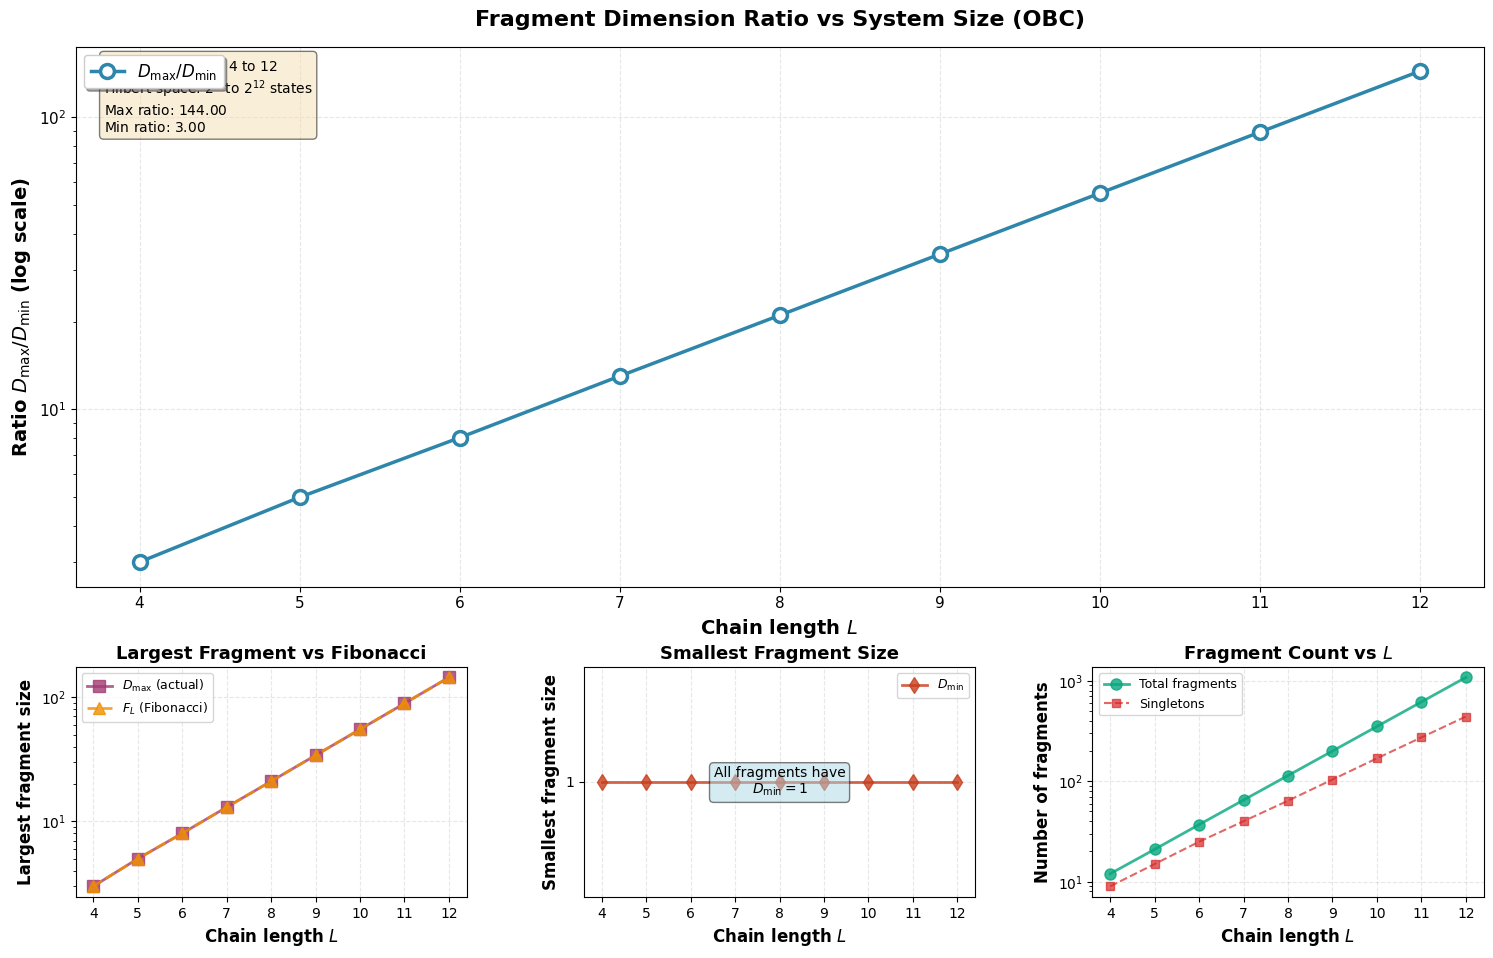


✓ Step 4 complete: Enhanced plot created successfully

ADDITIONAL STATISTICS
L =  4:   12 fragments,    9 singletons (75.0%), fragment density = 0.7500
L =  5:   21 fragments,   15 singletons (71.4%), fragment density = 0.6562
L =  6:   37 fragments,   25 singletons (67.6%), fragment density = 0.5781
L =  7:   65 fragments,   40 singletons (61.5%), fragment density = 0.5078
L =  8:  114 fragments,   64 singletons (56.1%), fragment density = 0.4453
L =  9:  200 fragments,  104 singletons (52.0%), fragment density = 0.3906
L = 10:  351 fragments,  169 singletons (48.1%), fragment density = 0.3428
L = 11:  616 fragments,  273 singletons (44.3%), fragment density = 0.3008
L = 12: 1081 fragments,  441 singletons (40.8%), fragment density = 0.2639


In [ ]:
# ============================================================
# STEP 4: Enhanced plot including number of fragments vs L
# ============================================================

def plot_fragment_analysis_vs_L(scan_results, save_path=None):
    """
    Create comprehensive publication-quality plot with 4 panels:
    1. Ratio D_max/D_min vs L (main plot)
    2. Largest fragment size vs Fibonacci
    3. Smallest fragment size
    4. Number of fragments vs L (NEW)

    Parameters:
    -----------
    scan_results : list of dict
        Results from scan_fragmentation_vs_L
    save_path : str, optional
        Path to save the figure
    """
    # Extract data
    L_values = [res['L'] for res in scan_results]
    ratios = [res['ratio'] for res in scan_results]
    largest_sizes = [res['largest_size'] for res in scan_results]
    smallest_sizes = [res['smallest_size'] for res in scan_results]
    num_fragments = [res['num_fragments'] for res in scan_results]
    num_singletons = [res['num_singletons'] for res in scan_results]

    # Compute Fibonacci numbers for reference
    fib_values = [fib(L) for L in L_values]

    # Create figure with subplots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3,
                          left=0.08, right=0.96, top=0.93, bottom=0.08)

    # ============================================================
    # Main plot: Ratio vs L (spans top 2 rows)
    # ============================================================
    ax1 = fig.add_subplot(gs[0:2, :])
    ax1.plot(L_values, ratios, 'o-', color='#2E86AB', linewidth=2.5,
             markersize=10, markerfacecolor='white', markeredgewidth=2.5,
             markeredgecolor='#2E86AB', label='$D_{\\mathrm{max}}/D_{\\mathrm{min}}$')

    ax1.set_xlabel('Chain length $L$', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Ratio $D_{\\mathrm{max}}/D_{\\mathrm{min}}$', fontsize=14, fontweight='bold')
    ax1.set_title('Fragment Dimension Ratio vs System Size (OBC)',
                  fontsize=16, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(fontsize=12, frameon=True, shadow=True, loc='upper left')
    ax1.tick_params(labelsize=11)

    # Use log scale for y-axis if ratios span multiple orders of magnitude
    if max(ratios) / min(ratios) > 10:
        ax1.set_yscale('log')
        ax1.set_ylabel('Ratio $D_{\\mathrm{max}}/D_{\\mathrm{min}}$ (log scale)',
                       fontsize=14, fontweight='bold')

    # Add text box with statistics
    stats_text = (f"System sizes: $L = {min(L_values)}$ to ${max(L_values)}$\n"
                  f"Hilbert space: $2^{{{min(L_values)}}}$ to $2^{{{max(L_values)}}}$ states\n"
                  f"Max ratio: ${max(ratios):.2f}$\n"
                  f"Min ratio: ${min(ratios):.2f}$")

    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # ============================================================
    # Subplot 1: Largest fragment size vs Fibonacci
    # ============================================================
    ax2 = fig.add_subplot(gs[2, 0])
    ax2.plot(L_values, largest_sizes, 's-', color='#A23B72', linewidth=2,
             markersize=8, label='$D_{\\mathrm{max}}$ (actual)', alpha=0.8)
    ax2.plot(L_values, fib_values, '^--', color='#F18F01', linewidth=2,
             markersize=8, label='$F_L$ (Fibonacci)', alpha=0.8)

    ax2.set_xlabel('Chain length $L$', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Largest fragment size', fontsize=12, fontweight='bold')
    ax2.set_title('Largest Fragment vs Fibonacci', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(fontsize=9, frameon=True, loc='upper left')
    ax2.tick_params(labelsize=10)
    ax2.set_yscale('log')

    # ============================================================
    # Subplot 2: Smallest fragment size
    # ============================================================
    ax3 = fig.add_subplot(gs[2, 1])
    ax3.plot(L_values, smallest_sizes, 'd-', color='#C73E1D', linewidth=2,
             markersize=8, label='$D_{\\mathrm{min}}$', alpha=0.8)

    ax3.set_xlabel('Chain length $L$', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Smallest fragment size', fontsize=12, fontweight='bold')
    ax3.set_title('Smallest Fragment Size', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.legend(fontsize=9, frameon=True)
    ax3.tick_params(labelsize=10)

    # Check if all smallest fragments are singletons
    if all(s == 1 for s in smallest_sizes):
        ax3.set_ylim([0.5, 1.5])
        ax3.set_yticks([1])
        ax3.text(0.5, 0.5, 'All fragments have\n$D_{\\mathrm{min}} = 1$',
                transform=ax3.transAxes, fontsize=10,
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    # ============================================================
    # Subplot 3: Number of fragments vs L (NEW)
    # ============================================================
    ax4 = fig.add_subplot(gs[2, 2])
    ax4.plot(L_values, num_fragments, 'o-', color='#06A77D', linewidth=2,
             markersize=8, label='Total fragments', alpha=0.8)
    ax4.plot(L_values, num_singletons, 's--', color='#D62828', linewidth=1.5,
             markersize=6, label='Singletons', alpha=0.7)

    ax4.set_xlabel('Chain length $L$', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Number of fragments', fontsize=12, fontweight='bold')
    ax4.set_title('Fragment Count vs $L$', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.legend(fontsize=9, frameon=True, loc='upper left')
    ax4.tick_params(labelsize=10)
    ax4.set_yscale('log')

    plt.tight_layout()

    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Figure saved to: {save_path}")

    plt.show()

    return fig


# Create the enhanced plot
print("\n" + "="*70)
print("Creating enhanced plot with 4 panels")
print("="*70)

fig = plot_fragment_analysis_vs_L(scan_results, save_path='fragment_analysis_vs_L.png')

print("\n✓ Step 4 complete: Enhanced plot created successfully")
print("="*70)

# Print additional statistics
print("\n" + "="*70)
print("ADDITIONAL STATISTICS")
print("="*70)
for res in scan_results:
    frag_density = res['num_fragments'] / res['Ns']
    singleton_fraction = res['num_singletons'] / res['num_fragments']
    print(f"L = {res['L']:2d}: {res['num_fragments']:4d} fragments, "
          f"{res['num_singletons']:4d} singletons ({singleton_fraction:.1%}), "
          f"fragment density = {frag_density:.4f}")
print("="*70)

# Exploring the edge effect by further computing magnetization

We will explore:


1.   Magnetization of a random state
2.   Magnetization of a state in the largest fragment



## Magnetization $\sigma_z$ for random states
Contour plot of
$$ \langle \psi (nT)|\sigma^z_i|\psi (nT) \rangle$$
 $site~i$ vs $n$ the number of Floquet periods.





### Results code for random states

In [ ]:
# ============================================
# PART 1: COMPUTATION FUNCTIONS
# ============================================

def build_sigma_z_all_sites(ising_chain):
    """
    Build σ^z operators for all sites.

    Parameters:
    -----------
    ising_chain : FloquetIsingChain
        The Floquet Ising chain object

    Returns:
    --------
    sigma_z_list : list of ndarray
        List of σ^z matrices for sites 0, 1, ..., L-1
    """
    L = ising_chain.L
    basis = ising_chain.basis
    sigma_z_list = []

    for site_j in range(L):
        static_list = [["z", [[1.0, site_j]]]]
        sigma_z_op = hamiltonian(static_list, [], basis=basis, dtype=np.float64)
        sigma_z_list.append(sigma_z_op.toarray())

    print(f"Built σ^z operators for all {L} sites")
    return sigma_z_list


def compute_magnetization_single_state(psi0, U_floquet, sigma_z_list, n_steps):
    """
    Compute local magnetization M_j(nT) = ⟨ψ(nT)|σ^z_j|ψ(nT)⟩ for a single initial state.

    Parameters:
    -----------
    psi0 : ndarray
        Initial state vector
    U_floquet : ndarray
        Floquet unitary operator
    sigma_z_list : list of ndarray
        List of σ^z operators for each site
    n_steps : int
        Number of Floquet steps

    Returns:
    --------
    M_matrix : ndarray
        Magnetization matrix of shape (L, n_steps+1)
        M_matrix[j, n] = M_j(nT)
    """
    L = len(sigma_z_list)
    M_matrix = np.zeros((L, n_steps + 1), dtype=float)

    # Initial state
    psi_t = psi0.copy()

    for n in range(n_steps + 1):
        # Compute magnetization at each site for current time step
        for j in range(L):
            # M_j(nT) = ⟨ψ(nT)|σ^z_j|ψ(nT)⟩
            M_matrix[j, n] = np.real(np.vdot(psi_t, sigma_z_list[j] @ psi_t))

        # Evolve state for next step (except at the last step)
        if n < n_steps:
            psi_t = U_floquet @ psi_t

    return M_matrix


def compute_magnetization_ensemble(random_states, U_floquet, sigma_z_list, n_steps):
    """
    Compute ensemble-averaged local magnetization over random initial states.

    Parameters:
    -----------
    random_states : list of ndarray
        List of random initial state vectors
    U_floquet : ndarray
        Floquet unitary operator
    sigma_z_list : list of ndarray
        List of σ^z operators for each site
    n_steps : int
        Number of Floquet steps

    Returns:
    --------
    M_avg : ndarray
        Ensemble-averaged magnetization matrix of shape (L, n_steps+1)
    M_all : ndarray
        Individual magnetization matrices of shape (num_states, L, n_steps+1)
    """
    num_states = len(random_states)
    L = len(sigma_z_list)

    M_all = np.zeros((num_states, L, n_steps + 1), dtype=float)

    print(f"\nComputing magnetization for {num_states} states over {n_steps} Floquet steps...")

    for i, psi0 in enumerate(random_states):
        M_all[i] = compute_magnetization_single_state(psi0, U_floquet, sigma_z_list, n_steps)

        if (i + 1) % 5 == 0 or (i + 1) == num_states:
            print(f"  Completed {i+1}/{num_states} states")

    # Ensemble average
    M_avg = np.mean(M_all, axis=0)

    print(f"\nEnsemble averaging complete:")
    print(f"  M_avg shape: {M_avg.shape} (L × n_steps+1)")
    print(f"  M_avg range: [{np.min(M_avg):.4f}, {np.max(M_avg):.4f}]")

    return M_avg, M_all


def run_magnetization_computation(
    L=8,
    J_0=10.0,
    h_0=20.0,
    g=1.0,
    period_factor=1,
    n_steps=40,
    num_states=20,
    seed=42
):
    """
    Main computation function for magnetization contour data.

    Parameters:
    -----------
    L : int
        Chain length
    J_0 : float
        Ising coupling strength
    h_0 : float
        Longitudinal field strength
    g : float
        Transverse field strength
    period_factor : int
        n in T = n*π/J_0 (1 or 2)
    n_steps : int
        Number of Floquet steps
    num_states : int
        Number of random states for ensemble average
    seed : int
        Random seed for reproducibility

    Returns:
    --------
    results : dict
        Dictionary containing:
        - 'M_avg': Ensemble-averaged magnetization (L, n_steps+1)
        - 'M_all': All individual magnetizations (num_states, L, n_steps+1)
        - 'sites': Array of site indices [0, 1, ..., L-1]
        - 'floquet_steps': Array of Floquet step numbers [0, 1, ..., n_steps]
    params : dict
        Dictionary of all parameters used
    """
    # Compute period
    TP = period_factor * np.pi / J_0

    print("=" * 70)
    print(f"MAGNETIZATION COMPUTATION: T = {period_factor}π/J₀")
    print("=" * 70)
    print(f"Parameters: L={L}, J_0={J_0}, h_0={h_0}, g={g}")
    print(f"Period: T = {period_factor}π/{J_0} = {TP:.6f}")
    print(f"Floquet steps: {n_steps}, Ensemble size: {num_states}")
    print("=" * 70)

    # Initialize system
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()

    # Build Floquet operator
    U_floquet = build_floquet_operator(ising)

    # Build σ^z operators for all sites
    sigma_z_list = build_sigma_z_all_sites(ising)

    # Generate random states
    random_states = generate_random_states(ising.basis.Ns, num_states=num_states, seed=seed)

    # Compute ensemble-averaged magnetization
    M_avg, M_all = compute_magnetization_ensemble(random_states, U_floquet, sigma_z_list, n_steps)

    # Package results
    results = {
        'M_avg': M_avg,
        'M_all': M_all,
        'sites': np.arange(L),
        'floquet_steps': np.arange(n_steps + 1)
    }

    params = {
        'L': L,
        'J_0': J_0,
        'h_0': h_0,
        'g': g,
        'period_factor': period_factor,
        'TP': TP,
        'n_steps': n_steps,
        'num_states': num_states,
        'seed': seed
    }

    print("\n✓ Computation complete!")
    return results, params
# ============================================
# PART 3: MAIN EXECUTION
# ============================================

if __name__ == "__main__":

    # ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed

    L = 8                # Chain length
    J_0 = 10.0           # Ising coupling strength
    h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
    g = 1.0              # Transverse field strength
    n_steps = 200         # Number of Floquet steps
    num_states = 20      # Number of random states for ensemble average
    seed = 45            # Random seed for reproducibility

    # =========================================

    # --- COMPUTATION ---
    print("\n" + "=" * 80)
    print("MAGNETIZATION CONTOUR PLOT COMPUTATION")
    print("=" * 80)

    # Compute for T = π/J_0 (n=1)
    print("\n>>> Computing for T = π/J₀ (period_factor = 1)")
    results_n1, params_n1 = run_magnetization_computation(
        L=L, J_0=J_0, h_0=h_0, g=g,
        period_factor=1,
        n_steps=n_steps,
        num_states=num_states,
        seed=seed
    )

    # Compute for T = 2π/J_0 (n=2)
    print("\n>>> Computing for T = 2π/J₀ (period_factor = 2)")
    results_n2, params_n2 = run_magnetization_computation(
        L=L, J_0=J_0, h_0=h_0, g=g,
        period_factor=2,
        n_steps=n_steps,
        num_states=num_states,
        seed=seed
    )

### Plotting code for random ensemble


GENERATING PLOTS

>>> Plotting T = π/J₀


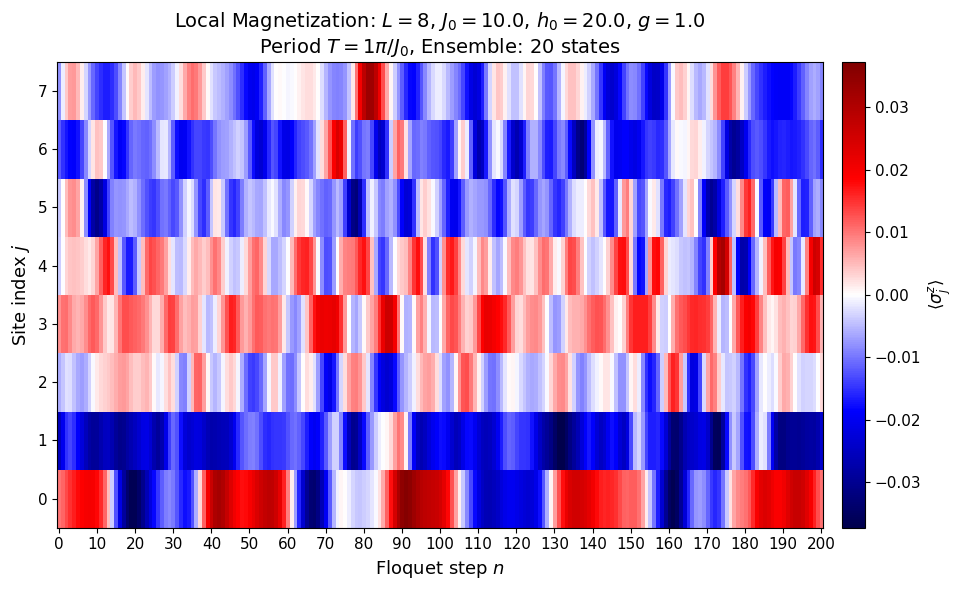


>>> Plotting T = 2π/J₀


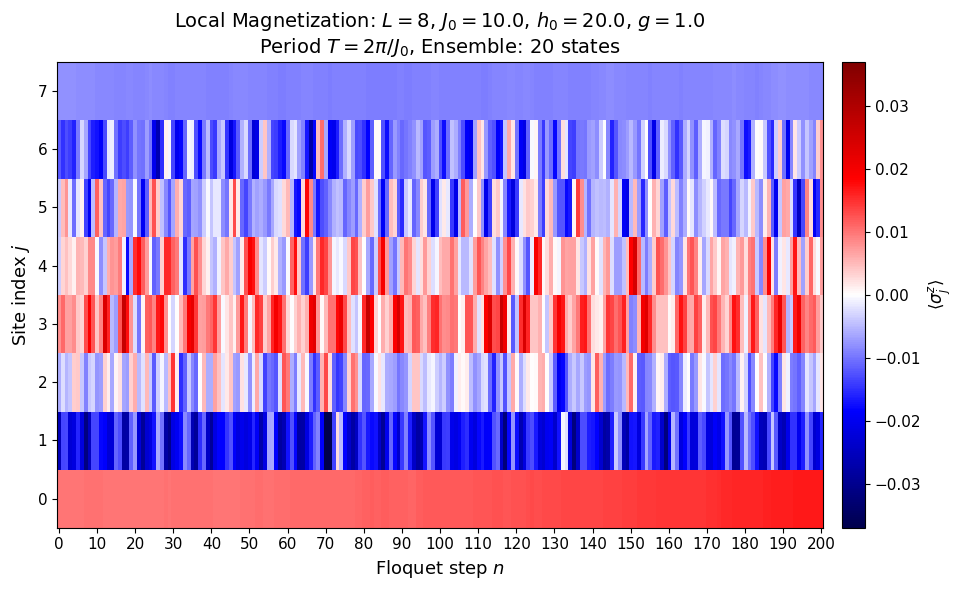


>>> Creating comparison plot


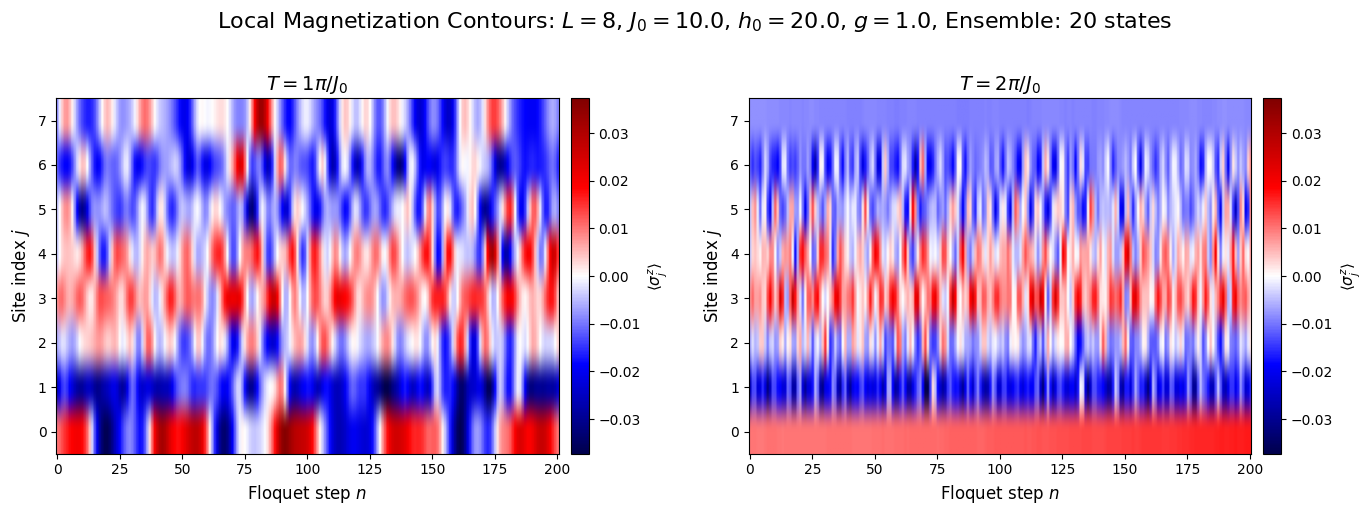


ALL COMPUTATIONS AND PLOTS COMPLETE!


In [ ]:
# ============================================
# PART 2: PLOTTING FUNCTIONS
# ============================================
import matplotlib.pyplot as plt

def plot_magnetization_contour(results, params, save_path=None, show_plot=True):
    """
    Create a contour plot of magnetization using imshow.

    Parameters:
    -----------
    results : dict
        Results dictionary from run_magnetization_computation
    params : dict
        Parameters dictionary from run_magnetization_computation
    save_path : str, optional
        Path to save the figure (without extension, saves both .pdf and .png)
    show_plot : bool
        Whether to display the plot

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    M_avg = results['M_avg']
    sites = results['sites']
    floquet_steps = results['floquet_steps']

    L = params['L']
    J_0 = params['J_0']
    h_0 = params['h_0']
    g = params['g']
    period_factor = params['period_factor']
    n_steps = params['n_steps']
    num_states = params['num_states']

    # ========== EASILY MODIFIABLE PLOT PARAMETERS ==========
    fig_width = 10
    fig_height = 6
    cmap = 'seismic'

    # Colorbar limits (symmetric around 0 for diverging colormap)
    vmax = np.max(np.abs(M_avg))
    vmin = -vmax

    # Font sizes
    title_fontsize = 14
    label_fontsize = 13
    tick_fontsize = 11
    cbar_label_fontsize = 12
    # =======================================================

    # Create figure
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Create the imshow plot
    # Note: imshow expects (rows, cols) = (sites, floquet_steps)
    # origin='lower' puts site 0 at bottom
    im = ax.imshow(
        M_avg,
        aspect='auto',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        origin='lower',
        extent=[floquet_steps[0] - 0.5, floquet_steps[-1] + 0.5,
                sites[0] - 0.5, sites[-1] + 0.5]
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r'$\langle \sigma^z_j \rangle$', fontsize=cbar_label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    # Labels and title
    ax.set_xlabel(r'Floquet step $n$', fontsize=label_fontsize)
    ax.set_ylabel(r'Site index $j$', fontsize=label_fontsize)

    title = (f'Local Magnetization: $L={L}$, $J_0={J_0}$, $h_0={h_0}$, $g={g}$\n'
             f'Period $T = {period_factor}\\pi/J_0$, Ensemble: {num_states} states')
    ax.set_title(title, fontsize=title_fontsize)

    # Set y-ticks to show all sites
    ax.set_yticks(sites)
    ax.set_yticklabels([f'{j}' for j in sites])

    # Set x-ticks (every 5 or 10 steps depending on range)
    if n_steps <= 50:
        xtick_spacing = 5
    else:
        xtick_spacing = 10
    ax.set_xticks(np.arange(0, n_steps + 1, xtick_spacing))

    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    plt.tight_layout()
    plt.show()

    return fig, ax


def plot_magnetization_comparison(results_list, params_list, save_path=None, show_plot=True):
    """
    Create side-by-side comparison of magnetization contours for different periods.

    Parameters:
    -----------
    results_list : list of dict
        List of results dictionaries (one per period)
    params_list : list of dict
        List of parameter dictionaries (one per period)
    save_path : str, optional
        Path to save the figure
    show_plot : bool
        Whether to display the plot

    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    n_plots = len(results_list)

    # ========== EASILY MODIFIABLE PLOT PARAMETERS ==========
    fig_width = 7 * n_plots
    fig_height = 5
    cmap = 'seismic'
    title_fontsize = 14
    label_fontsize = 12
    tick_fontsize = 10
    suptitle_fontsize = 16
    # =======================================================

    fig, axes = plt.subplots(1, n_plots, figsize=(fig_width, fig_height))
    if n_plots == 1:
        axes = [axes]

    # Find global color limits for consistency
    all_M = np.concatenate([r['M_avg'].flatten() for r in results_list])
    vmax = np.max(np.abs(all_M))
    vmin = -vmax

    for idx, (results, params, ax) in enumerate(zip(results_list, params_list, axes)):
        M_avg = results['M_avg']
        sites = results['sites']
        floquet_steps = results['floquet_steps']

        period_factor = params['period_factor']
        n_steps = params['n_steps']

        im = ax.imshow(
            M_avg,
            aspect='auto',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin='lower',
            extent=[floquet_steps[0] - 0.5, floquet_steps[-1] + 0.5,
                    sites[0] - 0.5, sites[-1] + 0.5]
        )

        ax.set_xlabel(r'Floquet step $n$', fontsize=label_fontsize)
        ax.set_ylabel(r'Site index $j$', fontsize=label_fontsize)
        ax.set_title(f'$T = {period_factor}\\pi/J_0$', fontsize=title_fontsize)

        ax.set_yticks(sites)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

        # Add colorbar to each subplot
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(r'$\langle \sigma^z_j \rangle$', fontsize=label_fontsize - 1)
        cbar.ax.tick_params(labelsize=tick_fontsize)

    # Common parameters for suptitle
    p = params_list[0]
    fig.suptitle(
        f'Local Magnetization Contours: $L={p["L"]}$, $J_0={p["J_0"]}$, '
        f'$h_0={p["h_0"]}$, $g={p["g"]}$, Ensemble: {p["num_states"]} states',
        fontsize=suptitle_fontsize, y=1.02
    )

    plt.tight_layout()
    plt.show()

    return fig, axes



# --- PLOTTING ---
print("\n" + "=" * 80)
print("GENERATING PLOTS")
print("=" * 80)

    # Individual plots
print("\n>>> Plotting T = π/J₀")
fig1, ax1 = plot_magnetization_contour(
        results_n1, params_n1,
        save_path='magnetization_contour_T1pi',
        show_plot=True)

print("\n>>> Plotting T = 2π/J₀")
fig2, ax2 = plot_magnetization_contour(
        results_n2, params_n2,
        save_path='magnetization_contour_T2pi',
        show_plot=True)

    # Side-by-side comparison plot
print("\n>>> Creating comparison plot")
fig_comp, axes_comp = plot_magnetization_comparison(
        [results_n1, results_n2],
        [params_n1, params_n2],
        save_path='magnetization_contour_comparison',
        show_plot=True
    )

print("\n" + "=" * 80)
print("ALL COMPUTATIONS AND PLOTS COMPLETE!")
print("=" * 80)

## Magnetization of a state in the largest fragment




### Results code for a single state evolution of any state




In [ ]:
# ============================================
# PART 1: COMPUTATION FUNCTIONS
# ============================================

def create_product_state_from_string(state_string, ising_chain):
    """
    Create a product state from a binary string.

    Parameters:
    -----------
    state_string : str
        Binary string of length L where:
        '0' = spin down (σ^z eigenvalue -1, ↓)
        '1' = spin up   (σ^z eigenvalue +1, ↑)

        Examples for L=8:
        "00000000" = all spins down    |↓↓↓↓↓↓↓↓⟩
        "11111111" = all spins up      |↑↑↑↑↑↑↑↑⟩
        "01010101" = Néel state        |↓↑↓↑↓↑↓↑⟩
        "10101010" = Anti-Néel state   |↑↓↑↓↑↓↑↓⟩
        "00001111" = Domain wall       |↓↓↓↓↑↑↑↑⟩

    ising_chain : FloquetIsingChain
        The Floquet Ising chain object

    Returns:
    --------
    psi : ndarray
        Normalized state vector in the computational basis
    """
    L = ising_chain.L
    basis = ising_chain.basis

    # Validate input
    if len(state_string) != L:
        raise ValueError(f"State string length ({len(state_string)}) must match chain length L={L}")

    if not all(c in '01' for c in state_string):
        raise ValueError("State string must contain only '0' (up) and '1' (down)")

    # Convert binary string to integer representation
    # QuSpin convention: the integer encodes the spin configuration
    state_int = int(state_string, 2)

    # Find the index in the basis using QuSpin's index method
    try:
        idx = basis.index(state_int)
    except ValueError:
        raise ValueError(f"State {state_string} (int={state_int}) not found in basis. "
                        f"This might be due to symmetry constraints.")

    # Create state vector
    psi = np.zeros(basis.Ns, dtype=complex)
    psi[idx] = 1.0

    # Print state information
    spin_visual = state_string.replace('0', '↓').replace('1', '↑')
    print(f"\nInitial state created:")
    print(f"  Binary string: {state_string}")
    print(f"  Spin config:   |{spin_visual}⟩")
    print(f"  Basis index:   {idx}")
    print(f"  Norm check:    {np.linalg.norm(psi):.6f}")

    return psi


def build_sigma_z_all_sites(ising_chain):
    """
    Build σ^z operators for all sites.

    Parameters:
    -----------
    ising_chain : FloquetIsingChain
        The Floquet Ising chain object

    Returns:
    --------
    sigma_z_list : list of ndarray
        List of σ^z matrices for sites 0, 1, ..., L-1
    """
    L = ising_chain.L
    basis = ising_chain.basis
    sigma_z_list = []

    for site_j in range(L):
        static_list = [["z", [[1.0, site_j]]]]
        sigma_z_op = hamiltonian(static_list, [], basis=basis, dtype=np.float64)
        sigma_z_list.append(sigma_z_op.toarray())

    print(f"Built σ^z operators for all {L} sites")
    return sigma_z_list


def compute_magnetization_single_state(psi0, U_floquet, sigma_z_list, n_steps):
    """
    Compute local magnetization M_j(nT) = ⟨ψ(nT)|σ^z_j|ψ(nT)⟩ for a single initial state.

    Parameters:
    -----------
    psi0 : ndarray
        Initial state vector
    U_floquet : ndarray
        Floquet unitary operator
    sigma_z_list : list of ndarray
        List of σ^z operators for each site
    n_steps : int
        Number of Floquet steps

    Returns:
    --------
    M_matrix : ndarray
        Magnetization matrix of shape (L, n_steps+1)
        M_matrix[j, n] = M_j(nT)
    """
    L = len(sigma_z_list)
    M_matrix = np.zeros((L, n_steps + 1), dtype=float)

    # Initial state
    psi_t = psi0.copy()

    for n in range(n_steps + 1):
        # Compute magnetization at each site for current time step
        for j in range(L):
            # M_j(nT) = ⟨ψ(nT)|σ^z_j|ψ(nT)⟩
            M_matrix[j, n] = np.real(np.vdot(psi_t, sigma_z_list[j] @ psi_t))

        # Evolve state for next step (except at the last step)
        if n < n_steps:
            psi_t = U_floquet @ psi_t

    return M_matrix


def run_magnetization_computation(
    L=8,
    J_0=10.0,
    h_0=20.0,
    g=1.0,
    period_factor=1,
    n_steps=40,
    initial_state_string=None,
    seed=42
):
    """
    Main computation function for magnetization contour data.

    Parameters:
    -----------
    L : int
        Chain length
    J_0 : float
        Ising coupling strength
    h_0 : float
        Longitudinal field strength
    g : float
        Transverse field strength
    period_factor : int
        n in T = n*π/J_0 (1 or 2)
    n_steps : int
        Number of Floquet steps
    initial_state_string : str
        Binary string of length L specifying the initial product state.
        '0' = spin up, '1' = spin down.
        Example: "01010101" for Néel state |↑↓↑↓↑↓↑↓⟩
    seed : int
        Random seed (unused when initial_state_string is provided)

    Returns:
    --------
    results : dict
        Dictionary containing:
        - 'M_avg': Magnetization matrix (L, n_steps+1)
        - 'sites': Array of site indices [0, 1, ..., L-1]
        - 'floquet_steps': Array of Floquet step numbers [0, 1, ..., n_steps]
    params : dict
        Dictionary of all parameters used
    """
    # Compute period
    TP = period_factor * np.pi / J_0

    print("=" * 70)
    print(f"MAGNETIZATION COMPUTATION: T = {period_factor}π/J₀")
    print("=" * 70)
    print(f"Parameters: L={L}, J_0={J_0}, h_0={h_0}, g={g}")
    print(f"Period: T = {period_factor}π/{J_0} = {TP:.6f}")
    print(f"Floquet steps: {n_steps}")
    print(f"Initial state: {initial_state_string}")
    print("=" * 70)

    # Initialize system
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()

    # Build Floquet operator
    U_floquet = build_floquet_operator(ising)

    # Build σ^z operators for all sites
    sigma_z_list = build_sigma_z_all_sites(ising)

    # Create initial state from user-defined string
    psi0 = create_product_state_from_string(initial_state_string, ising)

    # Compute magnetization for the single initial state
    print(f"\nComputing magnetization over {n_steps} Floquet steps...")
    M_matrix = compute_magnetization_single_state(psi0, U_floquet, sigma_z_list, n_steps)

    print(f"\nComputation complete:")
    print(f"  M shape: {M_matrix.shape} (L × n_steps+1)")
    print(f"  M range: [{np.min(M_matrix):.4f}, {np.max(M_matrix):.4f}]")

    # Package results
    results = {
        'M_avg': M_matrix,  # Named M_avg for compatibility with plotting functions
        'sites': np.arange(L),
        'floquet_steps': np.arange(n_steps + 1)
    }

    params = {
        'L': L,
        'J_0': J_0,
        'h_0': h_0,
        'g': g,
        'period_factor': period_factor,
        'TP': TP,
        'n_steps': n_steps,
        'initial_state_string': initial_state_string,
        'seed': seed
    }

    print("\n✓ Computation complete!")
    return results, params




# ============================================
# PART 3: MAIN EXECUTION
# ============================================

if __name__ == "__main__":

    # ========== TUNABLE PARAMETERS ==========
    # Modify these values as needed

    L = 8                # Chain length
    J_0 = 20.0           # Ising coupling strength
    h_0 = 40.0           # Longitudinal field strength (h_0 = 2*J_0)
    g = 1.0              # Transverse field strength
    n_steps = 500         # Number of Floquet steps

    # USER-DEFINED INITIAL STATE
    # Binary string of length L where:
    #   '0' = spin down (↓)
    #   '1' = spin up   (↑)
    #
    # Examples for L=8:
    #   "00000000" = all down      |↓↓↓↓↓↓↓↓⟩
    #   "11111111" = all up        |↑↑↑↑↑↑↑↑⟩
    #   "01010101" = Néel state    |↓↑↓↑↓↑↓↑⟩
    #   "10101010" = Anti-Néel     |↑↓↑↓↑↓↑↓⟩
    #   "00001111" = Domain wall   |↓↓↓↓↑↑↑↑⟩
    #   "00110011" = Paired        |↓↓↑↑↓↓↑↑⟩

    initial_state = "01010100"  # <-- MODIFY THIS STRING

    # =========================================

    # --- COMPUTATION ---
    print("\n" + "=" * 80)
    print("MAGNETIZATION CONTOUR PLOT COMPUTATION (CUSTOM INITIAL STATE)")
    print("=" * 80)

    # Compute for T = π/J_0 (n=1)
    print("\n>>> Computing for T = π/J₀ (period_factor = 1)")
    results_n1, params_n1 = run_magnetization_computation(
        L=L, J_0=J_0, h_0=h_0, g=g,
        period_factor=1,
        n_steps=n_steps,
        initial_state_string=initial_state
    )

    # Compute for T = 2π/J_0 (n=2)
    print("\n>>> Computing for T = 2π/J₀ (period_factor = 2)")
    results_n2, params_n2 = run_magnetization_computation(
        L=L, J_0=J_0, h_0=h_0, g=g,
        period_factor=2,
        n_steps=n_steps,
        initial_state_string=initial_state
    )


MAGNETIZATION CONTOUR PLOT COMPUTATION (CUSTOM INITIAL STATE)

>>> Computing for T = π/J₀ (period_factor = 1)
MAGNETIZATION COMPUTATION: T = 1π/J₀
Parameters: L=8, J_0=20.0, h_0=40.0, g=1.0
Period: T = 1π/20.0 = 0.157080
Floquet steps: 500
Initial state: 01010100
System Parameters:
  Chain length L = 8
  J_0 = 20.0
  h_0 = 40.0
  g = 1.0
  Period T = 0.157080
  Hilbert space dimension = 256
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

Hamiltonians constructed successfully!
  H+ shape: (256, 256)
  H- shape: (256, 256)
Floquet operator constructed:
  Shape: (256, 256)
  Unitarity check: ||U†U - I|| = 2.31e-13
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
S

### Plotting code for a single evolution of any state


GENERATING PLOTS

>>> Creating comparison plot

✓ Comparison figure saved:
  - magnetization_contour_comparison_state01010100.pdf
  - magnetization_contour_comparison_state01010100.png


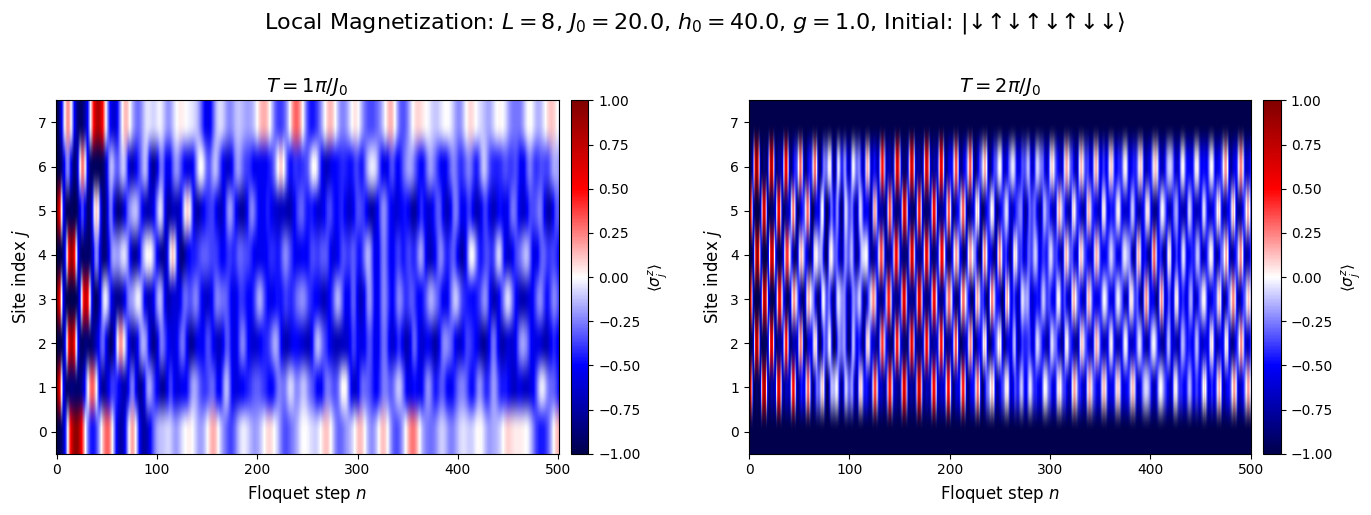


ALL COMPUTATIONS AND PLOTS COMPLETE!


In [ ]:
# ============================================
# PART 2: PLOTTING FUNCTIONS
# ============================================


def plot_magnetization_comparison(results_list, params_list, save_path=None, show_plot=True):
    """
    Create side-by-side comparison of magnetization contours for different periods.

    Parameters:
    -----------
    results_list : list of dict
        List of results dictionaries (one per period)
    params_list : list of dict
        List of parameter dictionaries (one per period)
    save_path : str, optional
        Path to save the figure
    show_plot : bool
        Whether to display the plot

    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    n_plots = len(results_list)

    # ========== EASILY MODIFIABLE PLOT PARAMETERS ==========
    fig_width = 7 * n_plots
    fig_height = 5
    cmap = 'seismic'
    title_fontsize = 14
    label_fontsize = 12
    tick_fontsize = 10
    suptitle_fontsize = 16
    # =======================================================

    fig, axes = plt.subplots(1, n_plots, figsize=(fig_width, fig_height))
    if n_plots == 1:
        axes = [axes]

    # Find global color limits for consistency
    all_M = np.concatenate([r['M_avg'].flatten() for r in results_list])
    vmax = max(np.max(np.abs(all_M)), 0.1)
    vmin = -vmax

    for idx, (results, params, ax) in enumerate(zip(results_list, params_list, axes)):
        M_avg = results['M_avg']
        sites = results['sites']
        floquet_steps = results['floquet_steps']

        period_factor = params['period_factor']
        n_steps = params['n_steps']

        im = ax.imshow(
            M_avg,
            aspect='auto',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin='lower',
            extent=[floquet_steps[0] - 0.5, floquet_steps[-1] + 0.5,
                    sites[0] - 0.5, sites[-1] + 0.5]
        )

        ax.set_xlabel(r'Floquet step $n$', fontsize=label_fontsize)
        ax.set_ylabel(r'Site index $j$', fontsize=label_fontsize)
        ax.set_title(f'$T = {period_factor}\\pi/J_0$', fontsize=title_fontsize)

        ax.set_yticks(sites)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(r'$\langle \sigma^z_j \rangle$', fontsize=label_fontsize - 1)
        cbar.ax.tick_params(labelsize=tick_fontsize)

    # Common parameters for suptitle
    p = params_list[0]
    initial_state = p.get('initial_state_string', 'N/A')
    spin_visual = initial_state.replace('0', '↓').replace('1', '↑')

    fig.suptitle(
        f'Local Magnetization: $L={p["L"]}$, $J_0={p["J_0"]}$, '
        f'$h_0={p["h_0"]}$, $g={p["g"]}$, Initial: $|{spin_visual}\\rangle$',
        fontsize=suptitle_fontsize, y=1.02
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(f'{save_path}.pdf', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Comparison figure saved:")
        print(f"  - {save_path}.pdf")
        print(f"  - {save_path}.png")

    if show_plot:
        plt.show()

    return fig, axes

# --- PLOTTING ---
print("\n" + "=" * 80)
print("GENERATING PLOTS")
print("=" * 80)

# Create filename suffix from initial state
state_label = initial_state

# Side-by-side comparison plot
print("\n>>> Creating comparison plot")
fig_comp, axes_comp = plot_magnetization_comparison(
[results_n1, results_n2],
[params_n1, params_n2],
save_path=f'magnetization_contour_comparison_state{state_label}',
show_plot=True
)

print("\n" + "=" * 80)
print("ALL COMPUTATIONS AND PLOTS COMPLETE!")
print("=" * 80)

In [ ]:
# ============================================
# MAGNETIZATION LINE PLOT: Separate figure per site
# ============================================

def plot_magnetization_per_site(results, params, save_path_prefix=None, show_plot=True):
    """
    Create separate figures for magnetization at each site versus Floquet steps.

    Parameters:
    -----------
    results : dict
        Results dictionary containing M_avg, sites, floquet_steps
    params : dict
        Parameter dictionary
    save_path_prefix : str, optional
        Prefix for saving figures (will append _site{j})
    show_plot : bool
        Whether to display the plots

    Returns:
    --------
    figs : list of matplotlib figure objects
    axes : list of matplotlib axes objects
    """
    # ========== EASILY MODIFIABLE PLOT PARAMETERS ==========
    fig_width = 8
    fig_height = 5
    title_fontsize = 14
    label_fontsize = 12
    tick_fontsize = 10
    line_width = 1.5
    line_color = 'tab:blue'
    # =======================================================

    M_avg = results['M_avg']  # Shape: (n_sites, n_floquet_steps)
    sites = results['sites']
    floquet_steps = results['floquet_steps']

    L = len(sites)
    period_factor = params['period_factor']
    initial_state = params.get('initial_state_string', 'N/A')
    spin_visual = initial_state.replace('0', '↓').replace('1', '↑')

    figs = []
    axes = []

    for j in sites:
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        # Plot magnetization for site j
        ax.plot(floquet_steps, M_avg[j, :],
               linewidth=line_width, color=line_color)

        ax.set_xlabel(r'Floquet step $n$', fontsize=label_fontsize)
        ax.set_ylabel(rf'$\langle \sigma^z_{j} \rangle$', fontsize=label_fontsize)

        # Title with all parameters
        ax.set_title(
            f'Site $j={j}$, $T = {period_factor}\\pi/J_0$\n'
            f'$L={params["L"]}$, $J_0={params["J_0"]}$, '
            f'$h_0={params["h_0"]}$, $g={params["g"]}$, '
            f'Initial: $|{spin_visual}\\rangle$',
            fontsize=title_fontsize
        )

        ax.set_ylim(-1.1, 1.1)
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path_prefix:
            filename = f'{save_path_prefix}_site{j}'
            fig.savefig(f'{filename}.pdf', dpi=300, bbox_inches='tight')
            fig.savefig(f'{filename}.png', dpi=300, bbox_inches='tight')
            print(f"  ✓ Saved: {filename}.pdf/.png")

        if show_plot:
            plt.show()

        figs.append(fig)
        axes.append(ax)

    return figs, axes


# --- PLOTTING ---
print("\n" + "=" * 80)
print("GENERATING INDIVIDUAL SITE PLOTS")
print("=" * 80)

state_label = initial_state

# Plots for T = π/J_0 (period_factor = 1)
print("\n>>> Plots for T = π/J₀:")
figs_n1, axes_n1 = plot_magnetization_per_site(
    results_n1, params_n1,
    save_path_prefix=f'magnetization_T1_state{state_label}',
    show_plot=True
)

# Plots for T = 2π/J_0 (period_factor = 2)
print("\n>>> Plots for T = 2π/J₀:")
figs_n2, axes_n2 = plot_magnetization_per_site(
    results_n2, params_n2,
    save_path_prefix=f'magnetization_T2_state{state_label}',
    show_plot=True
)

print("\n" + "=" * 80)
print("ALL PLOTS COMPLETE!")
print(f"Total figures generated: {len(figs_n1) + len(figs_n2)} (8 per period × 2 periods)")
print("=" * 80)